In [179]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
import xml.etree.ElementTree as ET
import numpy as np
import scipy as sp
from scipy.io import whosmat, loadmat
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D, Dense, Dropout
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score
from scipy.stats import wilcoxon
import fmatoolbox as fmb

In [5]:
import os
print(os.environ.get("LD_LIBRARY_PATH"))

/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cublas/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cuda_cupti/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cuda_nvrtc/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cuda_runtime/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cudnn/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cufft/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/curand/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cusolver/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/cusparse/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/nccl/lib:/home/laura/uvEnvs/.venv/lib/python3.12/site-packages/nvidia/nvjitlink/lib


In [6]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
from pathlib import Path

chemin = Path("/mnt/hubel-data-149/Rat012/Rat012_2025-12-15")


In [8]:
for f in sorted(chemin.iterdir()):
    print(f.name)

BeforeCheckSameClu
In
InfraSlowRhythm
IniClu
Rat012_2025-12-15.cat.evt
Rat012_2025-12-15.cat.evt.old
Rat012_2025-12-15.clu.1
Rat012_2025-12-15.clu.10
Rat012_2025-12-15.clu.11
Rat012_2025-12-15.clu.12
Rat012_2025-12-15.clu.12.03.05.2026.14.46
Rat012_2025-12-15.clu.2
Rat012_2025-12-15.clu.3
Rat012_2025-12-15.clu.4
Rat012_2025-12-15.clu.5
Rat012_2025-12-15.clu.6
Rat012_2025-12-15.clu.7
Rat012_2025-12-15.clu.8
Rat012_2025-12-15.clu.9
Rat012_2025-12-15.dat
Rat012_2025-12-15.deltaWaves.events.mat
Rat012_2025-12-15.drowsiness
Rat012_2025-12-15.fet.1
Rat012_2025-12-15.fet.10
Rat012_2025-12-15.fet.11
Rat012_2025-12-15.fet.12
Rat012_2025-12-15.fet.2
Rat012_2025-12-15.fet.3
Rat012_2025-12-15.fet.4
Rat012_2025-12-15.fet.5
Rat012_2025-12-15.fet.6
Rat012_2025-12-15.fet.7
Rat012_2025-12-15.fet.8
Rat012_2025-12-15.fet.9
Rat012_2025-12-15.fil
Rat012_2025-12-15.klg.1
Rat012_2025-12-15.klg.10
Rat012_2025-12-15.klg.11
Rat012_2025-12-15.klg.12
Rat012_2025-12-15.klg.2
Rat012_2025-12-15.klg.3
Rat012_2025-12-

In [9]:
HPC_groups =[7, 8, 9]
MPFC_groups =[10, 11, 12]  

hpc_files =[]
mpfc_files =[]

for g in HPC_groups:
    hpc_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

for g in MPFC_groups:
    mpfc_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

print("HPC:")
for x in hpc_files:
    print("HPC groupe", x["group"])
    print("clu:", x["clu"])  
    print("res:", x["res"]) 

print("mPFC:")
for x in mpfc_files:
    print("mPFC groupe", x["group"])
    print("clu:", x["clu"])  
    print("res:", x["res"]) 

HPC:
HPC groupe 7
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.7
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.7
HPC groupe 8
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.8
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.8
HPC groupe 9
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.9
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.9
mPFC:
mPFC groupe 10
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.10
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.10
mPFC groupe 11
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.11
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.11
mPFC groupe 12
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.12
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.12


In [10]:
xml_file = next(chemin.glob("*.xml"))
tree = ET.parse(xml_file)
root = tree.getroot()

sampling_rate = None

for elem in root.iter():
    if elem.tag.lower().endswith("samplingrate"):
        sampling_rate = float(elem.text)
        break

print("fichier xml:", xml_file.name)
print("freq d'ech :", sampling_rate, "Hz")

fichier xml: Rat012_2025-12-15.xml
freq d'ech : 20000.0 Hz


In [11]:
def load_clu_res(clu_path, res_path):

    clu_raw = np.loadtxt(clu_path, dtype=np.int64)
    res = np.loadtxt(res_path, dtype=np.int64)

    clu = clu_raw[1:]

    if len(clu) != len(res):
        raise ValueError(
            f"Longueurs différentes : clu={len(clu)}, res={len(res)}"
        ) 

    return clu, res

In [12]:
FE = 20_000

def load_units(files, fs):
    units ={}

    for x in files:
        group = x["group"]

        clu, res = load_clu_res(x["clu"], x["res"])
        spike_times = res / FE

        for cluster in np.unique(clu):
            units[(group, cluster)]= spike_times[clu == cluster]

    return units

hpc_units = load_units(hpc_files, FE)
mpfc_units = load_units(mpfc_files, FE)     

In [13]:
delta_files =[
    f for f in chemin.iterdir()
    if "delta" in f.name.lower()
] 

for f in delta_files:
    print(f.name)

Rat012_2025-12-15.deltaWaves.events.mat


In [14]:
delta_file= delta_files[0] 

print("Fichier :", delta_file)
print("Taille :", delta_file.stat().st_size / 1024, "KB")

Fichier : /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.deltaWaves.events.mat
Taille : 103.7431640625 KB


In [15]:
with open(delta_file, "rb") as f:
    header = f.read(100)

print(header)

b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Tue Mar 31 15:44:19 2026                        '


In [16]:
for x in whosmat(delta_file):
    print(x)

('deltaWaves', (1, 1), 'struct')


In [17]:
mat = loadmat(delta_file, simplify_cells=True)

print(mat.keys())

deltawaves = mat["deltaWaves"]

print(type(deltawaves)) 
print(deltawaves.keys())

dict_keys(['__header__', '__version__', '__globals__', 'deltaWaves'])
<class 'dict'>
dict_keys(['timestamps', 'peaks', 'peakNormedPower', 'detectorName', 'troughValue', 'badIntervals'])


In [18]:
for key in ["timestamps", "peaks"]:
    x = np.asarray(deltawaves[key])

    print("\n", key)
    print("shape:", x.shape)
    print("dtype:", x.dtype)
    print("premières valeurs:")
    print(x[:10]) 


 timestamps
shape: (3338, 2)
dtype: float64
premières valeurs:
[[507.7656 508.0152]
 [789.5    789.86  ]
 [802.044  802.316 ]
 [842.6312 842.9016]
 [846.8552 847.1416]
 [861.3624 861.7264]
 [872.0072 872.3392]
 [874.3592 874.6456]
 [876.1632 876.3248]
 [878.7104 879.0536]]

 peaks
shape: (3338,)
dtype: float64
premières valeurs:
[507.8808 789.7328 802.1736 842.7584 846.9912 861.5904 872.1384 874.5032
 876.164  878.8808]


In [19]:
delta_peaks = np.asarray(deltawaves["peaks"], dtype=float)
print("nombre de delta waves:", len(delta_peaks))
print(delta_peaks[:10])

nombre de delta waves: 3338
[507.8808 789.7328 802.1736 842.7584 846.9912 861.5904 872.1384 874.5032
 876.164  878.8808]


In [20]:
def build_hpc_matrix(hpc_units, delta_peaks, window=0.200):
    unit_ids = list(hpc_units.keys())
    X = np.zeros((len(delta_peaks), len(unit_ids)), dtype=int)

    for j, unit_id in enumerate(unit_ids):
        spikes = np.asarray(hpc_units[unit_id])

        left = np.searchsorted(spikes, delta_peaks - window, side = "left")
        right = np.searchsorted(spikes, delta_peaks, side = "right")

        X[:, j] = right - left

    return X, unit_ids 

In [21]:
X_hpc, hpc_unit_ids = build_hpc_matrix (hpc_units, delta_peaks)

print("Shape X_hpc:", X_hpc.shape)
print("Unités HPC:", hpc_unit_ids)

Shape X_hpc: (3338, 67)
Unités HPC: [(7, np.int64(0)), (7, np.int64(1)), (7, np.int64(3)), (7, np.int64(7)), (7, np.int64(9)), (7, np.int64(10)), (7, np.int64(13)), (7, np.int64(17)), (7, np.int64(20)), (7, np.int64(25)), (7, np.int64(31)), (7, np.int64(33)), (7, np.int64(35)), (7, np.int64(38)), (7, np.int64(41)), (7, np.int64(42)), (7, np.int64(44)), (7, np.int64(50)), (7, np.int64(51)), (7, np.int64(52)), (7, np.int64(55)), (7, np.int64(58)), (7, np.int64(67)), (7, np.int64(68)), (7, np.int64(71)), (7, np.int64(73)), (7, np.int64(76)), (7, np.int64(80)), (7, np.int64(84)), (7, np.int64(89)), (7, np.int64(96)), (7, np.int64(101)), (7, np.int64(103)), (7, np.int64(104)), (7, np.int64(105)), (7, np.int64(106)), (8, np.int64(0)), (8, np.int64(1)), (8, np.int64(5)), (8, np.int64(6)), (8, np.int64(13)), (8, np.int64(23)), (8, np.int64(26)), (8, np.int64(28)), (8, np.int64(29)), (8, np.int64(32)), (8, np.int64(33)), (8, np.int64(45)), (8, np.int64(46)), (9, np.int64(0)), (9, np.int64(1)), 

In [22]:
hpc_units = {
    k: value 
    for k, value in hpc_units.items()
    if k[1] > 1 
} 

mpfc_units = {
    k: value 
    for k, value in mpfc_units.items()
    if k[1] > 1 
} 

In [23]:
print("HPC:", len(hpc_units), "unités")
print("mPFC:", len(mpfc_units), "unités")

print(list(hpc_units.keys()))
print(list(mpfc_units.keys()))

HPC: 61 unités
mPFC: 22 unités
[(7, np.int64(3)), (7, np.int64(7)), (7, np.int64(9)), (7, np.int64(10)), (7, np.int64(13)), (7, np.int64(17)), (7, np.int64(20)), (7, np.int64(25)), (7, np.int64(31)), (7, np.int64(33)), (7, np.int64(35)), (7, np.int64(38)), (7, np.int64(41)), (7, np.int64(42)), (7, np.int64(44)), (7, np.int64(50)), (7, np.int64(51)), (7, np.int64(52)), (7, np.int64(55)), (7, np.int64(58)), (7, np.int64(67)), (7, np.int64(68)), (7, np.int64(71)), (7, np.int64(73)), (7, np.int64(76)), (7, np.int64(80)), (7, np.int64(84)), (7, np.int64(89)), (7, np.int64(96)), (7, np.int64(101)), (7, np.int64(103)), (7, np.int64(104)), (7, np.int64(105)), (7, np.int64(106)), (8, np.int64(5)), (8, np.int64(6)), (8, np.int64(13)), (8, np.int64(23)), (8, np.int64(26)), (8, np.int64(28)), (8, np.int64(29)), (8, np.int64(32)), (8, np.int64(33)), (8, np.int64(45)), (8, np.int64(46)), (9, np.int64(3)), (9, np.int64(7)), (9, np.int64(8)), (9, np.int64(10)), (9, np.int64(11)), (9, np.int64(15)), (9

In [24]:
X_hpc, hpc_unit_ids = build_hpc_matrix (hpc_units, delta_peaks)

print("Dimensions X_hpc:", X_hpc.shape)

Dimensions X_hpc: (3338, 61)


In [25]:
def build_mpfc_targets(mpfc_units, delta_peaks, half_window=0.015):
    unit_ids = list(mpfc_units.keys())

    Y = np.zeros((len(delta_peaks), len(unit_ids)), dtype=int)

    for j, unit_id in enumerate(unit_ids):
        spikes = np.asarray(mpfc_units[unit_id])

        left = np.searchsorted(spikes, delta_peaks - half_window, side = "left")
        right = np.searchsorted(spikes, delta_peaks + half_window, side = "right")

        Y[:, j] = (right > left).astype(int)

    return Y, unit_ids 

In [26]:
Y_mpfc, mpfc_units_ids = build_mpfc_targets (mpfc_units, delta_peaks)

print("X_hpc:", X_hpc.shape)
print("Y_mpfc:", Y_mpfc.shape)

X_hpc: (3338, 61)
Y_mpfc: (3338, 22)


In [27]:
print("Valeurs dans X:", np.unique(X_hpc))
print("Valeurs dans Y:", np.unique(Y_mpfc))

print("NaN dans X:", np.isnan(X_hpc).any())
print("NaN dans Y:", np.isnan(Y_mpfc).any())

Valeurs dans X: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Valeurs dans Y: [0 1]
NaN dans X: False
NaN dans Y: False


In [28]:
n_delta_spikes = Y_mpfc.sum(axis=0)

for unit_id, n in zip(mpfc_units_ids, n_delta_spikes):
    print(f"Unité {unit_id}: {n} delta spikes")

Unité (10, np.int64(2)): 6 delta spikes
Unité (10, np.int64(5)): 24 delta spikes
Unité (10, np.int64(24)): 129 delta spikes
Unité (10, np.int64(25)): 29 delta spikes
Unité (11, np.int64(2)): 270 delta spikes
Unité (11, np.int64(4)): 1 delta spikes
Unité (11, np.int64(11)): 16 delta spikes
Unité (11, np.int64(29)): 2 delta spikes
Unité (11, np.int64(33)): 75 delta spikes
Unité (11, np.int64(37)): 14 delta spikes
Unité (11, np.int64(40)): 3 delta spikes
Unité (11, np.int64(41)): 1 delta spikes
Unité (11, np.int64(43)): 18 delta spikes
Unité (11, np.int64(44)): 7 delta spikes
Unité (12, np.int64(8)): 14 delta spikes
Unité (12, np.int64(14)): 1 delta spikes
Unité (12, np.int64(23)): 0 delta spikes
Unité (12, np.int64(26)): 3 delta spikes
Unité (12, np.int64(33)): 2 delta spikes
Unité (12, np.int64(37)): 98 delta spikes
Unité (12, np.int64(38)): 103 delta spikes
Unité (12, np.int64(39)): 14 delta spikes


In [29]:
print("Nombre total de spikes HPC dans les fenêtres:", X_hpc.sum())

spikes_par_hpc_unit = X_hpc.sum(axis=0)

for unit_id, n in zip(hpc_unit_ids, spikes_par_hpc_unit):
    print(f"Unité {unit_id}: {n} spikes dans les fenêtres")

Nombre total de spikes HPC dans les fenêtres: 54520
Unité (7, np.int64(3)): 512 spikes dans les fenêtres
Unité (7, np.int64(7)): 157 spikes dans les fenêtres
Unité (7, np.int64(9)): 2200 spikes dans les fenêtres
Unité (7, np.int64(10)): 125 spikes dans les fenêtres
Unité (7, np.int64(13)): 250 spikes dans les fenêtres
Unité (7, np.int64(17)): 432 spikes dans les fenêtres
Unité (7, np.int64(20)): 365 spikes dans les fenêtres
Unité (7, np.int64(25)): 263 spikes dans les fenêtres
Unité (7, np.int64(31)): 417 spikes dans les fenêtres
Unité (7, np.int64(33)): 3126 spikes dans les fenêtres
Unité (7, np.int64(35)): 172 spikes dans les fenêtres
Unité (7, np.int64(38)): 291 spikes dans les fenêtres
Unité (7, np.int64(41)): 404 spikes dans les fenêtres
Unité (7, np.int64(42)): 714 spikes dans les fenêtres
Unité (7, np.int64(44)): 101 spikes dans les fenêtres
Unité (7, np.int64(50)): 216 spikes dans les fenêtres
Unité (7, np.int64(51)): 1311 spikes dans les fenêtres
Unité (7, np.int64(52)): 436 s

In [30]:
keep_mpfc = Y_mpfc.sum(axis=0) >= 2

Y_mpfc = Y_mpfc[:, keep_mpfc]
mpfc_units_ids = [unit_id for unit_id, keep in zip(mpfc_units_ids, keep_mpfc) if keep] 

keep_hpc = X_hpc.sum(axis=0) > 0

X_hpc = X_hpc[:, keep_hpc]
hpc_unit_ids = [unit_id for unit_id, keep in zip(hpc_unit_ids, keep_hpc) if keep]

print("X_hpc:", X_hpc.shape)
print("Y_mpfc:", Y_mpfc.shape)

X_hpc: (3338, 61)
Y_mpfc: (3338, 18)


In [31]:
n_delta_spikes = Y_mpfc.sum(axis=0)

for unit_id, n in zip(mpfc_units_ids, n_delta_spikes):
    print(unit_id, ":", n)

(10, np.int64(2)) : 6
(10, np.int64(5)) : 24
(10, np.int64(24)) : 129
(10, np.int64(25)) : 29
(11, np.int64(2)) : 270
(11, np.int64(11)) : 16
(11, np.int64(29)) : 2
(11, np.int64(33)) : 75
(11, np.int64(37)) : 14
(11, np.int64(40)) : 3
(11, np.int64(43)) : 18
(11, np.int64(44)) : 7
(12, np.int64(8)) : 14
(12, np.int64(26)) : 3
(12, np.int64(33)) : 2
(12, np.int64(37)) : 98
(12, np.int64(38)) : 103
(12, np.int64(39)) : 14


In [32]:
def make_folds(y, random_state=42):

    rgn = np.random.default_rng(random_state)
    positive_indices = np.where(y==1)[0]
    negative_indices = np.where(y==0)[0]

    n_positive = len(positive_indices)

    if n_positive < 2:
        raise ValueError("Pas assez d'exemples positifs pour faire des folds.")

    rgn.shuffle(positive_indices)
    rgn.shuffle(negative_indices)

    negatives_parts = np.array_split(negative_indices, n_positive)

    folds = []

    for i in range(n_positive):
        test_indices = np.concatenate(([positive_indices[i]], negatives_parts[i]))
        train_indices = np.setdiff1d(np.arange(len(y)), test_indices)
        folds.append((train_indices, test_indices))

    return folds

In [33]:
neuron_id = 0

y = Y_mpfc[:, neuron_id]

print("Neurone:", mpfc_units_ids[neuron_id])
print("Nombre de delta spikes:", y.sum())

folds = make_folds(y)

print("Nombre de folds:", len(folds))

Neurone: (10, np.int64(2))
Nombre de delta spikes: 6
Nombre de folds: 6


In [34]:
for i, (train_indices, test_indices) in enumerate(folds):
    print(f"Fold {i+1}:")
    print("  Train indices:", train_indices)
    print("  Test indices:", test_indices)
    print("  Nombre d'exemples positifs dans le test:", np.sum(y[test_indices]))

Fold 1:
  Train indices: [   0    2    3 ... 3334 3336 3337]
  Test indices: [1910   70  921  125  476 1698 3226  749  855 1719 3325  558    8 3079
 1750  415  352 1522 3335 3093  993  582  623 1906 2178 1704  553 2326
 1174 2461 2167 1013 1942  404 2102 2009 1074 2431 3015 2006  703 2742
 2392   28   17  787  129 1442 2043 1215 3007 2724  514  452 2913  242
 1209 2254  495 1360 3016 1708  175 1713 2480  214 2278 1239 2002 3190
  678 2984 3170 1630  592  850 1309 1438   78 2061  285 2187 1847  454
 1376 3013 1260 2056 2882 1022 2607  773 2531   50 1990 1198 1586 2271
  303 2309  740 1019 1935 3195 1710 1279 2132  192 1068 1695  693  579
 2764 2957 2586 1934 3207  620 1143 2027 2075 2321  223 2639 2506 1753
 3221 1601 2525 2185 1134  178 2844   80 1246 2384 1101 1773 2045 3211
 1097 2477 2474 1950 1315 1569   68 2397 2063 1545 2544 2290 1777 1206
  957 1473 2892  687 2499 1488 2078 1623  365 2035 1034  435 2942 1154
  510  158 1486  400  992  100 2708  466 1441 2950 2864 2920 3147  530


In [35]:
predictions = np.zeros(len(y), dtype=int)

train_indices, test_indices = folds[0]

X_train = X_hpc[train_indices]
X_test = X_hpc[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Nombre d'exemples positifs dans le train:", np.sum(y_train))
print("Nombre d'exemples positifs dans le test:", np.sum(y_test))

X_train shape: (2781, 61)
X_test shape: (557, 61)
y_train shape: (2781,)
y_test shape: (557,)
Nombre d'exemples positifs dans le train: 5
Nombre d'exemples positifs dans le test: 1


In [36]:
X_train_glm = sm.add_constant(X_train, has_constant='add')
X_test_glm = sm.add_constant(X_test, has_constant='add')

print("X_train avant:", X_train.shape)
print("X_train après:", X_train_glm.shape)
print("X_test avant:", X_test.shape)
print("X_test après:", X_test_glm.shape)

X_train avant: (2781, 61)
X_train après: (2781, 62)
X_test avant: (557, 61)
X_test après: (557, 62)


In [37]:
model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
results = model.fit()

print(results.converged)

True


In [38]:
pred_test = results.predict(X_test_glm)

print("Nombre de prédictions:", len(pred_test))
print("Minimum:", np.min(pred_test))
print("Maximum:", np.max(pred_test))
print("Nan:", np.isnan(pred_test).any())
print("Inf:", np.isinf(pred_test).any())

print(pred_test[:20])


Nombre de prédictions: 557
Minimum: 0.0
Maximum: 1.0
Nan: False
Inf: False
[2.22536236e-108 3.33201308e-173 9.87869418e-129 6.60922144e-201
 1.08081863e-118 6.96512150e-219 5.47890596e-108 1.43385904e-143
 1.65421321e-044 0.00000000e+000 0.00000000e+000 0.00000000e+000
 3.10871105e-146 2.73284587e-173 1.23807789e-298 1.98673322e-080
 1.16236938e-115 0.00000000e+000 0.00000000e+000 0.00000000e+000]


In [39]:
neuron_id = np.argmax(n_delta_spikes)

y = Y_mpfc[:, neuron_id]

print("Neurone:", mpfc_units_ids[neuron_id])
print("Nombre de delta spikes:", y.sum())

Neurone: (11, np.int64(2))
Nombre de delta spikes: 270


In [40]:
folds = make_folds(y)
print("Nombre de folds:", len(folds))

Nombre de folds: 270


In [41]:
train_indices, test_indices = folds[0]

X_train = X_hpc[train_indices]
X_test = X_hpc[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

X_train_glm = sm.add_constant(X_train, has_constant='add')
X_test_glm = sm.add_constant(X_test, has_constant='add')

model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
results = model.fit()

pred_test = results.predict(X_test_glm)

print("Convergence:", results.converged)
print("Minimum:", np.min(pred_test))
print("Maximum:", np.max(pred_test))
print("Nan:", np.isnan(pred_test).any())
print("Inf:", np.isinf(pred_test).any())
print("Nombre d'exemples positifs dans le train:", np.sum(y_train))
print("Nombre d'exemples positifs dans le test:", np.sum(y_test))

Convergence: True
Minimum: 0.002611922052412819
Maximum: 0.21492947765552875
Nan: False
Inf: False
Nombre d'exemples positifs dans le train: 269
Nombre d'exemples positifs dans le test: 1


In [42]:
predictions = np.zeros(len(y), dtype=float)

for train_indices, test_indices in folds:
    X_train = X_hpc[train_indices]
    X_test = X_hpc[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    X_train_glm = sm.add_constant(X_train, has_constant='add')
    X_test_glm = sm.add_constant(X_test, has_constant='add')

    model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
    results = model.fit()

    pred_test = results.predict(X_test_glm)

    predictions[test_indices] = results.predict(X_test_glm)

print("Nombre de prédictions:", len(predictions))
print("Minimum:", np.min(predictions))
print("Maximum:", np.max(predictions))
print("Nan:", np.isnan(predictions).any())
print("Inf:", np.isinf(predictions).any())

print("Nombre de valeurs prédites > 0 :", (predictions > 0).sum())

Nombre de prédictions: 3338
Minimum: 0.00015460682586303568
Maximum: 0.5794746873796265
Nan: False
Inf: False
Nombre de valeurs prédites > 0 : 3338


In [43]:
pred_pos = predictions[y == 1]
pred_neg = predictions[y == 0]

print("Nombre de prédictions positives:", len(pred_pos))
print("Nombre de prédictions négatives:", len(pred_neg))

print("Mediane des prédictions si delta spike:", np.median(pred_pos))
print("Mediane des prédictions si pas de delta spike:", np.median(pred_neg))

print("Moyenne des prédictions si delta spike:", np.mean(pred_pos))
print("Moyenne des prédictions si pas de delta spike:", np.mean(pred_neg))

Nombre de prédictions positives: 270
Nombre de prédictions négatives: 3068
Mediane des prédictions si delta spike: 0.08840082236526248
Mediane des prédictions si pas de delta spike: 0.06847045345778868
Moyenne des prédictions si delta spike: 0.10843143392702811
Moyenne des prédictions si pas de delta spike: 0.07878738184828117


In [44]:
errors = np.abs(predictions - y)
e = np.median(errors)

print("Erreur réelle e :", e)
print("Erreur moyenne :", np.mean(errors))

Erreur réelle e : 0.0726551319778615
Erreur moyenne : 0.1445306172409314


In [45]:
rgn = np.random.default_rng(42)

n_shuffles = 1000
shuffled_errors = np.zeros(n_shuffles, dtype=float)

for i in range(n_shuffles):

    shuffled_predictions = rgn.permutation(predictions)
    errors_shuffled = np.abs(shuffled_predictions - y)
    shuffled_errors[i] = np.median(errors_shuffled)

e_shuffled = np.median(shuffled_errors)

g = e_shuffled/e

print("Erreur réelle e :", e)
print("Erreur shufflée e_shuffled :", e_shuffled)
print("Prédiction gain g :", g)

Erreur réelle e : 0.0726551319778615
Erreur shufflée e_shuffled : 0.07359790225356545
Prédiction gain g : 1.0129759626063473


In [46]:
def compute_pred_gain(X, y, n_shuffles=1000, random_state=42, folds=None):

    if folds is None:
        folds = make_folds(y, random_state=random_state)
    predictions = np.full(len(y), np.nan, dtype=float)

    n_not_converged = 0

    for train_indices, test_indices in folds:
        X_train = X[train_indices]
        X_test = X[test_indices]

        y_train = y[train_indices]

        X_train_glm = sm.add_constant(X_train, has_constant='add')
        X_test_glm = sm.add_constant(X_test, has_constant='add')

        model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
        results = model.fit()

        if not results.converged:
            n_not_converged += 1
            print("Avertissement: le modèle n'a pas convergé pour un fold.")

        predictions[test_indices] = results.predict(X_test_glm)

    if np.isnan(predictions).any():
        raise ValueError("Certaines prédictions sont NaN")


    errors = np.abs(predictions - y)

    e = np.median(errors)

    rgn = np.random.default_rng(random_state)

    shuffled_errors = np.zeros(n_shuffles, dtype=float)

    for i in range(n_shuffles):
        shuffled_predictions = rgn.permutation(predictions)
        errors_shuffled = np.abs(shuffled_predictions - y)
        shuffled_errors[i] = np.median(errors_shuffled)

    e_shuffled = np.median(shuffled_errors)

    g = e_shuffled / e

    return{
        "gain": g,
        "e": e,
        "e_shuffled": e_shuffled,
        "predictions": predictions,
        "shuffled_errors": shuffled_errors,
        "n_folds": len(folds),
        "n_not_converged": n_not_converged,
        "folds" : folds
    } 

In [47]:
results_hpc = {}  
rows = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_hpc, y, n_shuffles=1000, random_state=42)
        results_hpc[unit_id] = result

        rows.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_hpc = pd.DataFrame(rows)

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes
  Gain : 1.0000
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.0153
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9994
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0000
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0130
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0486
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes
  Gain : 1.0000
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0452
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.9600
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes
  Gain : 0.8338
Neurone 11/18 : (11, np.int64(43)) - 18 delta spikes
  Gain : 0.9996
Neurone 12/18 : (11, np.int64(44)) - 7 delta spikes
  Gain : 0.3641
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.9936
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes
  Gain : 1.1375
Neurone 15/18 : (12, np.int64(33)) - 2 delta spike

In [48]:
print(df_results_hpc[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

   neuron_id  n_delta_spikes      gain  n_not_converged
0    (10, 2)               6  1.000000                0
1    (10, 5)              24  1.015301                0
2   (10, 24)             129  0.999442                0
3   (10, 25)              29  1.000000                0
4    (11, 2)             270  1.012976                0
5   (11, 11)              16  1.048578                0
6   (11, 29)               2  1.000000                0
7   (11, 33)              75  1.045164                0
8   (11, 37)              14  0.960004                0
9   (11, 40)               3  0.833783                0
10  (11, 43)              18  0.999579                0
11  (11, 44)               7  0.364096                0
12   (12, 8)              14  0.993625                0
13  (12, 26)               3  1.137527                0
14  (12, 33)               2  1.000000                0
15  (12, 37)              98  1.003143                0
16  (12, 38)             103  1.000987          

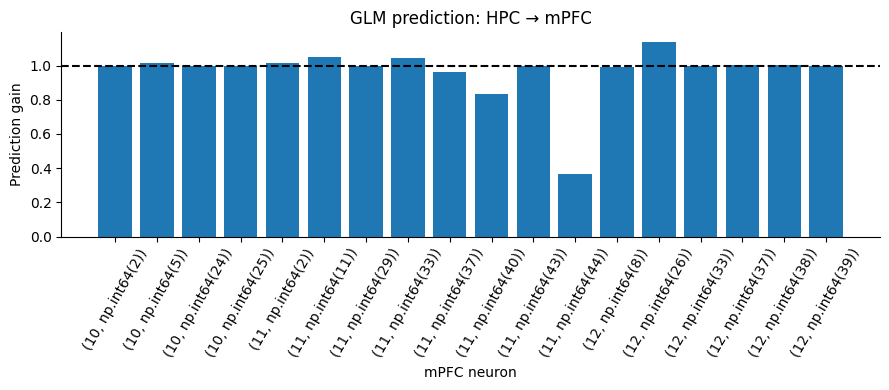

In [49]:
plt.figure(figsize=(9, 4))

x = np.arange(len(df_results_hpc))

plt.bar(
    x,
    df_results_hpc["gain"]
)

plt.axhline(
    1,
    linestyle="--",
    color="black"
)

plt.xticks(
    x,
    df_results_hpc["neuron_id"],
    rotation=60
)

plt.ylabel("Prediction gain")
plt.xlabel("mPFC neuron")
plt.title("GLM prediction: HPC → mPFC")

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [50]:
RE_groups = [1, 2, 3, 4]
re_files = []

for g in RE_groups:
    re_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

In [51]:
re_units = load_units(re_files, FE)

re_units = {
    unit_id: spikes
    for unit_id, spikes in re_units.items()
    if unit_id[1] > 1
} 

print("Nombre d'unités RE:", len(re_units))

Nombre d'unités RE: 69


In [52]:
X_re, re_unit_ids = build_hpc_matrix(re_units, delta_peaks, window=0.200)

print("Shape X_re:", X_re.shape)

Shape X_re: (3338, 69)


In [53]:
keep_re = X_re.sum(axis=0) > 0

X_re = X_re[:, keep_re]

re_units_ids = [unit_id for unit_id, keep in zip(re_unit_ids, keep_re) if keep]

print("Nombre d'unités RE après filtrage:", len(re_units_ids))

Nombre d'unités RE après filtrage: 69


In [54]:
X_hpc_re = np.column_stack([X_hpc, X_re])

print("Shape X_hpc_re:", X_hpc_re.shape)

Shape X_hpc_re: (3338, 130)


In [55]:
results_hpc_re = {}
rows_hpc_re = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_hpc_re, y, n_shuffles=1000, random_state=42)
        results_hpc_re[unit_id] = result

        rows_hpc_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows_hpc_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_hpc_re = pd.DataFrame(rows_hpc_re)

print(df_results_hpc_re[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes
  Gain : 0.9140
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.0000
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9939
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0573
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0197
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0000
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes
  Gain : 1.0012
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0415
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.7361
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes
  Gain : 0.9911
Neurone 11/18 : (11, np.int64(43)) - 18 delta spikes
  Gain : 1.1027
Neurone 12/18 : (11, np.int64(44)) - 7 delta spikes
  Gain : 1.0051
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.6791
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes
  Gain : 0.9906
Neurone 15/18 : (12, np.int64(33)) - 2 delta spike

In [56]:
comparison = df_results_hpc[["neuron_id", "n_delta_spikes", "gain"]].copy()

comparison = comparison.rename(columns={"gain": "gain_hpc"})

comparison["gain_hpc_re"] = df_results_hpc_re["gain"].values

comparison["delta_gain"] = comparison["gain_hpc_re"] - comparison["gain_hpc"]

print(comparison[["neuron_id", "n_delta_spikes", "gain_hpc", "gain_hpc_re", "delta_gain"]].to_string(index=False))

neuron_id  n_delta_spikes  gain_hpc  gain_hpc_re  delta_gain
  (10, 2)               6  1.000000     0.914011   -0.085989
  (10, 5)              24  1.015301     1.000000   -0.015301
 (10, 24)             129  0.999442     0.993946   -0.005496
 (10, 25)              29  1.000000     1.057332    0.057332
  (11, 2)             270  1.012976     1.019691    0.006715
 (11, 11)              16  1.048578     1.000000   -0.048578
 (11, 29)               2  1.000000     1.001212    0.001212
 (11, 33)              75  1.045164     1.041481   -0.003683
 (11, 37)              14  0.960004     0.736056   -0.223948
 (11, 40)               3  0.833783     0.991146    0.157363
 (11, 43)              18  0.999579     1.102710    0.103131
 (11, 44)               7  0.364096     1.005095    0.640999
  (12, 8)              14  0.993625     0.679052   -0.314573
 (12, 26)               3  1.137527     0.990556   -0.146971
 (12, 33)               2  1.000000     1.002687    0.002687
 (12, 37)              9

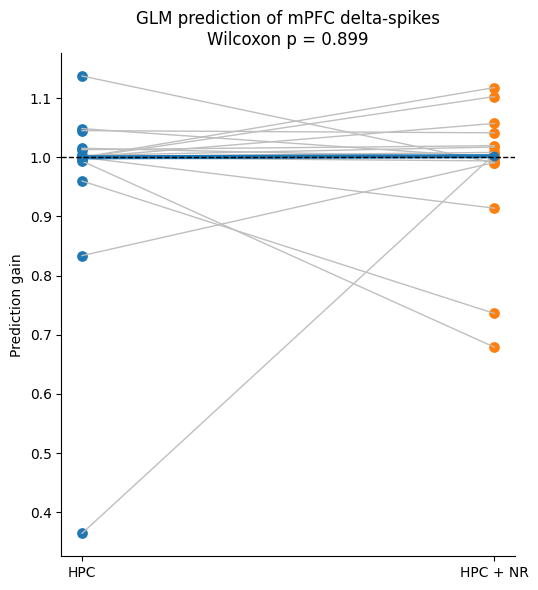

In [57]:
glm_hpc = comparison["gain_hpc"].values
glm_hpc_nr = comparison["gain_hpc_re"].values

stat, p_glm = wilcoxon(glm_hpc, glm_hpc_nr)

fig, ax = plt.subplots(figsize=(5.5, 6))

for i in range(len(glm_hpc)):
    ax.plot(
        [0, 1],
        [glm_hpc[i], glm_hpc_nr[i]],
        color="0.75",
        linewidth=1
    )

ax.scatter(
    np.zeros(len(glm_hpc)),
    glm_hpc,
    s=45
)

ax.scatter(
    np.ones(len(glm_hpc)),
    glm_hpc_nr,
    s=45
)

ax.plot(
    [0, 1],
    [np.median(glm_hpc), np.median(glm_hpc_nr)],
    linewidth=3,
    marker="o"
)

ax.axhline(
    1,
    linestyle="--",
    color="black",
    linewidth=1
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["HPC", "HPC + NR"])

ax.set_ylabel("Prediction gain")
ax.set_title(
    f"GLM prediction of mPFC delta-spikes\nWilcoxon p = {p_glm:.3f}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

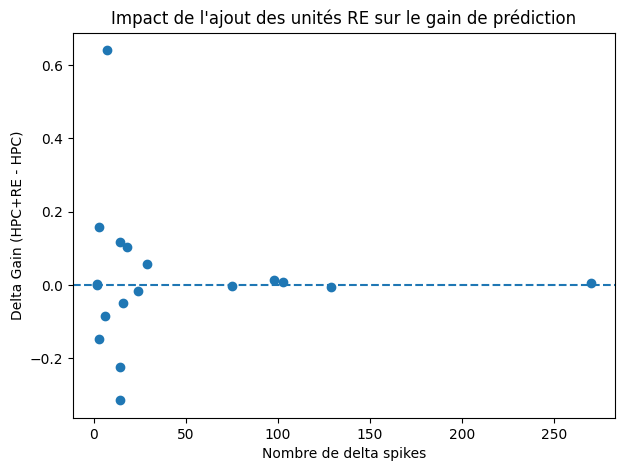

In [58]:
plt.figure(figsize=(7,5))

plt.scatter(comparison["n_delta_spikes"], comparison["delta_gain"])

plt.axhline(0, linestyle="--")

plt.xlabel("Nombre de delta spikes")
plt.ylabel("Delta Gain (HPC+RE - HPC)")
plt.title("Impact de l'ajout des unités RE sur le gain de prédiction")

plt.show()

In [59]:
results_re = {}
rows_re = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_re, y, n_shuffles=1000, random_state=42)
        results_re[unit_id] = result

        rows_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_re = pd.DataFrame(rows_re)

print(df_results_re[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes
  Gain : 0.7782
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.1343
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9957
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0058
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0083
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0000
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes
  Gain : 1.0000
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0018
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.9968
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes
  Gain : 0.9843
Neurone 11/18 : (11, np.int64(43)) - 18 delta spikes
  Gain : 1.1877
Neurone 12/18 : (11, np.int64(44)) - 7 delta spikes
  Gain : nan
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.9763
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes
  Gain : 0.9814
Neurone 15/18 : (12, np.int64(33)) - 2 delta spikes
 

In [60]:
comparison_all = df_results_hpc[["neuron_id", "n_delta_spikes", "gain"]].copy()

comparison_all = comparison.rename(columns={"gain": "gain_hpc"})

comparison_all["gain_re"] = df_results_re["gain"].values

comparison_all["gain_hpc_re"] = df_results_hpc_re["gain"].values

comparison_all["delta_gain"] = comparison_all["gain_hpc_re"] - comparison_all["gain_hpc"]

print(comparison_all.to_string(index=False))

neuron_id  n_delta_spikes  gain_hpc  gain_hpc_re  delta_gain  gain_re
  (10, 2)               6  1.000000     0.914011   -0.085989 0.778196
  (10, 5)              24  1.015301     1.000000   -0.015301 1.134301
 (10, 24)             129  0.999442     0.993946   -0.005496 0.995679
 (10, 25)              29  1.000000     1.057332    0.057332 1.005812
  (11, 2)             270  1.012976     1.019691    0.006715 1.008297
 (11, 11)              16  1.048578     1.000000   -0.048578 1.000000
 (11, 29)               2  1.000000     1.001212    0.001212 1.000000
 (11, 33)              75  1.045164     1.041481   -0.003683 1.001823
 (11, 37)              14  0.960004     0.736056   -0.223948 0.996804
 (11, 40)               3  0.833783     0.991146    0.157363 0.984250
 (11, 43)              18  0.999579     1.102710    0.103131 1.187661
 (11, 44)               7  0.364096     1.005095    0.640999      NaN
  (12, 8)              14  0.993625     0.679052   -0.314573 0.976256
 (12, 26)           

In [61]:
def build_matrix_window(units, delta_peaks, start, end):
    
    unit_ids = list(units.keys())

    X = np.zeros(
        (len(delta_peaks), len(unit_ids)),
        dtype=int
    )

    for j, unit_id in enumerate(unit_ids):

        spikes = np.asarray(units[unit_id])

        left = np.searchsorted(
            spikes,
            delta_peaks + start,
            side="left"
        )

        right = np.searchsorted(
            spikes,
            delta_peaks + end,
            side="left"
        )

        X[:, j] = right - left

    return X, unit_ids

re_windows = [
    (-0.500, -0.300),
    (-0.400, -0.200),
    (-0.300, -0.100),
    (-0.200,  0.000),
    (-0.100,  0.100),
    ( 0.000,  0.200)
]

In [62]:
re_matrices = {}

for start, end in re_windows:

    X_re_window, re_ids_window = build_matrix_window(
        re_units,
        delta_peaks,
        start,
        end
    )

    keep = X_re_window.sum(axis=0) > 0

    X_re_window = X_re_window[:, keep]

    re_ids_window = [
        unit_id
        for unit_id, k in zip(re_ids_window, keep)
        if k
    ]

    key = (start, end)

    re_matrices[key] = {
        "X": X_re_window,
        "unit_ids": re_ids_window
    }

    print(
        f"Fenêtre {start*1000:.0f} à {end*1000:.0f} ms : "
        f"{X_re_window.shape[1]} unités RE"
    )

Fenêtre -500 à -300 ms : 69 unités RE
Fenêtre -400 à -200 ms : 69 unités RE
Fenêtre -300 à -100 ms : 69 unités RE
Fenêtre -200 à 0 ms : 69 unités RE
Fenêtre -100 à 100 ms : 69 unités RE
Fenêtre 0 à 200 ms : 69 unités RE


In [63]:
j = mpfc_units_ids.index((11, 2))

y = Y_mpfc[:, j]

folds_test = make_folds(
    y,
    random_state=42
)

print("Nombre de delta spikes :", y.sum())
print("Nombre de folds :", len(folds_test))

X_test_re = re_matrices[(-0.200, 0.000)]["X"]

print("Dimensions RE :", X_test_re.shape)

Nombre de delta spikes : 270
Nombre de folds : 270
Dimensions RE : (3338, 69)


In [64]:
result_test_re = compute_pred_gain(
    X_test_re,
    y,
    n_shuffles=1000,
    random_state=42,
    folds=folds_test
)

print("Gain RE :", result_test_re["gain"])
print("e :", result_test_re["e"])
print("e_shuffled :", result_test_re["e_shuffled"])
print("Folds non convergés :", result_test_re["n_not_converged"])

Gain RE : 1.0079602010293556
e : 0.07576740936273207
e_shuffled : 0.0763705331727329
Folds non convergés : 0


In [65]:
delay_results = []

for start, end in re_windows:

    X_re_window = re_matrices[(start, end)]["X"]

    print(
        f"\nFenêtre RE : {start*1000:.0f} à {end*1000:.0f} ms"
    )

    for neuron_id in range(Y_mpfc.shape[1]):

        unit_id = mpfc_units_ids[neuron_id]
        y = Y_mpfc[:, neuron_id]

        try:

            result = compute_pred_gain(
                X_re_window,
                y,
                n_shuffles=1000,
                random_state=42
            )

            delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_re": result["gain"],
                "n_not_converged": result["n_not_converged"]
            })

        except Exception as error:

            delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_re": np.nan,
                "n_not_converged": np.nan
            })


Fenêtre RE : -500 à -300 ms

Fenêtre RE : -400 à -200 ms

Fenêtre RE : -300 à -100 ms

Fenêtre RE : -200 à 0 ms

Fenêtre RE : -100 à 100 ms

Fenêtre RE : 0 à 200 ms


In [66]:
df_re_delays = pd.DataFrame(delay_results)

summary_re_delays = (
    df_re_delays
    .groupby(
        ["window_start_ms", "window_end_ms"]
    )["gain_re"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

summary_re_delays

,window_start_ms,window_end_ms,mean,median,count
0,-500,-300,0.989673,1.001166,18
1,-400,-200,1.034216,1.000000,18
2,-300,-100,0.972843,1.000000,18
3,-200,0,1.000200,1.000000,17
4,-100,100,0.990462,1.000000,18
5,0,200,0.996607,1.000000,17


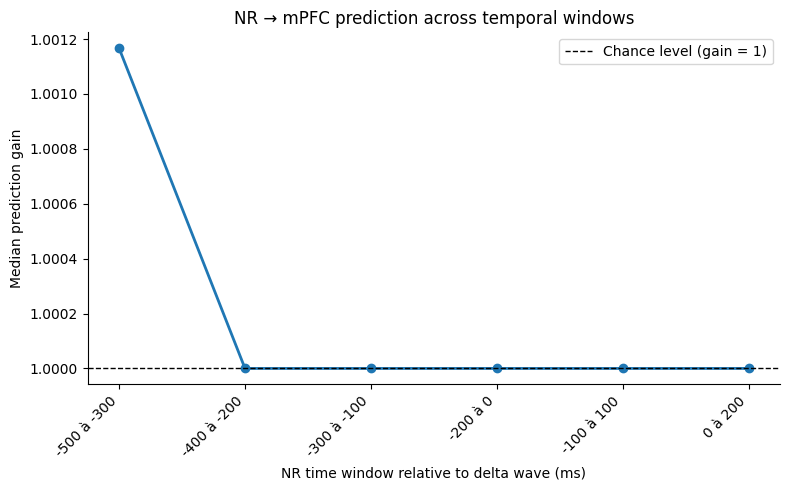

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = [
    f"{int(start)} à {int(end)}"
    for start, end in zip(
        summary_re_delays["window_start_ms"],
        summary_re_delays["window_end_ms"]
    )
]

x = np.arange(len(labels))

ax.plot(
    x,
    summary_re_delays["median"],
    marker="o",
    linewidth=2
)

ax.axhline(
    1,
    linestyle="--",
    color="black",
    linewidth=1,
    label="Chance level (gain = 1)"
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_xlabel("NR time window relative to delta wave (ms)")
ax.set_ylabel("Median prediction gain")
ax.set_title("NR → mPFC prediction across temporal windows")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [68]:
hpc_re_delay_results = []

for neuron_id in range(Y_mpfc.shape[1]):

    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    # mêmes folds pour toutes les comparaisons de ce neurone
    folds_neuron = make_folds(
        y,
        random_state=42
    )

    print(
        f"\nNeurone {unit_id} "
        f"({int(y.sum())} delta spikes)"
    )

    for start, end in re_windows:

        X_re_window = re_matrices[(start, end)]["X"]

        # HPC fixe + RE à ce délai
        X_hpc_re_window = np.column_stack(
            (X_hpc, X_re_window)
        )

        print(
            f"  HPC + RE {start*1000:.0f} à {end*1000:.0f} ms"
        )

        try:

            result = compute_pred_gain(
                X_hpc_re_window,
                y,
                n_shuffles=1000,
                random_state=42,
                folds=folds_neuron
            )

            hpc_re_delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_hpc_re": result["gain"],
                "e": result["e"],
                "e_shuffled": result["e_shuffled"],
                "n_not_converged": result["n_not_converged"]
            })

        except Exception as error:

            print("    ERREUR :", error)

            hpc_re_delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_hpc_re": np.nan,
                "e": np.nan,
                "e_shuffled": np.nan,
                "n_not_converged": np.nan
            })


Neurone (10, np.int64(2)) (6 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (10, np.int64(5)) (24 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (10, np.int64(24)) (129 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (10, np.int64(25)) (29 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (11, np.int64(2)) (270 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (11, np.int64(11)) (16 

In [69]:
df_hpc_re_delays = pd.DataFrame(
    hpc_re_delay_results
)

df_hpc_re_delays.head()

,neuron_id,n_delta_spikes,window_start_ms,window_end_ms,gain_hpc_re,e,e_shuffled,n_not_converged
0,"(10, 2)",6,-500,-300,1.000000,1.766978e-31,1.766978e-31,0
1,"(10, 2)",6,-400,-200,1.016338,1.109162e-30,1.127283e-30,0
2,"(10, 2)",6,-300,-100,1.000000,1.029972e-33,1.029972e-33,0
3,"(10, 2)",6,-200,0,0.884485,3.653549e-33,3.231511e-33,0
4,"(10, 2)",6,-100,100,0.990214,2.290356e-32,2.267943e-32,0


In [70]:
print(df_results_hpc.columns)

Index(['neuron_id', 'n_delta_spikes', 'n_folds', 'e', 'e_shuffled', 'gain',
       'n_not_converged'],
      dtype='object')


In [71]:
comparison_delays = df_hpc_re_delays.merge(
    df_results_hpc[
        ["neuron_id", "gain"]
    ],
    on="neuron_id",
    how="left"
)

comparison_delays = comparison_delays.rename(
    columns={"gain": "gain_hpc"}
)

comparison_delays["delta_gain"] = (
    comparison_delays["gain_hpc_re"]
    - comparison_delays["gain_hpc"]
)

In [72]:
summary_hpc_re_delays = (
    comparison_delays
    .groupby(
        ["window_start_ms", "window_end_ms"]
    )["delta_gain"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

summary_hpc_re_delays

,window_start_ms,window_end_ms,mean,median,count
0,-500,-300,-0.022753,0.006199,18
1,-400,-200,0.016073,0.010979,18
2,-300,-100,0.059812,0.000000,18
3,-200,0,0.018691,0.005060,18
4,-100,100,0.073919,0.001678,18
5,0,200,0.066068,0.009201,18


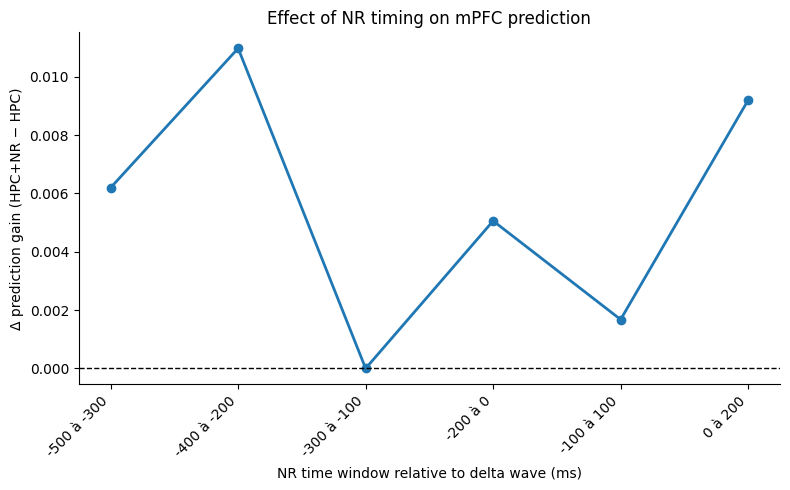

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = [
    f"{int(start)} à {int(end)}"
    for start, end in zip(
        summary_hpc_re_delays["window_start_ms"],
        summary_hpc_re_delays["window_end_ms"]
    )
]

x = np.arange(len(labels))

ax.plot(
    x,
    summary_hpc_re_delays["median"],
    marker="o",
    linewidth=2
)

ax.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_xlabel("NR time window relative to delta wave (ms)")
ax.set_ylabel("Δ prediction gain (HPC+NR − HPC)")
ax.set_title("Effect of NR timing on mPFC prediction")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [74]:
pivot_delta = comparison_delays.pivot(
    index=["neuron_id", "n_delta_spikes"],
    columns="window_start_ms",
    values="delta_gain"
)

pivot_delta.columns = [
    f"{int(x)} ms"
    for x in pivot_delta.columns
]

pivot_delta

,,-500 ms,-400 ms,-300 ms,-200 ms,-100 ms,0 ms
neuron_id,n_delta_spikes,,,,,,
"(10, 2)",6,0.000000,0.016338,0.000000,-0.115515,-0.009786,0.000000
"(10, 5)",24,-0.698044,-0.125182,-0.015301,-0.015301,-0.015301,-0.045073
"(10, 24)",129,0.009868,0.012756,-0.002172,-0.005906,0.003356,0.003668
"(10, 25)",29,-0.035013,-0.037736,-0.035816,0.046377,-0.021226,-0.020618
"(11, 2)",270,0.016771,0.019350,0.016636,0.006461,0.010509,0.014657
"(11, 11)",16,-0.096441,0.012972,0.003062,-0.048578,0.803700,0.673873
"(11, 29)",2,0.002530,0.000000,0.000000,0.005737,0.000000,0.000000
"(11, 33)",75,-0.023901,-0.008708,-0.019148,-0.006259,-0.003310,0.036527
"(11, 37)",14,0.039996,0.039996,0.122866,-0.317457,-0.304459,0.077659


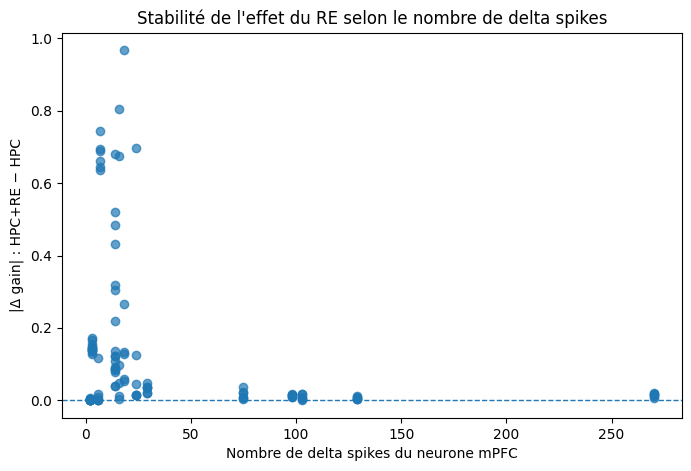

In [75]:
comparison_delays["abs_delta_gain"] = (
    comparison_delays["delta_gain"].abs()
)

plt.figure(figsize=(8, 5))

plt.scatter(
    comparison_delays["n_delta_spikes"],
    comparison_delays["abs_delta_gain"],
    alpha=0.7
)

plt.xlabel("Nombre de delta spikes du neurone mPFC")
plt.ylabel("|Δ gain| : HPC+RE − HPC")
plt.title("Stabilité de l'effet du RE selon le nombre de delta spikes")

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.show()

In [76]:
rho, p = spearmanr(
    comparison_delays["n_delta_spikes"],
    comparison_delays["abs_delta_gain"]
)

print("rho =", rho)
print("p =", p)

rho = -0.15266110042648884
p = 0.11472647126892718


In [77]:
stability_by_neuron = (
    comparison_delays
    .groupby(["neuron_id", "n_delta_spikes"])
    ["abs_delta_gain"]
    .mean()
    .reset_index()
)

rho_neuron, p_neuron = spearmanr(
    stability_by_neuron["n_delta_spikes"],
    stability_by_neuron["abs_delta_gain"]
)

print("rho par neurone =", rho_neuron)
print("p par neurone =", p_neuron)

rho par neurone = -0.16252666367868826
p par neurone = 0.5193514322268609


In [78]:
wilcoxon_results = []

for start, end in re_windows:

    temp = comparison_delays[
        (comparison_delays["window_start_ms"] == int(start * 1000)) &
        (comparison_delays["window_end_ms"] == int(end * 1000))
    ].dropna(
        subset=["gain_hpc", "gain_hpc_re"]
    )

    stat, p = wilcoxon(
        temp["gain_hpc_re"],
        temp["gain_hpc"]
    )

    wilcoxon_results.append({
        "window_start_ms": int(start * 1000),
        "window_end_ms": int(end * 1000),
        "n_neurons": len(temp),
        "median_delta_gain": temp["delta_gain"].median(),
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(wilcoxon_results)

df_wilcoxon

,window_start_ms,window_end_ms,n_neurons,median_delta_gain,p_value
0,-500,-300,18,0.006199,0.876722
1,-400,-200,18,0.010979,0.351979
2,-300,-100,18,0.000000,0.820280
3,-200,0,18,0.005060,0.932281
4,-100,100,18,0.001678,0.437967
5,0,200,18,0.009201,0.147660


In [79]:
print(deltawaves.keys())

for key in deltawaves.keys():
    x = np.asarray(deltawaves[key])
    print(
        key,
        "shape =", x.shape,
        "dtype =", x.dtype
    )

dict_keys(['timestamps', 'peaks', 'peakNormedPower', 'detectorName', 'troughValue', 'badIntervals'])
timestamps shape = (3338, 2) dtype = float64
peaks shape = (3338,) dtype = float64
peakNormedPower shape = (3338,) dtype = float64
detectorName shape = () dtype = <U61
troughValue shape = (3338,) dtype = float64
badIntervals shape = (0,) dtype = uint8


In [80]:
print(deltawaves["detectorName"])

channel 159 (+1), CleanLFP, FindDeltaWaves, peak-trough > 3.7


In [81]:
# Fenêtre : -500 à +500 ms
window = 0.500

# Bins de 10 ms
bin_size = 0.010

bins = np.arange(
    -window,
    window + bin_size,
    bin_size
)

all_relative_spikes = []

for unit_id, spikes in mpfc_units.items():

    spikes = np.asarray(spikes)

    for delta in delta_peaks:

        left = np.searchsorted(
            spikes,
            delta - window,
            side="left"
        )

        right = np.searchsorted(
            spikes,
            delta + window,
            side="right"
        )

        relative_spikes = spikes[left:right] - delta

        all_relative_spikes.extend(relative_spikes)

all_relative_spikes = np.asarray(all_relative_spikes)

print("Nombre total de spikes autour des delta waves :",
      len(all_relative_spikes))

Nombre total de spikes autour des delta waves : 148802


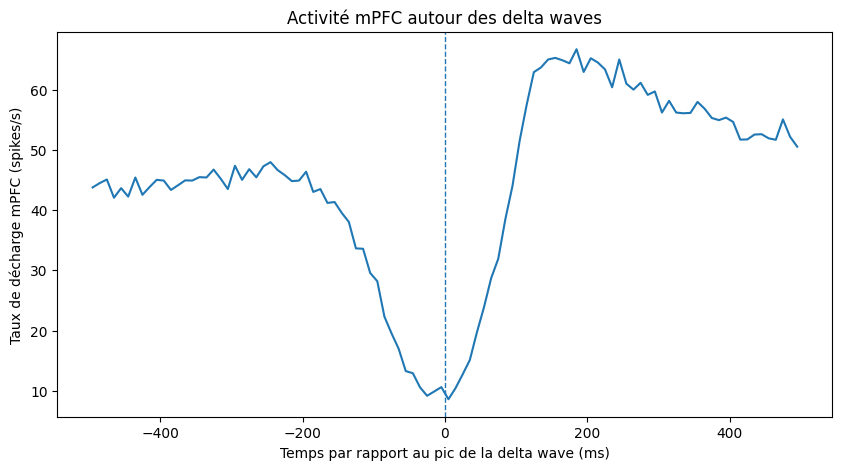

In [82]:
counts, edges = np.histogram(
    all_relative_spikes,
    bins=bins
)

# Nombre moyen de spikes par delta wave et par seconde
rate = counts / (len(delta_peaks) * bin_size)

centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10, 5))

plt.plot(
    centers * 1000,
    rate
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Temps par rapport au pic de la delta wave (ms)")
plt.ylabel("Taux de décharge mPFC (spikes/s)")
plt.title("Activité mPFC autour des delta waves")

plt.show()

In [83]:
j = mpfc_units_ids.index((11, 2))

y = Y_mpfc[:, j]

print("Nombre total de delta waves :", len(y))
print("Nombre de delta spikes :", y.sum())
print("Nombre de non-delta spikes :", len(y) - y.sum())
print("Valeurs uniques dans y :", np.unique(y, return_counts=True))

Nombre total de delta waves : 3338
Nombre de delta spikes : 270
Nombre de non-delta spikes : 3068
Valeurs uniques dans y : (array([0, 1]), array([3068,  270]))


In [84]:
folds = make_folds(y, random_state=42)

print("Nombre de folds :", len(folds))

# Vérification de quelques folds
for i in range(5):
    train_idx, test_idx = folds[i]

    print(
        f"Fold {i+1} :",
        "test =", len(test_idx),
        "| positifs test =", y[test_idx].sum(),
        "| négatifs test =", len(test_idx) - y[test_idx].sum(),
        "| positifs train =", y[train_idx].sum()
    )

# Vérifie que chaque événement est testé exactement une fois
all_test_idx = np.concatenate(
    [test_idx for _, test_idx in folds]
)

print("\nÉvénements testés :", len(all_test_idx))
print("Événements uniques testés :", len(np.unique(all_test_idx)))

Nombre de folds : 270
Fold 1 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 2 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 3 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 4 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 5 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269

Événements testés : 3338
Événements uniques testés : 3338


In [85]:
predictions = np.full(len(y), np.nan)

for train_idx, test_idx in folds:

    X_train = X_hpc[train_idx]
    X_test = X_hpc[test_idx]

    y_train = y[train_idx]

    X_train_glm = sm.add_constant(
        X_train,
        has_constant="add"
    )

    X_test_glm = sm.add_constant(
        X_test,
        has_constant="add"
    )

    model = sm.GLM(
        y_train,
        X_train_glm,
        family=sm.families.Binomial()
    )

    results = model.fit()

    predictions[test_idx] = results.predict(
        X_test_glm
    )

print("NaN :", np.isnan(predictions).sum())

print("\nPrédictions pour y = 1")
print("moyenne :", predictions[y == 1].mean())
print("médiane :", np.median(predictions[y == 1]))

print("\nPrédictions pour y = 0")
print("moyenne :", predictions[y == 0].mean())
print("médiane :", np.median(predictions[y == 0]))

print("\nMin :", predictions.min())
print("Max :", predictions.max())

NaN : 0

Prédictions pour y = 1
moyenne : 0.10843143392702811
médiane : 0.08840082236526248

Prédictions pour y = 0
moyenne : 0.07878738184828117
médiane : 0.06847045345778868

Min : 0.00015460682586303568
Max : 0.5794746873796265


In [86]:
errors = np.abs(predictions - y)

errors_pos = errors[y == 1]
errors_neg = errors[y == 0]

print("ERREUR GLOBALE")
print("moyenne :", np.mean(errors))
print("médiane :", np.median(errors))

print("\nERREUR POUR y = 1")
print("moyenne :", np.mean(errors_pos))
print("médiane :", np.median(errors_pos))

print("\nERREUR POUR y = 0")
print("moyenne :", np.mean(errors_neg))
print("médiane :", np.median(errors_neg))

print("\nNombre y=1 :", len(errors_pos))
print("Nombre y=0 :", len(errors_neg))

ERREUR GLOBALE
moyenne : 0.1445306172409314
médiane : 0.0726551319778615

ERREUR POUR y = 1
moyenne : 0.8915685660729717
médiane : 0.9115991776347375

ERREUR POUR y = 0
moyenne : 0.07878738184828117
médiane : 0.06847045345778868

Nombre y=1 : 270
Nombre y=0 : 3068


In [87]:
unit_id = (11, 2)
spikes = np.asarray(mpfc_units[unit_id])

relative_spikes = []

for delta in delta_peaks:
    left = np.searchsorted(
        spikes,
        delta - 0.050,
        side="left"
    )
    right = np.searchsorted(
        spikes,
        delta + 0.050,
        side="right"
    )

    relative_spikes.extend(
        spikes[left:right] - delta
    )

relative_spikes = np.asarray(relative_spikes)

print("Nombre de spikes entre -50 et +50 ms :", len(relative_spikes))
print("Nombre dans ±15 ms :", np.sum(np.abs(relative_spikes) <= 0.015))

Nombre de spikes entre -50 et +50 ms : 1035
Nombre dans ±15 ms : 290


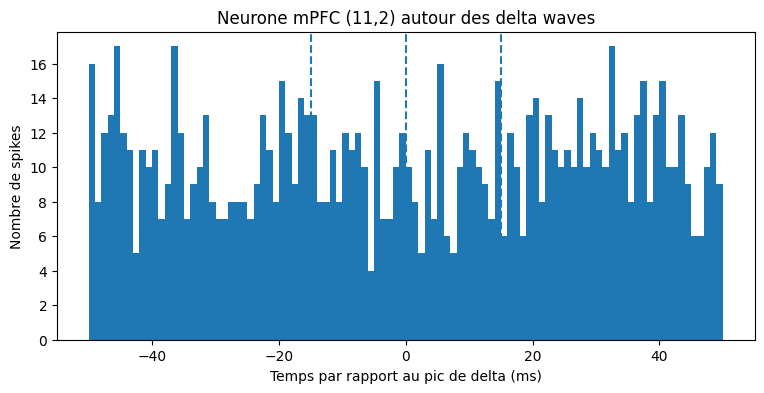

In [88]:
plt.figure(figsize=(9, 4))

plt.hist(
    relative_spikes * 1000,
    bins=np.arange(-50, 51, 1)
)

plt.axvline(-15, linestyle="--")
plt.axvline(0, linestyle="--")
plt.axvline(15, linestyle="--")

plt.xlabel("Temps par rapport au pic de delta (ms)")
plt.ylabel("Nombre de spikes")
plt.title("Neurone mPFC (11,2) autour des delta waves")

plt.show()

In [89]:
predictions_l2 = np.full(len(y), np.nan)

for train_idx, test_idx in folds:

    X_train = X_hpc[train_idx]
    X_test = X_hpc[test_idx]

    y_train = y[train_idx]

    # Normalisation apprise UNIQUEMENT sur le train
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Régression logistique avec régularisation L2
    model_l2 = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000
    )

    model_l2.fit(
        X_train_scaled,
        y_train
    )

    predictions_l2[test_idx] = model_l2.predict_proba(
        X_test_scaled
    )[:, 1]

print("NaN :", np.isnan(predictions_l2).sum())

print("\nPrédictions L2 pour y = 1")
print("moyenne :", predictions_l2[y == 1].mean())
print("médiane :", np.median(predictions_l2[y == 1]))

print("\nPrédictions L2 pour y = 0")
print("moyenne :", predictions_l2[y == 0].mean())
print("médiane :", np.median(predictions_l2[y == 0]))

print("\nMin :", predictions_l2.min())
print("Max :", predictions_l2.max())

NaN : 0

Prédictions L2 pour y = 1
moyenne : 0.10830510821910921
médiane : 0.0883832012745511

Prédictions L2 pour y = 0
moyenne : 0.07879025764670967
médiane : 0.06862027806633848

Min : 0.00019048551985340487
Max : 0.5778806096043424


In [90]:
errors_l2 = np.abs(
    predictions_l2 - y
)

e_l2 = np.median(errors_l2)

rng = np.random.default_rng(42)

shuffled_errors_l2 = []

for i in range(1000):

    shuffled_predictions = rng.permutation(
        predictions_l2
    )

    shuffled_error = np.median(
        np.abs(shuffled_predictions - y)
    )

    shuffled_errors_l2.append(
        shuffled_error
    )

e_shuffled_l2 = np.median(
    shuffled_errors_l2
)

g_l2 = e_shuffled_l2 / e_l2

print("e L2 =", e_l2)
print("e shuffled L2 =", e_shuffled_l2)
print("gain L2 =", g_l2)

print("\nRappel GLM Todorova :")
print("gain GLM ≈ 1.01298")

e L2 = 0.07284089328854929
e shuffled L2 = 0.0736374005761536
gain L2 = 1.010934891812063

Rappel GLM Todorova :
gain GLM ≈ 1.01298


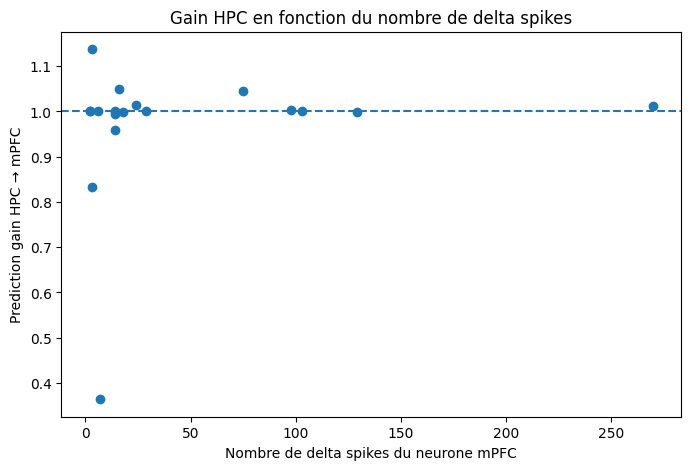

In [91]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_results_hpc["n_delta_spikes"],
    df_results_hpc["gain"]
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel("Nombre de delta spikes du neurone mPFC")
plt.ylabel("Prediction gain HPC → mPFC")
plt.title("Gain HPC en fonction du nombre de delta spikes")

plt.show()

In [92]:
rho, p = spearmanr(
    df_results_hpc["n_delta_spikes"],
    df_results_hpc["gain"]
)

print("Spearman rho =", rho)
print("p =", p)

Spearman rho = 0.2772040838648302
p = 0.2654303051766455


In [93]:
def build_hpc_sequence_exact(hpc_units, delta_peaks):

    unit_ids = list(hpc_units.keys())

    bin_edges = np.linspace(-0.200, 0.0, 21)

    bin_edges[0] = -0.200
    bin_edges[-1] = 0.0

    X_seq = np.zeros(
        (len(delta_peaks), len(unit_ids), 20),
        dtype=np.float32
    )

    for neuron_idx, unit_id in enumerate(unit_ids):

        spikes = np.asarray(hpc_units[unit_id])

        for bin_idx in range(20):

            # Pour chaque bin, m�mes r�gles :
            # [borne gauche, borne droite[
            left = np.searchsorted(
                spikes,
                delta_peaks + bin_edges[bin_idx],
                side="left"
            )

            right = np.searchsorted(
                spikes,
                delta_peaks + bin_edges[bin_idx + 1],
                side="left"
            )

            X_seq[:, neuron_idx, bin_idx] = (
                right - left
            )

    return X_seq, unit_ids, bin_edges

In [94]:
X_seq, hpc_seq_unit_ids, seq_edges = build_hpc_sequence_exact(
    hpc_units,
    delta_peaks
)

X_seq_sum = X_seq.sum(axis=2)

print("Shape X_seq :", X_seq.shape)

print(
    "Nombre de différences :",
    np.sum(X_seq_sum != X_hpc)
)

print(
    "Différence maximale :",
    np.max(np.abs(X_seq_sum - X_hpc))
)

Shape X_seq : (3338, 61, 20)
Nombre de différences : 13
Différence maximale : 1.0


In [95]:
j = mpfc_units_ids.index((11, 2))
y_cnn = Y_mpfc[:, j].astype(np.float32)

print("X_seq :", X_seq.shape)
print("y_cnn :", y_cnn.shape)
print("Positifs :", int(y_cnn.sum()))
print("Négatifs :", len(y_cnn) - int(y_cnn.sum()))

X_seq : (3338, 61, 20)
y_cnn : (3338,)
Positifs : 270
Négatifs : 3068


In [96]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X_seq,
    y_cnn,
    test_size=0.20,
    stratify=y_cnn,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=42
)

In [97]:
X_train_cnn = np.transpose(X_train, (0, 2, 1))
X_val_cnn = np.transpose(X_val, (0, 2, 1))
X_test_cnn = np.transpose(X_test, (0, 2, 1))

print("TRAIN :", X_train_cnn.shape)
print("VALIDATION :", X_val_cnn.shape)
print("TEST :", X_test_cnn.shape)

TRAIN : (2002, 20, 61)
VALIDATION : (668, 20, 61)
TEST : (668, 20, 61)


In [98]:
model_cnn = models.Sequential([
    layers.Input(shape=(20, 61)),

    layers.Conv1D(
        filters=16,
        kernel_size=3,
        activation="relu"
    ),

    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(curve="PR", name="auc_pr")
    ]
)

model_cnn.summary()

I0000 00:00:1789395994.546493 1546615 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 28214 MB memory:  -> device: 0, name: NVIDIA RTX 5000 Ada Generation, pci bus id: 0000:0a:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 16)         │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
early_stopping = EarlyStopping(
    monitor="val_auc_pr",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [100]:
history = model_cnn.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


I0000 00:00:1789395996.767254 1752061 service.cc:153] XLA service 0x723140031c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789395996.767302 1752061 service.cc:161]   StreamExecutor [0]: NVIDIA RTX 5000 Ada Generation, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1789395996.808551 1752061 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789395997.003015 1752061 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1789395997.056913 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2026__.30


57/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc_pr: 0.1046 - auc_roc: 0.5338 - loss: 0.5659

I0000 00:00:1789396000.392419 1752061 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1789396000.752289 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2026__.30


63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 151ms/step - auc_pr: 0.0881 - auc_roc: 0.5152 - loss: 0.4394 - val_auc_pr: 0.0824 - val_auc_roc: 0.5087 - val_loss: 0.3095
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.0850 - auc_roc: 0.5217 - loss: 0.3178 - val_auc_pr: 0.0830 - val_auc_roc: 0.5099 - val_loss: 0.2990
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.0868 - auc_roc: 0.5410 - loss: 0.3002 - val_auc_pr: 0.0837 - val_auc_roc: 0.5121 - val_loss: 0.2924
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc_pr: 0.0973 - auc_roc: 0.5712 - loss: 0.2905 - val_auc_pr: 0.0851 - val_auc_roc: 0.5192 - val_loss: 0.2888
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.1037 - auc_roc: 0.6053 - loss: 0.2824 - val_auc_pr: 0.0859 - val_auc_roc: 0.5182 - val_loss: 0.2873
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc_pr: 0.1159 - auc_roc: 0.6293 - loss: 0.2764 - val_auc_pr: 0.0877 - val_auc_roc: 0.5143 - val_loss: 0.2860
Epoch 7/100
63/63 ━━━━━━━━━━━━━

In [101]:
X_dev_cnn = np.concatenate(
    [X_train_cnn, X_val_cnn],
    axis=0
)

y_dev_cnn = np.concatenate(
    [y_train, y_val],
    axis=0
)

print("X_dev_cnn :", X_dev_cnn.shape)
print("y_dev_cnn :", y_dev_cnn.shape)
print("positifs :", int(y_dev_cnn.sum()))
print("négatifs :", len(y_dev_cnn) - int(y_dev_cnn.sum()))

X_dev_cnn : (2670, 20, 61)
y_dev_cnn : (2670,)
positifs : 216
négatifs : 2454


In [102]:
def build_cnn(
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.3,
    learning_rate=1e-3
):

    model = models.Sequential([
        layers.Input(shape=(20, 61)),

        layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu"
        ),

        layers.Dropout(dropout),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy"
    )

    return model

In [103]:
cnn_classifier = KerasClassifier(
    model=build_cnn,
    epochs=30,
    batch_size=32,
    verbose=0,
    random_state=42
)

In [104]:
def ap_scorer(estimator, X, y):
    proba = estimator.predict_proba(X)

    if proba.ndim == 2:
        proba = proba[:, 1]

    return average_precision_score(y, proba)

In [105]:
param_grid = {
    "model__filters": [8, 16, 32],
    "model__kernel_size": [2, 3, 5],
    "model__dense_units": [8, 16],
    "model__dropout": [0.2, 0.4],
    "model__learning_rate": [3e-4, 1e-3]
}

In [106]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [107]:
grid_search = GridSearchCV(
    estimator=cnn_classifier,
    param_grid=param_grid,
    scoring=ap_scorer,
    cv=cv,
    n_jobs=1,
    verbose=2
)

In [108]:
grid_search.fit(
    X_dev_cnn,
    y_dev_cnn
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


E0000 00:00:1789396014.967172 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  17.1s


E0000 00:00:1789396031.989848 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789396047.585854 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.4s


E0000 00:00:1789396062.031387 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.2s


E0000 00:00:1789396076.206268 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789396091.361614 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789396106.681256 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789396121.670104 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789396136.971929 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789396152.123207 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789396167.517493 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789396182.999137 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789396198.283723 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.6s


E0000 00:00:1789396212.920274 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789396228.265558 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789396243.807216 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789396258.559961 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789396273.921187 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.8s


E0000 00:00:1789396289.745520 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789396304.444102 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789396319.924073 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789396334.794006 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789396349.965362 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.6s


E0000 00:00:1789396364.535404 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789396379.460330 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789396394.857107 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.4s


E0000 00:00:1789396409.270338 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.7s


E0000 00:00:1789396424.980370 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789396440.453954 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789396455.827065 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789396470.985208 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789396486.630897 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789396501.944332 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  16.0s


E0000 00:00:1789396517.973805 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.4s


E0000 00:00:1789396532.369409 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.1s


E0000 00:00:1789396547.454414 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.7s


E0000 00:00:1789396563.165164 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789396578.623648 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789396593.281861 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789396608.624607 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789396623.499708 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789396639.000149 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789396653.840554 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.5s


E0000 00:00:1789396668.409907 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789396684.193071 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789396699.671425 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789396715.188588 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  16.3s


E0000 00:00:1789396731.470639 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789396746.157198 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789396760.840927 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789396775.751088 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789396791.076128 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789396806.435137 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789396821.798875 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789396837.182626 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789396852.730335 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789396867.559166 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789396882.597904 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789396898.121210 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789396913.451828 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789396928.588412 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789396943.443095 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789396958.212841 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789396972.997037 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789396988.560597 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789397004.327404 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789397019.292185 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789397034.600599 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789397050.130919 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789397065.590322 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  14.2s


E0000 00:00:1789397079.743081 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789397095.005834 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789397109.893975 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789397125.148789 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789397140.488044 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789397155.255360 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789397170.047522 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789397184.741117 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789397199.507242 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789397214.663836 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789397229.576763 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789397245.057572 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789397260.254252 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.1s


E0000 00:00:1789397275.352186 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  16.2s


E0000 00:00:1789397291.523052 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789397306.693809 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789397322.260786 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789397337.355433 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789397352.810762 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.8s


E0000 00:00:1789397368.596500 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789397384.060693 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789397399.593488 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789397414.598033 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789397430.052534 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789397445.396382 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789397460.554073 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789397476.055847 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789397491.627204 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789397506.936347 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789397521.844068 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789397537.168654 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789397552.112846 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789397567.309074 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.3s


E0000 00:00:1789397581.654389 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789397596.834452 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789397611.889683 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789397626.922065 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789397642.545871 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  16.6s


E0000 00:00:1789397659.138408 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789397674.428359 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789397689.582976 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789397705.119238 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789397720.652650 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789397736.000467 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789397751.354956 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789397766.638470 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789397781.443374 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789397796.677606 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789397812.266283 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.6s


E0000 00:00:1789397826.822393 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789397842.254483 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789397857.790197 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789397873.320838 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789397888.340673 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.9s


E0000 00:00:1789397904.187893 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789397919.064439 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  14.6s


E0000 00:00:1789397933.679527 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789397948.455303 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789397963.431814 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789397978.756095 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  14.6s


E0000 00:00:1789397993.336544 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789398008.764629 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398024.098256 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.1s


E0000 00:00:1789398039.215143 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398054.523791 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  16.8s


E0000 00:00:1789398071.304530 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789398086.549159 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789398101.860620 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.8s


E0000 00:00:1789398117.681688 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789398133.169762 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789398148.417151 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789398163.587995 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789398178.594048 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789398194.388689 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398209.711366 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.5s


E0000 00:00:1789398224.186800 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789398239.159937 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.7s


E0000 00:00:1789398254.897716 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789398270.227056 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789398285.525135 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789398300.543111 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789398315.402801 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789398330.621277 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.2s


E0000 00:00:1789398344.830098 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789398360.291825 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789398375.119254 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789398390.566067 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789398406.135097 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789398421.029257 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789398436.221936 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789398450.906467 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789398466.334353 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789398481.162437 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398496.432264 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789398511.245599 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789398526.484810 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789398541.544931 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789398557.142951 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  16.5s


E0000 00:00:1789398573.661371 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789398589.207715 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.7s


E0000 00:00:1789398604.959687 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398620.250756 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789398635.609893 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789398651.092730 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.3s


E0000 00:00:1789398665.426545 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398680.749479 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789398696.379080 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789398711.866917 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789398727.221990 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.8s


E0000 00:00:1789398742.989183 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789398758.475543 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789398773.703829 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398788.974499 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789398803.876580 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398819.225906 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789398835.058336 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789398850.647968 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  14.6s


E0000 00:00:1789398865.278433 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.8s


E0000 00:00:1789398881.062357 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  14.4s


E0000 00:00:1789398895.455834 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789398910.652715 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789398926.201629 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789398941.511024 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.1s


E0000 00:00:1789398956.654102 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789398972.160185 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789398987.310195 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789399002.028264 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789399017.328725 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789399031.990443 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399047.462899 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399062.922761 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789399078.287368 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789399093.870141 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789399109.163777 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789399124.122901 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789399139.322166 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  17.2s


E0000 00:00:1789399156.523528 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  16.0s


E0000 00:00:1789399172.501472 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399187.989813 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789399203.368189 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789399218.588471 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.7s


E0000 00:00:1789399234.274661 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.6s


E0000 00:00:1789399248.905398 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.7s


E0000 00:00:1789399264.573276 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789399279.877174 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.1s


E0000 00:00:1789399294.955171 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399310.410125 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399325.902618 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789399340.843641 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789399356.386136 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789399371.090327 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789399386.860376 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.7s


E0000 00:00:1789399402.561182 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789399417.533343 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.7s


E0000 00:00:1789399433.229596 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789399448.161397 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789399462.938169 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399478.452345 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789399493.228884 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789399508.431850 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789399523.616729 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.7s


E0000 00:00:1789399539.280258 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.1s


E0000 00:00:1789399554.427907 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789399569.937504 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789399584.902781 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789399599.709182 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789399615.126274 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789399629.780145 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789399645.232279 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789399660.443133 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789399675.317100 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789399691.059547 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.4s


E0000 00:00:1789399705.526062 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789399721.159336 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789399736.072471 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789399751.398991 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789399766.602034 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399782.080410 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789399797.210767 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  14.2s


E0000 00:00:1789399811.399025 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  14.1s


E0000 00:00:1789399825.519893 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  16.8s


E0000 00:00:1789399842.391379 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789399857.760043 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789399873.384971 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789399888.861082 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.7s


E0000 00:00:1789399904.596613 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789399919.907165 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399935.423359 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789399950.588651 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789399966.110057 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789399981.484121 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.5s


E0000 00:00:1789399996.035233 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789400011.067414 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789400026.658831 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789400041.919548 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789400057.539984 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789400072.826314 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.7s


E0000 00:00:1789400088.511801 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  14.3s


E0000 00:00:1789400102.772447 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789400118.230038 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789400133.764462 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789400149.341325 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  17.1s


E0000 00:00:1789400166.400341 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789400181.929400 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789400197.201316 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  16.5s


E0000 00:00:1789400213.683146 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  16.9s


E0000 00:00:1789400230.595995 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  14.6s


E0000 00:00:1789400245.241158 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789400260.713133 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789400276.055255 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  18.2s


E0000 00:00:1789400294.225356 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  17.1s


E0000 00:00:1789400311.319622 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789400326.585308 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789400341.511485 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789400357.341947 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789400372.692684 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.2s


E0000 00:00:1789400386.851952 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789400401.803587 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789400416.598747 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.2s


E0000 00:00:1789400430.799942 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  14.5s


E0000 00:00:1789400445.331560 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  13.9s


E0000 00:00:1789400459.193455 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789400474.370769 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789400489.856406 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789400504.960292 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789400520.303779 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789400535.121811 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789400549.805234 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.1s


E0000 00:00:1789400563.963502 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789400578.824431 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  14.1s


E0000 00:00:1789400592.945272 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789400608.419035 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789400624.239834 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  17.7s


E0000 00:00:1789400641.935054 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789400657.289179 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789400672.656086 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789400687.965623 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789400703.478973 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789400719.034004 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789400734.205025 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789400749.564337 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789400764.318180 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.8s


E0000 00:00:1789400780.114934 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789400795.608916 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789400811.083196 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789400826.103449 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789400840.978650 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789400856.098636 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789400871.458675 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  14.5s


E0000 00:00:1789400885.944652 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789400901.187897 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.3s


E0000 00:00:1789400916.503915 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789400931.943244 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789400946.962883 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789400962.169308 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789400977.750447 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  15.0s


E0000 00:00:1789400992.745096 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  14.3s


E0000 00:00:1789401007.049131 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  14.8s


E0000 00:00:1789401021.840762 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  13.9s


E0000 00:00:1789401035.770706 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  14.7s


E0000 00:00:1789401050.475538 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.3s


E0000 00:00:1789401064.779757 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.8s


E0000 00:00:1789401079.498490 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  14.3s


E0000 00:00:1789401093.876680 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.2s


E0000 00:00:1789401109.046967 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789401124.492404 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789401139.393364 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789401154.687936 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789401170.153791 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789401185.221653 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  15.5s


E0000 00:00:1789401200.675428 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789401216.220854 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.1s


E0000 00:00:1789401231.362356 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.6s


E0000 00:00:1789401245.954593 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  14.2s


E0000 00:00:1789401260.132371 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  15.5s


E0000 00:00:1789401275.667956 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.3s


E0000 00:00:1789401290.975042 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789401306.341266 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.2s


E0000 00:00:1789401321.508409 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.6s


E0000 00:00:1789401337.071166 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  15.8s


E0000 00:00:1789401352.864538 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.0s


E0000 00:00:1789401367.888760 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789401383.447602 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  14.9s


E0000 00:00:1789401398.301334 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.4s


E0000 00:00:1789401413.680954 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  15.6s


E0000 00:00:1789401429.277760 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  14.9s


E0000 00:00:1789401444.135103 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  14.6s


E0000 00:00:1789401458.738338 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789401474.137649 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.1s


E0000 00:00:1789401489.284706 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  15.4s


E0000 00:00:1789401504.699417 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


,estimator,KerasClassifi..._weight=None )
,param_grid,"{'model__dense_units': [8, 16], 'model__dropout': [0.2, 0.4], 'model__filters': [8, 16, ...], 'model__kernel_size': [2, 3, ...], ...}"
,scoring,<function ap_...x7236941ddee0>
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,model,<function bui...x7236a017ea20>


In [109]:
print("Meilleur score :", grid_search.best_score_)
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleur score : 0.15079992447217305
Meilleurs paramètres : {'model__dense_units': 8, 'model__dropout': 0.2, 'model__filters': 32, 'model__kernel_size': 5, 'model__learning_rate': 0.0003}


In [110]:
def build_cnn2(
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.3,
    learning_rate=0.0003,
    n_conv=1,
    n_dense=1
):

    model = models.Sequential()

    model.add(layers.Input(shape=(20, 61)))

    # Couches Conv1D
    for _ in range(n_conv):
        model.add(
            layers.Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                activation="relu"
            )
        )

    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())

    # Couches Dense
    for _ in range(n_dense):
        model.add(
            layers.Dense(
                dense_units,
                activation="relu"
            )
        )

    model.add(layers.Dropout(dropout))

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy"
    )

    return model

In [111]:
cnn_classifier = KerasClassifier(
    model=build_cnn2,
    epochs=30,
    batch_size=32,
    verbose=0,
    random_state=42
)

grid_layers = GridSearchCV(
    cnn_classifier,
    {
        "model__n_conv": [1, 2, 3, 4, 5],
        "model__n_dense": [0, 1, 2, 3, 4]
    },
    scoring=ap_scorer,
    cv=cv,
    n_jobs=1
)

grid_layers.fit(X_dev_cnn, y_dev_cnn)

print(grid_layers.best_score_)
print(grid_layers.best_params_)

E0000 00:00:1789401522.867400 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1789401536.053650 1546615 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

0.13818631436254125
{'model__n_conv': 3, 'model__n_dense': 0}


In [112]:
X_cnn = np.transpose(X_seq, (0, 2, 1))


def build_best_cnn():

    model = models.Sequential([
        layers.Input(shape=(20, 61)),

        layers.Conv1D(
            filters=32,
            kernel_size=5,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            8,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0003
        ),
        loss="binary_crossentropy"
    )

    return model


results = []


for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j]

    n_positive = int(y.sum())

    # Maximum 5 folds
    n_folds = min(5, n_positive)

    scores = []

    print(f"\n{unit_id} - {n_positive} delta-spikes")


    cv_neuron = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42
    )


    for train_idx, val_idx in cv_neuron.split(X_cnn, y):

        tf.keras.backend.clear_session()

        model = build_best_cnn()

        model.fit(
            X_cnn[train_idx],
            y[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn[val_idx],
            verbose=0
        ).ravel()

        score = average_precision_score(
            y[val_idx],
            pred
        )

        scores.append(score)


    results.append({
        "unit_id": unit_id,
        "n_delta_spikes": n_positive,
        "baseline_AP": n_positive / len(y),
        "mean_AP": np.mean(scores),
        "std_AP": np.std(scores)
    })

    print("AP moyenne :", round(np.mean(scores), 3))


df_cnn = pd.DataFrame(results)

df_cnn


(10, np.int64(2)) - 6 delta-spikes


I0000 00:00:1789404091.942353 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4024883__.16
I0000 00:00:1789404095.701845 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4024883__.16
I0000 00:00:1789404113.323203 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4034446__.16
I0000 00:00:1789404114.820260 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4034446__.16
I0000 00:00:1789404129.150168 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4044009__.16
I0000 00:00:1789404130.594880 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4044009__.16
I0000 00:00:1789404144.777059 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4053572__.16
I0000 00:00:1789404146.273377 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.004

(10, np.int64(5)) - 24 delta-spikes


I0000 00:00:1789404178.421770 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4072698__.16
I0000 00:00:1789404179.901952 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4072698__.16
I0000 00:00:1789404193.277521 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4082261__.16
I0000 00:00:1789404194.520615 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4082261__.16
I0000 00:00:1789404209.579371 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4091824__.16
I0000 00:00:1789404211.069101 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4091824__.16
I0000 00:00:1789404225.230755 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4101387__.16
I0000 00:00:1789404226.727663 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.018

(10, np.int64(24)) - 129 delta-spikes


I0000 00:00:1789404256.344490 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4120513__.16
I0000 00:00:1789404257.852243 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4120513__.16
I0000 00:00:1789404271.951338 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4130076__.16
I0000 00:00:1789404273.241396 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4130076__.16
I0000 00:00:1789404287.969006 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4139639__.16
I0000 00:00:1789404289.515934 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4139639__.16
I0000 00:00:1789404304.097174 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4149202__.16
I0000 00:00:1789404305.621138 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.047

(10, np.int64(25)) - 29 delta-spikes


I0000 00:00:1789404335.714428 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4168328__.16
I0000 00:00:1789404337.238324 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4168328__.16
I0000 00:00:1789404352.052293 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4177891__.16
I0000 00:00:1789404353.532184 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4177891__.16
I0000 00:00:1789404368.039794 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4187454__.16
I0000 00:00:1789404369.526661 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4187454__.16
I0000 00:00:1789404383.377378 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4197017__.16
I0000 00:00:1789404384.836714 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.019

(11, np.int64(2)) - 270 delta-spikes


I0000 00:00:1789404415.077698 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4216143__.16
I0000 00:00:1789404416.613750 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4216143__.16
I0000 00:00:1789404430.853720 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4225706__.16
I0000 00:00:1789404432.365763 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4225706__.16
I0000 00:00:1789404446.842129 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4235269__.16
I0000 00:00:1789404448.391954 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4235269__.16
I0000 00:00:1789404463.196524 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4244832__.16
I0000 00:00:1789404464.654969 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.124

(11, np.int64(11)) - 16 delta-spikes


I0000 00:00:1789404495.308754 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4263958__.16
I0000 00:00:1789404496.827966 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4263958__.16
I0000 00:00:1789404511.039052 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4273521__.16
I0000 00:00:1789404512.577993 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4273521__.16
I0000 00:00:1789404527.070934 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4283084__.16
I0000 00:00:1789404528.581999 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4283084__.16
I0000 00:00:1789404542.513854 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4292647__.16
I0000 00:00:1789404543.746793 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.016

(11, np.int64(29)) - 2 delta-spikes


I0000 00:00:1789404573.695068 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4311773__.16
I0000 00:00:1789404575.196011 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4311773__.16
I0000 00:00:1789404590.610088 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4318770__.16
I0000 00:00:1789404591.872384 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4318770__.16


AP moyenne : 0.002

(11, np.int64(33)) - 75 delta-spikes


I0000 00:00:1789404605.135830 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4325767__.16
I0000 00:00:1789404606.667410 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4325767__.16
I0000 00:00:1789404621.891001 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4335330__.16
I0000 00:00:1789404623.346514 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4335330__.16
I0000 00:00:1789404638.168559 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4344893__.16
I0000 00:00:1789404639.718386 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4344893__.16
I0000 00:00:1789404654.773793 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4354456__.16
I0000 00:00:1789404656.346299 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.05

(11, np.int64(37)) - 14 delta-spikes


I0000 00:00:1789404687.895119 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4373582__.16
I0000 00:00:1789404689.447927 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4373582__.16
I0000 00:00:1789404704.170445 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4383145__.16
I0000 00:00:1789404705.688760 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4383145__.16
I0000 00:00:1789404720.631290 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4392708__.16
I0000 00:00:1789404722.149312 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4392708__.16
I0000 00:00:1789404736.702709 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4402271__.16
I0000 00:00:1789404737.949338 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.007

(11, np.int64(40)) - 3 delta-spikes


I0000 00:00:1789404768.148464 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4421397__.16
I0000 00:00:1789404769.637124 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4421397__.16
I0000 00:00:1789404786.223141 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4429798__.16
I0000 00:00:1789404787.721490 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4429798__.16
I0000 00:00:1789404801.905679 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4438199__.16
I0000 00:00:1789404803.388928 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4438199__.16


AP moyenne : 0.003

(11, np.int64(43)) - 18 delta-spikes


I0000 00:00:1789404819.577986 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4446600__.16
I0000 00:00:1789404821.042064 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4446600__.16
I0000 00:00:1789404835.587459 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4456163__.16
I0000 00:00:1789404837.125063 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4456163__.16
I0000 00:00:1789404852.008647 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4465726__.16
I0000 00:00:1789404853.541068 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4465726__.16
I0000 00:00:1789404868.327193 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4475289__.16
I0000 00:00:1789404869.841282 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.033

(11, np.int64(44)) - 7 delta-spikes


I0000 00:00:1789404900.247898 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4494415__.16
I0000 00:00:1789404901.738817 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4494415__.16
I0000 00:00:1789404916.496102 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4503978__.16
I0000 00:00:1789404918.000913 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4503978__.16
I0000 00:00:1789404932.915834 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4513541__.16
I0000 00:00:1789404934.461231 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4513541__.16
I0000 00:00:1789404949.688851 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4523104__.16
I0000 00:00:1789404951.203854 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.015

(12, np.int64(8)) - 14 delta-spikes


I0000 00:00:1789404982.140649 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4542230__.16
I0000 00:00:1789404983.530552 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4542230__.16
I0000 00:00:1789404997.385593 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4551793__.16
I0000 00:00:1789404998.896178 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4551793__.16
I0000 00:00:1789405013.683494 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4561356__.16
I0000 00:00:1789405015.192861 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4561356__.16
I0000 00:00:1789405029.844126 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4570919__.16
I0000 00:00:1789405031.303496 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.009

(12, np.int64(26)) - 3 delta-spikes


I0000 00:00:1789405062.292256 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4590045__.16
I0000 00:00:1789405063.810361 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4590045__.16
I0000 00:00:1789405078.408153 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4598446__.16
I0000 00:00:1789405079.921856 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4598446__.16
I0000 00:00:1789405094.275819 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4606847__.16
I0000 00:00:1789405095.782486 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4606847__.16


AP moyenne : 0.008

(12, np.int64(33)) - 2 delta-spikes


I0000 00:00:1789405110.277499 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4615248__.16
I0000 00:00:1789405111.672683 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4615248__.16
I0000 00:00:1789405124.592850 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4622245__.16
I0000 00:00:1789405126.016602 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4622245__.16


AP moyenne : 0.003

(12, np.int64(37)) - 98 delta-spikes


I0000 00:00:1789405139.445276 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4629242__.16
I0000 00:00:1789405140.956712 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4629242__.16
I0000 00:00:1789405155.571459 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4638805__.16
I0000 00:00:1789405157.121945 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4638805__.16
I0000 00:00:1789405171.606042 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4648368__.16
I0000 00:00:1789405172.792724 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4648368__.16
I0000 00:00:1789405187.710373 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4657931__.16
I0000 00:00:1789405189.241028 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.04

(12, np.int64(38)) - 103 delta-spikes


I0000 00:00:1789405220.865138 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4677057__.16
I0000 00:00:1789405222.428362 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4677057__.16
I0000 00:00:1789405236.988702 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4686620__.16
I0000 00:00:1789405238.490705 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4686620__.16
I0000 00:00:1789405254.121847 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4696183__.16
I0000 00:00:1789405255.651782 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4696183__.16
I0000 00:00:1789405270.111378 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4705746__.16
I0000 00:00:1789405271.620975 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.045

(12, np.int64(39)) - 14 delta-spikes


I0000 00:00:1789405302.836886 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4724872__.16
I0000 00:00:1789405304.352003 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4724872__.16
I0000 00:00:1789405319.096151 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4734435__.16
I0000 00:00:1789405320.607064 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4734435__.16
I0000 00:00:1789405334.817780 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4743998__.16
I0000 00:00:1789405336.338169 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4743998__.16
I0000 00:00:1789405350.653750 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4753561__.16
I0000 00:00:1789405352.160215 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

AP moyenne : 0.005


,unit_id,n_delta_spikes,baseline_AP,mean_AP,std_AP
0,"(10, 2)",6,0.001797,0.003971,0.001583
1,"(10, 5)",24,0.007190,0.017734,0.010150
2,"(10, 24)",129,0.038646,0.046778,0.003441
3,"(10, 25)",29,0.008688,0.019106,0.015385
4,"(11, 2)",270,0.080887,0.123802,0.022324
5,"(11, 11)",16,0.004793,0.015677,0.008718
6,"(11, 29)",2,0.000599,0.001846,0.000725
7,"(11, 33)",75,0.022469,0.049920,0.017482
8,"(11, 37)",14,0.004194,0.007237,0.003750
9,"(11, 40)",3,0.000899,0.002934,0.001863


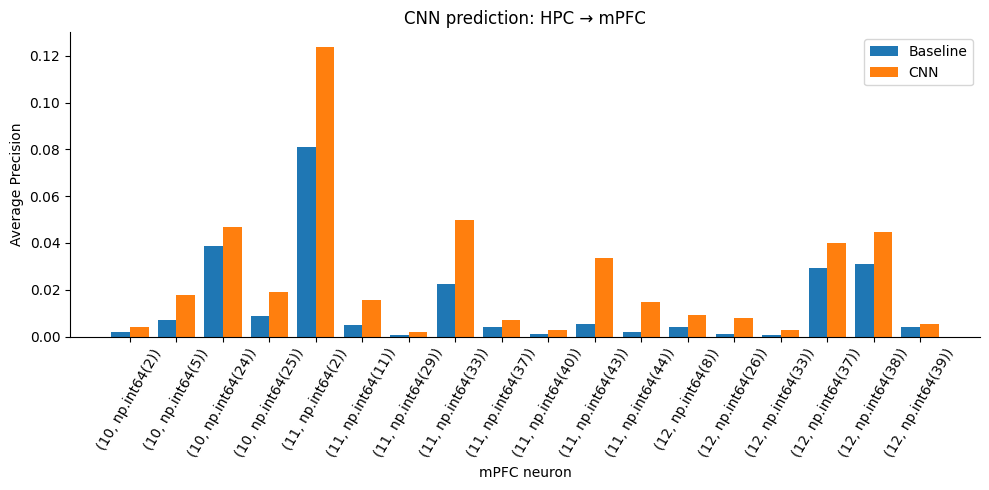

In [113]:
x = np.arange(len(df_cnn))

plt.figure(figsize=(10, 5))

plt.bar(
    x - 0.2,
    df_cnn["baseline_AP"],
    width=0.4,
    label="Baseline"
)

plt.bar(
    x + 0.2,
    df_cnn["mean_AP"],
    width=0.4,
    label="CNN"
)

plt.xticks(
    x,
    df_cnn["unit_id"],
    rotation=60
)

plt.ylabel("Average Precision")
plt.xlabel("mPFC neuron")
plt.title("CNN prediction: HPC → mPFC")

plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [114]:
n_shuffles = 100

shuffle_results = []

for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j].copy()
    real_ap = df_cnn.loc[j, "mean_AP"]

    shuffled_AP = []

    print(f"\n{unit_id}")

    for s in range(n_shuffles):

        # Mélange des labels
        rng = np.random.default_rng(s)
        y_shuffle = rng.permutation(y)

        # Un split stratifié
        train_idx, val_idx = next(
            StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=s
            ).split(X_cnn, y_shuffle)
        )

        tf.keras.backend.clear_session()

        model = build_best_cnn()

        model.fit(
            X_cnn[train_idx],
            y_shuffle[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn[val_idx],
            verbose=0
        ).ravel()

        ap = average_precision_score(
            y_shuffle[val_idx],
            pred
        )

        shuffled_AP.append(ap)

    # p-value empirique
    p_value = (
        np.sum(np.array(shuffled_AP) >= real_ap) + 1
    ) / (n_shuffles + 1)

    shuffle_results.append({
        "unit_id": unit_id,
        "real_AP": real_ap,
        "shuffle_AP": np.mean(shuffled_AP),
        "shuffle_std": np.std(shuffled_AP),
        "p_value": p_value
    })

    print(
        "réel =", round(real_ap, 4),
        "| shuffle =", round(np.mean(shuffled_AP), 4),
        "| p =", round(p_value, 4)
    )


df_shuffle = pd.DataFrame(shuffle_results)

df_shuffle


(10, np.int64(2))


I0000 00:00:1789405383.567103 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4772687__.16
I0000 00:00:1789405385.073194 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4772687__.16
I0000 00:00:1789405399.313442 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4782250__.16
I0000 00:00:1789405400.795780 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4782250__.16
I0000 00:00:1789405415.048616 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4791813__.16
I0000 00:00:1789405416.448052 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4791813__.16
I0000 00:00:1789405431.151332 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4801376__.16
I0000 00:00:1789405432.660267 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

réel = 0.004 | shuffle = 0.0064 | p = 0.3366

(10, np.int64(5))


I0000 00:00:1789407039.957407 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5728987__.16
I0000 00:00:1789407041.457276 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5728987__.16
I0000 00:00:1789407056.597401 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5738550__.16
I0000 00:00:1789407058.104492 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5738550__.16
I0000 00:00:1789407073.402417 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5748113__.16
I0000 00:00:1789407074.854142 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5748113__.16
I0000 00:00:1789407090.342152 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5757676__.16
I0000 00:00:1789407091.845664 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

réel = 0.0177 | shuffle = 0.0136 | p = 0.198

(10, np.int64(24))


I0000 00:00:1789408762.533008 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6685287__.16
I0000 00:00:1789408764.047204 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6685287__.16
I0000 00:00:1789408780.647052 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6694850__.16
I0000 00:00:1789408782.163805 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6694850__.16
I0000 00:00:1789408798.242052 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6704413__.16
I0000 00:00:1789408799.796120 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6704413__.16
I0000 00:00:1789408816.123228 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6713976__.16
I0000 00:00:1789408817.635768 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

réel = 0.0468 | shuffle = 0.0463 | p = 0.3168

(10, np.int64(25))


I0000 00:00:1789410558.211772 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7641587__.16
I0000 00:00:1789410559.663232 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7641587__.16
I0000 00:00:1789410576.394806 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7651150__.16
I0000 00:00:1789410577.864540 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7651150__.16
I0000 00:00:1789410594.633620 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7660713__.16
I0000 00:00:1789410596.181200 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7660713__.16
I0000 00:00:1789410612.803591 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7670276__.16
I0000 00:00:1789410614.371578 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

réel = 0.0191 | shuffle = 0.0184 | p = 0.2772

(11, np.int64(2))


I0000 00:00:1789412413.640089 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8597887__.16
I0000 00:00:1789412415.166652 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8597887__.16
I0000 00:00:1789412433.081248 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8607450__.16
I0000 00:00:1789412434.482807 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8607450__.16
I0000 00:00:1789412452.405773 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8617013__.16
I0000 00:00:1789412453.963471 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8617013__.16
I0000 00:00:1789412471.424587 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8626576__.16
I0000 00:00:1789412472.943461 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

réel = 0.1238 | shuffle = 0.0885 | p = 0.0297

(11, np.int64(11))


I0000 00:00:1789414336.287985 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9554187__.16
I0000 00:00:1789414337.513376 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9554187__.16
I0000 00:00:1789414355.180930 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9563750__.16
I0000 00:00:1789414356.420272 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9563750__.16
I0000 00:00:1789414374.333799 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9573313__.16
I0000 00:00:1789414375.853604 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9573313__.16
I0000 00:00:1789414394.460891 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9582876__.16
I0000 00:00:1789414395.995921 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

réel = 0.0157 | shuffle = 0.0105 | p = 0.1485

(11, np.int64(29))


I0000 00:00:1789416331.827650 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10510487__.16
I0000 00:00:1789416333.376715 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10510487__.16
I0000 00:00:1789416352.459019 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10520050__.16
I0000 00:00:1789416353.988160 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10520050__.16
I0000 00:00:1789416373.150492 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10529613__.16
I0000 00:00:1789416374.633376 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10529613__.16
I0000 00:00:1789416393.592574 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10539176__.16
I0000 00:00:1789416395.096753 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0018 | shuffle = 0.0 | p = 0.0099

(11, np.int64(33))


I0000 00:00:1789418401.411591 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11466787__.16
I0000 00:00:1789418402.846849 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11466787__.16
I0000 00:00:1789418422.868800 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11476350__.16
I0000 00:00:1789418424.410754 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11476350__.16
I0000 00:00:1789418443.556497 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11485913__.16
I0000 00:00:1789418445.061376 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11485913__.16
I0000 00:00:1789418464.202335 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11495476__.16
I0000 00:00:1789418465.697607 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0499 | shuffle = 0.0322 | p = 0.099

(11, np.int64(37))


I0000 00:00:1789420531.866508 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12423087__.16
I0000 00:00:1789420533.379163 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12423087__.16
I0000 00:00:1789420553.865379 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12432650__.16
I0000 00:00:1789420555.402331 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12432650__.16
I0000 00:00:1789420575.727306 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12442213__.16
I0000 00:00:1789420577.233857 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12442213__.16
I0000 00:00:1789420597.001314 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12451776__.16
I0000 00:00:1789420598.532826 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0072 | shuffle = 0.0101 | p = 0.4158

(11, np.int64(40))


I0000 00:00:1789422719.932641 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13379387__.16
I0000 00:00:1789422721.447529 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13379387__.16
I0000 00:00:1789422742.294944 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13388950__.16
I0000 00:00:1789422743.867991 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13388950__.16
I0000 00:00:1789422764.585210 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13398513__.16
I0000 00:00:1789422766.117852 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13398513__.16
I0000 00:00:1789422786.986571 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13408076__.16
I0000 00:00:1789422788.494274 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0029 | shuffle = 0.009 | p = 0.505

(11, np.int64(43))


I0000 00:00:1789424952.815362 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14335687__.16
I0000 00:00:1789424954.254268 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14335687__.16
I0000 00:00:1789424974.947547 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14345250__.16
I0000 00:00:1789424976.469447 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14345250__.16
I0000 00:00:1789424997.654476 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14354813__.16
I0000 00:00:1789424999.197930 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14354813__.16
I0000 00:00:1789425021.410809 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14364376__.16
I0000 00:00:1789425022.953662 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0334 | shuffle = 0.0121 | p = 0.0297

(11, np.int64(44))


I0000 00:00:1789427249.046586 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15291987__.16
I0000 00:00:1789427250.562201 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15291987__.16
I0000 00:00:1789427272.394228 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15301550__.16
I0000 00:00:1789427273.809419 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15301550__.16
I0000 00:00:1789427295.319003 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15311113__.16
I0000 00:00:1789427296.470658 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15311113__.16
I0000 00:00:1789427317.712237 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15320676__.16
I0000 00:00:1789427318.943455 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.015 | shuffle = 0.0098 | p = 0.0693

(12, np.int64(8))


I0000 00:00:1789429598.707188 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16248287__.16
I0000 00:00:1789429600.216270 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16248287__.16
I0000 00:00:1789429622.654875 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16257850__.16
I0000 00:00:1789429624.352159 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16257850__.16
I0000 00:00:1789429647.166262 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16267413__.16
I0000 00:00:1789429648.555463 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16267413__.16
I0000 00:00:1789429670.608720 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16276976__.16
I0000 00:00:1789429671.957608 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0094 | shuffle = 0.011 | p = 0.3861

(12, np.int64(26))


I0000 00:00:1789432021.538323 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17204587__.16
I0000 00:00:1789432023.050977 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17204587__.16
I0000 00:00:1789432046.101991 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17214150__.16
I0000 00:00:1789432047.634255 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17214150__.16
I0000 00:00:1789432070.399476 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17223713__.16
I0000 00:00:1789432071.594574 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17223713__.16
I0000 00:00:1789432094.169197 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17233276__.16
I0000 00:00:1789432095.683555 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.008 | shuffle = 0.0067 | p = 0.1584

(12, np.int64(33))


I0000 00:00:1789434501.448316 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18160887__.16
I0000 00:00:1789434502.733381 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18160887__.16
I0000 00:00:1789434525.976344 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18170450__.16
I0000 00:00:1789434527.266288 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18170450__.16
I0000 00:00:1789434551.048732 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18180013__.16
I0000 00:00:1789434552.552945 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18180013__.16
I0000 00:00:1789434576.060743 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18189576__.16
I0000 00:00:1789434577.592541 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0029 | shuffle = 0.0 | p = 0.0099

(12, np.int64(37))


I0000 00:00:1789437059.147309 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19117187__.16
I0000 00:00:1789437060.595385 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19117187__.16
I0000 00:00:1789437084.769609 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19126750__.16
I0000 00:00:1789437086.332096 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19126750__.16
I0000 00:00:1789437111.434435 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19136313__.16
I0000 00:00:1789437112.963653 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19136313__.16
I0000 00:00:1789437137.694662 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19145876__.16
I0000 00:00:1789437139.210750 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.04 | shuffle = 0.0376 | p = 0.3069

(12, np.int64(38))


I0000 00:00:1789439671.832400 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20073487__.16
I0000 00:00:1789439673.356779 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20073487__.16
I0000 00:00:1789439697.898373 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20083050__.16
I0000 00:00:1789439699.276446 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20083050__.16
I0000 00:00:1789439723.855152 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20092613__.16
I0000 00:00:1789439725.325347 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20092613__.16
I0000 00:00:1789439750.023639 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20102176__.16
I0000 00:00:1789439751.289921 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0449 | shuffle = 0.0388 | p = 0.2475

(12, np.int64(39))


I0000 00:00:1789442330.967691 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21029787__.16
I0000 00:00:1789442332.366465 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21029787__.16
I0000 00:00:1789442358.075364 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21039350__.16
I0000 00:00:1789442359.616384 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21039350__.16
I0000 00:00:1789442385.179507 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21048913__.16
I0000 00:00:1789442386.682165 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21048913__.16
I0000 00:00:1789442412.298775 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21058476__.16
I0000 00:00:1789442413.650508 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0055 | shuffle = 0.01 | p = 0.7129


,unit_id,real_AP,shuffle_AP,shuffle_std,p_value
0,"(10, 2)",0.003971,0.006398,0.014201,0.336634
1,"(10, 5)",0.017734,0.013591,0.008681,0.198020
2,"(10, 24)",0.046778,0.046336,0.012755,0.316832
3,"(10, 25)",0.019106,0.018442,0.019049,0.277228
4,"(11, 2)",0.123802,0.088483,0.013810,0.029703
5,"(11, 11)",0.015677,0.010537,0.010480,0.148515
6,"(11, 29)",0.001846,0.000000,0.000000,0.009901
7,"(11, 33)",0.049920,0.032235,0.016202,0.099010
8,"(11, 37)",0.007237,0.010072,0.009549,0.415842
9,"(11, 40)",0.002934,0.008972,0.021378,0.504950


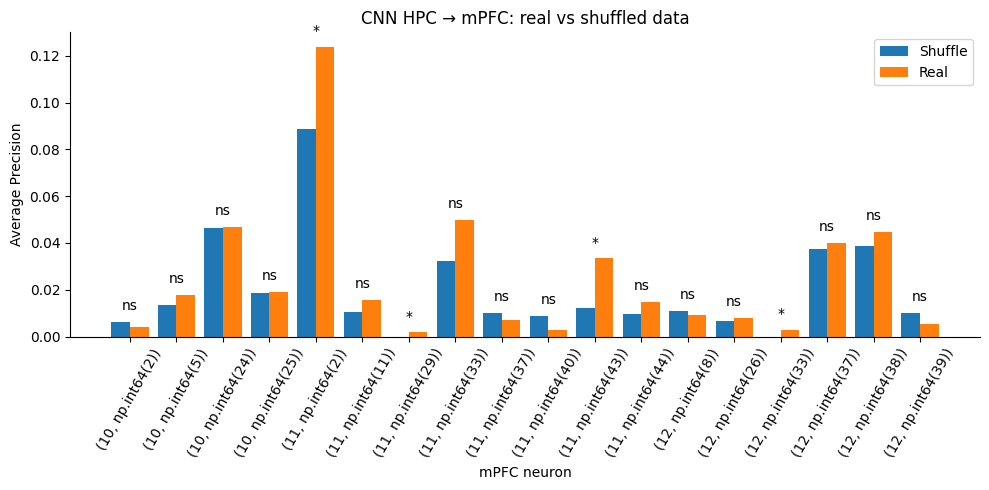

In [115]:
x = np.arange(len(df_shuffle))

plt.figure(figsize=(10, 5))

plt.bar(
    x - 0.2,
    df_shuffle["shuffle_AP"],
    width=0.4,
    label="Shuffle"
)

plt.bar(
    x + 0.2,
    df_shuffle["real_AP"],
    width=0.4,
    label="Real"
)

for i, row in df_shuffle.iterrows():

    y = max(row["real_AP"], row["shuffle_AP"])

    if row["p_value"] < 0.05:
        label = "*"
    else:
        label = "ns"

    plt.text(
        i,
        y + 0.005,
        label,
        ha="center"
    )

plt.xticks(
    x,
    df_shuffle["unit_id"],
    rotation=60
)

plt.ylabel("Average Precision")
plt.xlabel("mPFC neuron")
plt.title("CNN HPC → mPFC: real vs shuffled data")

plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [116]:
bin_edges = np.linspace(-0.200, 0, 21)

re_unit_ids = list(re_units.keys())

X_seq_nr = np.zeros(
    (len(delta_peaks), len(re_unit_ids), 20),
    dtype=np.float32
)

for j, unit_id in enumerate(re_unit_ids):

    spikes = np.asarray(re_units[unit_id])

    for i, delta in enumerate(delta_peaks):

        counts, _ = np.histogram(
            spikes,
            bins=delta + bin_edges
        )

        X_seq_nr[i, j, :] = counts


print("HPC :", X_seq.shape)
print("NR  :", X_seq_nr.shape)

HPC : (3338, 61, 20)
NR  : (3338, 69, 20)


In [117]:
X_seq_hpc_nr = np.concatenate(
    [X_seq, X_seq_nr],
    axis=1
)

X_cnn_hpc_nr = np.transpose(
    X_seq_hpc_nr,
    (0, 2, 1)
)

print("HPC + NR :", X_cnn_hpc_nr.shape)

HPC + NR : (3338, 20, 130)


In [118]:
def build_cnn_hpc_nr():

    model = models.Sequential([
        layers.Input(shape=(20, X_cnn_hpc_nr.shape[2])),

        layers.Conv1D(
            filters=32,
            kernel_size=5,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(8, activation="relu"),

        layers.Dropout(0.2),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0003
        ),
        loss="binary_crossentropy"
    )

    return model

In [119]:
results_hpc_nr = []

for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j]
    n_positive = int(y.sum())
    n_folds = min(5, n_positive)

    scores = []

    print(f"\n{unit_id} - {n_positive} delta-spikes")

    cv_neuron = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42
    )

    for train_idx, val_idx in cv_neuron.split(X_cnn_hpc_nr, y):

        tf.keras.backend.clear_session()

        model = build_cnn_hpc_nr()

        model.fit(
            X_cnn_hpc_nr[train_idx],
            y[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn_hpc_nr[val_idx],
            verbose=0
        ).ravel()

        scores.append(
            average_precision_score(
                y[val_idx],
                pred
            )
        )

    results_hpc_nr.append({
        "unit_id": unit_id,
        "n_delta_spikes": n_positive,
        "baseline_AP": n_positive / len(y),
        "mean_AP": np.mean(scores),
        "std_AP": np.std(scores)
    })

    print("AP moyenne :", round(np.mean(scores), 3))


df_cnn_hpc_nr = pd.DataFrame(results_hpc_nr)

df_cnn_hpc_nr


(10, np.int64(2)) - 6 delta-spikes


I0000 00:00:1789445097.614409 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21986087__.16
I0000 00:00:1789445099.991683 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21986087__.16
I0000 00:00:1789445127.973511 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21995650__.16
I0000 00:00:1789445129.551418 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21995650__.16
I0000 00:00:1789445156.397425 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22005213__.16
I0000 00:00:1789445157.937559 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22005213__.16
I0000 00:00:1789445183.597384 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22014776__.16
I0000 00:00:1789445184.990075 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.004

(10, np.int64(5)) - 24 delta-spikes


I0000 00:00:1789445240.546003 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22033902__.16
I0000 00:00:1789445242.179655 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22033902__.16
I0000 00:00:1789445268.487070 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22043465__.16
I0000 00:00:1789445269.969326 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22043465__.16
I0000 00:00:1789445296.435389 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22053028__.16
I0000 00:00:1789445297.919782 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22053028__.16
I0000 00:00:1789445324.393756 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22062591__.16
I0000 00:00:1789445325.857136 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.018

(10, np.int64(24)) - 129 delta-spikes


I0000 00:00:1789445380.289386 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22081717__.16
I0000 00:00:1789445381.827723 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22081717__.16
I0000 00:00:1789445408.242649 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22091280__.16
I0000 00:00:1789445409.797102 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22091280__.16
I0000 00:00:1789445436.369056 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22100843__.16
I0000 00:00:1789445437.846470 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22100843__.16
I0000 00:00:1789445464.608613 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22110406__.16
I0000 00:00:1789445466.118814 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.038

(10, np.int64(25)) - 29 delta-spikes


I0000 00:00:1789445519.902583 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22129532__.16
I0000 00:00:1789445521.440462 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22129532__.16
I0000 00:00:1789445548.503100 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22139095__.16
I0000 00:00:1789445549.988581 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22139095__.16
I0000 00:00:1789445576.353569 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22148658__.16
I0000 00:00:1789445577.630784 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22148658__.16
I0000 00:00:1789445604.129348 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22158221__.16
I0000 00:00:1789445605.592436 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.009

(11, np.int64(2)) - 270 delta-spikes


I0000 00:00:1789445661.200760 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22177347__.16
I0000 00:00:1789445662.745225 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22177347__.16
I0000 00:00:1789445689.361939 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22186910__.16
I0000 00:00:1789445690.929553 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22186910__.16
I0000 00:00:1789445717.555300 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22196473__.16
I0000 00:00:1789445718.966129 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22196473__.16
I0000 00:00:1789445745.072939 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22206036__.16
I0000 00:00:1789445746.620293 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.11

(11, np.int64(11)) - 16 delta-spikes


I0000 00:00:1789445801.344043 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22225162__.16
I0000 00:00:1789445802.776507 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22225162__.16
I0000 00:00:1789445829.118516 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22234725__.16
I0000 00:00:1789445830.323090 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22234725__.16
I0000 00:00:1789445856.230843 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22244288__.16
I0000 00:00:1789445857.777796 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22244288__.16
I0000 00:00:1789445884.544960 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22253851__.16
I0000 00:00:1789445886.023031 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.043

(11, np.int64(29)) - 2 delta-spikes


I0000 00:00:1789445940.485797 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22272977__.16
I0000 00:00:1789445941.748592 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22272977__.16
I0000 00:00:1789445967.797250 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22279974__.16
I0000 00:00:1789445969.300106 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22279974__.16


AP moyenne : 0.001

(11, np.int64(33)) - 75 delta-spikes


I0000 00:00:1789445994.558966 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22286971__.16
I0000 00:00:1789445996.016383 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22286971__.16
I0000 00:00:1789446022.715143 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22296534__.16
I0000 00:00:1789446024.070943 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22296534__.16
I0000 00:00:1789446051.175403 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22306097__.16
I0000 00:00:1789446052.735711 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22306097__.16
I0000 00:00:1789446079.654181 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22315660__.16
I0000 00:00:1789446081.206851 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.06

(11, np.int64(37)) - 14 delta-spikes


I0000 00:00:1789446135.877926 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22334786__.16
I0000 00:00:1789446137.433727 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22334786__.16
I0000 00:00:1789446164.502779 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22344349__.16
I0000 00:00:1789446166.067467 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22344349__.16
I0000 00:00:1789446192.967354 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22353912__.16
I0000 00:00:1789446194.549453 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22353912__.16
I0000 00:00:1789446221.789714 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22363475__.16
I0000 00:00:1789446223.349353 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.007

(11, np.int64(40)) - 3 delta-spikes


I0000 00:00:1789446277.520150 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22382601__.16
I0000 00:00:1789446279.046982 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22382601__.16
I0000 00:00:1789446306.242674 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22391002__.16
I0000 00:00:1789446307.587196 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22391002__.16
I0000 00:00:1789446334.005201 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22399403__.16
I0000 00:00:1789446335.496017 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22399403__.16


AP moyenne : 0.004

(11, np.int64(43)) - 18 delta-spikes


I0000 00:00:1789446362.807399 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22407804__.16
I0000 00:00:1789446364.338682 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22407804__.16
I0000 00:00:1789446391.327701 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22417367__.16
I0000 00:00:1789446392.783428 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22417367__.16
I0000 00:00:1789446419.542625 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22426930__.16
I0000 00:00:1789446421.016865 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22426930__.16
I0000 00:00:1789446447.782248 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22436493__.16
I0000 00:00:1789446449.141688 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.023

(11, np.int64(44)) - 7 delta-spikes


I0000 00:00:1789446503.693340 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22455619__.16
I0000 00:00:1789446505.210563 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22455619__.16
I0000 00:00:1789446532.415118 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22465182__.16
I0000 00:00:1789446533.994573 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22465182__.16
I0000 00:00:1789446560.339556 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22474745__.16
I0000 00:00:1789446561.870131 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22474745__.16
I0000 00:00:1789446588.422056 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22484308__.16
I0000 00:00:1789446589.969452 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.021

(12, np.int64(8)) - 14 delta-spikes


I0000 00:00:1789446644.071782 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22503434__.16
I0000 00:00:1789446645.318594 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22503434__.16
I0000 00:00:1789446671.858165 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22512997__.16
I0000 00:00:1789446673.370584 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22512997__.16
I0000 00:00:1789446700.205370 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22522560__.16
I0000 00:00:1789446701.759480 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22522560__.16
I0000 00:00:1789446728.620105 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22532123__.16
I0000 00:00:1789446730.031804 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.006

(12, np.int64(26)) - 3 delta-spikes


I0000 00:00:1789446784.834118 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22551249__.16
I0000 00:00:1789446786.090972 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22551249__.16
I0000 00:00:1789446812.086315 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22559650__.16
I0000 00:00:1789446813.384347 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22559650__.16
I0000 00:00:1789446839.527959 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22568051__.16
I0000 00:00:1789446840.951866 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22568051__.16


AP moyenne : 0.002

(12, np.int64(33)) - 2 delta-spikes


I0000 00:00:1789446866.804399 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22576452__.16
I0000 00:00:1789446868.288320 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22576452__.16
I0000 00:00:1789446893.852068 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22583449__.16
I0000 00:00:1789446895.334502 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22583449__.16


AP moyenne : 0.001

(12, np.int64(37)) - 98 delta-spikes


I0000 00:00:1789446921.346649 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22590446__.16
I0000 00:00:1789446922.647600 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22590446__.16
I0000 00:00:1789446950.104533 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22600009__.16
I0000 00:00:1789446951.650718 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22600009__.16
I0000 00:00:1789446978.426088 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22609572__.16
I0000 00:00:1789446979.607521 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22609572__.16
I0000 00:00:1789447005.983756 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22619135__.16
I0000 00:00:1789447007.446746 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.043

(12, np.int64(38)) - 103 delta-spikes


I0000 00:00:1789447061.590484 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22638261__.16
I0000 00:00:1789447062.973696 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22638261__.16
I0000 00:00:1789447089.399840 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22647824__.16
I0000 00:00:1789447090.924898 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22647824__.16
I0000 00:00:1789447117.540820 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22657387__.16
I0000 00:00:1789447119.100451 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22657387__.16
I0000 00:00:1789447145.561680 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22666950__.16
I0000 00:00:1789447147.108292 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.033

(12, np.int64(39)) - 14 delta-spikes


I0000 00:00:1789447201.853231 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22686076__.16
I0000 00:00:1789447203.388178 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22686076__.16
I0000 00:00:1789447229.817884 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22695639__.16
I0000 00:00:1789447231.051366 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22695639__.16
I0000 00:00:1789447257.719040 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22705202__.16
I0000 00:00:1789447259.262408 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22705202__.16
I0000 00:00:1789447286.570751 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22714765__.16
I0000 00:00:1789447288.050327 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference

AP moyenne : 0.005


,unit_id,n_delta_spikes,baseline_AP,mean_AP,std_AP
0,"(10, 2)",6,0.001797,0.003568,0.001297
1,"(10, 5)",24,0.007190,0.017847,0.016022
2,"(10, 24)",129,0.038646,0.038254,0.003446
3,"(10, 25)",29,0.008688,0.009010,0.002662
4,"(11, 2)",270,0.080887,0.110049,0.027127
5,"(11, 11)",16,0.004793,0.042695,0.064215
6,"(11, 29)",2,0.000599,0.001363,0.000524
7,"(11, 33)",75,0.022469,0.059668,0.024518
8,"(11, 37)",14,0.004194,0.007112,0.004912
9,"(11, 40)",3,0.000899,0.004069,0.003461


HPC moyen      : 0.024885322849488595
HPC + NR moyen : 0.02372371625387782
p = 0.2121429443359375


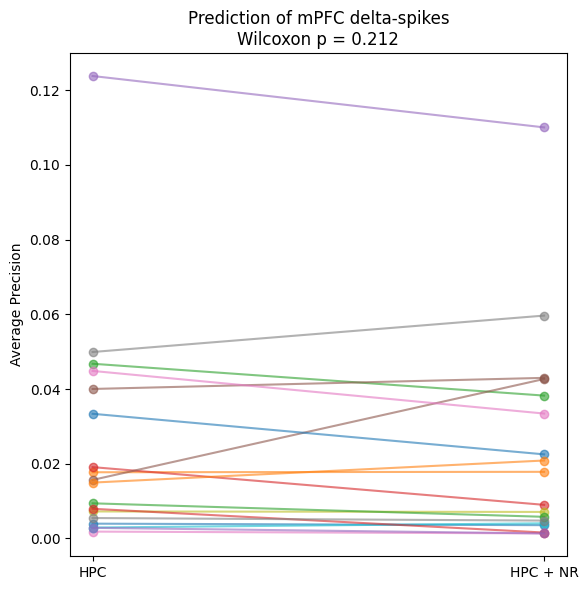

In [120]:
hpc = df_cnn["mean_AP"].values
hpc_nr = df_cnn_hpc_nr["mean_AP"].values

stat, p = wilcoxon(hpc, hpc_nr)

print("HPC moyen      :", np.mean(hpc))
print("HPC + NR moyen :", np.mean(hpc_nr))
print("p =", p)

plt.figure(figsize=(6, 6))

for i in range(len(hpc)):
    plt.plot(
        [0, 1],
        [hpc[i], hpc_nr[i]],
        marker="o",
        alpha=0.6
    )

plt.xticks(
    [0, 1],
    ["HPC", "HPC + NR"]
)

plt.ylabel("Average Precision")
plt.title(
    f"Prediction of mPFC delta-spikes\nWilcoxon p = {p:.3f}"
)

plt.tight_layout()
plt.show()

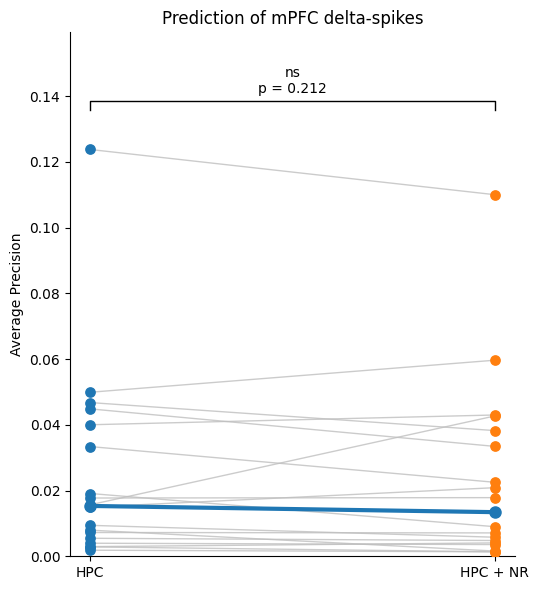

In [121]:
hpc = df_cnn["mean_AP"].values
hpc_nr = df_cnn_hpc_nr["mean_AP"].values

stat, p = wilcoxon(hpc, hpc_nr)

fig, ax = plt.subplots(figsize=(5.5, 6))

for i in range(len(hpc)):
    ax.plot(
        [0, 1],
        [hpc[i], hpc_nr[i]],
        color="0.75",
        linewidth=1,
        alpha=0.8
    )

ax.scatter(
    np.zeros(len(hpc)),
    hpc,
    s=45,
    zorder=3
)

ax.scatter(
    np.ones(len(hpc)),
    hpc_nr,
    s=45,
    zorder=3
)

med_hpc = np.median(hpc)
med_hpc_nr = np.median(hpc_nr)

ax.plot(
    [0, 1],
    [med_hpc, med_hpc_nr],
    linewidth=3,
    marker="o",
    markersize=8,
    zorder=4
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "HPC",
    "HPC + NR"
])

ax.set_ylabel("Average Precision")
ax.set_title("Prediction of mPFC delta-spikes")


y_max = max(hpc.max(), hpc_nr.max())
y_sig = y_max * 1.12

ax.plot(
    [0, 0, 1, 1],
    [y_sig*0.98, y_sig, y_sig, y_sig*0.98],
    color="black",
    linewidth=1
)

ax.text(
    0.5,
    y_sig * 1.01,
    f"ns\np = {p:.3f}",
    ha="center",
    va="bottom"
)

ax.set_ylim(
    0,
    y_sig * 1.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [122]:
n_shuffles = 100

shuffle_results_hpc_nr = []

for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j].copy()
    real_ap = df_cnn_hpc_nr.loc[j, "mean_AP"]

    shuffled_AP = []

    print(f"\n{unit_id}")

    for s in range(n_shuffles):

        rng = np.random.default_rng(s)
        y_shuffle = rng.permutation(y)

        train_idx, val_idx = next(
            StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=s
            ).split(X_cnn_hpc_nr, y_shuffle)
        )

        tf.keras.backend.clear_session()

        model = build_cnn_hpc_nr()

        model.fit(
            X_cnn_hpc_nr[train_idx],
            y_shuffle[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn_hpc_nr[val_idx],
            verbose=0
        ).ravel()

        ap = average_precision_score(
            y_shuffle[val_idx],
            pred
        )

        shuffled_AP.append(ap)

    p_value = (
        np.sum(np.array(shuffled_AP) >= real_ap) + 1
    ) / (n_shuffles + 1)

    shuffle_results_hpc_nr.append({
        "unit_id": unit_id,
        "real_AP": real_ap,
        "shuffle_AP": np.mean(shuffled_AP),
        "shuffle_std": np.std(shuffled_AP),
        "p_value": p_value
    })
    print(
        "réel =", round(real_ap, 4),
        "| shuffle =", round(np.mean(shuffled_AP), 4),
        "| p =", round(p_value, 4)
    )


df_shuffle_hpc_nr = pd.DataFrame(
    shuffle_results_hpc_nr
)

df_shuffle_hpc_nr


(10, np.int64(2))


I0000 00:00:1789447343.795989 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22733891__.16
I0000 00:00:1789447345.376967 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22733891__.16
I0000 00:00:1789447372.770711 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22743454__.16
I0000 00:00:1789447374.327855 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22743454__.16
I0000 00:00:1789447400.798572 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22753017__.16
I0000 00:00:1789447402.274689 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22753017__.16
I0000 00:00:1789447429.300000 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22762580__.16
I0000 00:00:1789447430.869855 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0036 | shuffle = 0.0055 | p = 0.396

(10, np.int64(5))


I0000 00:00:1789450216.445048 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23690191__.16
I0000 00:00:1789450217.906255 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23690191__.16
I0000 00:00:1789450245.205604 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23699754__.16
I0000 00:00:1789450246.450624 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23699754__.16
I0000 00:00:1789450274.557676 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23709317__.16
I0000 00:00:1789450275.722356 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23709317__.16
I0000 00:00:1789450303.863568 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23718880__.16
I0000 00:00:1789450305.405876 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0178 | shuffle = 0.0162 | p = 0.2772

(10, np.int64(24))


I0000 00:00:1789453147.955311 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24646491__.16
I0000 00:00:1789453149.360792 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24646491__.16
I0000 00:00:1789453177.208680 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24656054__.16
I0000 00:00:1789453178.764556 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24656054__.16
I0000 00:00:1789453206.991687 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24665617__.16
I0000 00:00:1789453208.539819 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24665617__.16
I0000 00:00:1789453236.994297 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24675180__.16
I0000 00:00:1789453238.529123 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0383 | shuffle = 0.0489 | p = 0.8119

(10, np.int64(25))


I0000 00:00:1789456127.454061 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25602791__.16
I0000 00:00:1789456128.950192 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25602791__.16
I0000 00:00:1789456157.156868 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25612354__.16
I0000 00:00:1789456158.734808 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25612354__.16
I0000 00:00:1789456187.172507 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25621917__.16
I0000 00:00:1789456188.654124 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25621917__.16
I0000 00:00:1789456217.058785 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25631480__.16
I0000 00:00:1789456218.617093 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.009 | shuffle = 0.0165 | p = 0.7723

(11, np.int64(2))


I0000 00:00:1789459193.537962 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26559091__.16
I0000 00:00:1789459195.116879 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26559091__.16
I0000 00:00:1789459224.668820 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26568654__.16
I0000 00:00:1789459226.109438 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26568654__.16
I0000 00:00:1789459255.344185 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26578217__.16
I0000 00:00:1789459256.889287 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26578217__.16
I0000 00:00:1789459286.410224 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26587780__.16
I0000 00:00:1789459287.980486 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.11 | shuffle = 0.0896 | p = 0.0792

(11, np.int64(11))


I0000 00:00:1789462327.181299 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27515391__.16
I0000 00:00:1789462328.751730 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27515391__.16
I0000 00:00:1789462358.353877 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27524954__.16
I0000 00:00:1789462359.867650 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27524954__.16
I0000 00:00:1789462390.281937 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27534517__.16
I0000 00:00:1789462391.608783 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27534517__.16
I0000 00:00:1789462422.279814 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27544080__.16
I0000 00:00:1789462423.852849 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0427 | shuffle = 0.014 | p = 0.0594

(11, np.int64(29))


I0000 00:00:1789465709.538304 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28471691__.16
I0000 00:00:1789465710.873284 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28471691__.16
I0000 00:00:1789465742.985898 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28481254__.16
I0000 00:00:1789465744.531866 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28481254__.16
I0000 00:00:1789465776.602965 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28490817__.16
I0000 00:00:1789465778.247944 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28490817__.16
I0000 00:00:1789465811.140788 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28500380__.16
I0000 00:00:1789465812.828008 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0014 | shuffle = 0.0 | p = 0.0099

(11, np.int64(33))


I0000 00:00:1789469068.406886 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29427991__.16
I0000 00:00:1789469069.951689 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29427991__.16
I0000 00:00:1789469099.924361 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29437554__.16
I0000 00:00:1789469101.409899 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29437554__.16
I0000 00:00:1789469131.263774 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29447117__.16
I0000 00:00:1789469132.775412 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29447117__.16
I0000 00:00:1789469162.825114 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29456680__.16
I0000 00:00:1789469164.395110 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0597 | shuffle = 0.0287 | p = 0.0297

(11, np.int64(37))


I0000 00:00:1789472703.784209 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30384291__.16
I0000 00:00:1789472705.330191 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30384291__.16
I0000 00:00:1789472739.423574 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30393854__.16
I0000 00:00:1789472740.646274 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30393854__.16
I0000 00:00:1789472775.290945 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30403417__.16
I0000 00:00:1789472776.495099 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30403417__.16
I0000 00:00:1789472811.738475 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30412980__.16
I0000 00:00:1789472813.339665 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0071 | shuffle = 0.0115 | p = 0.3762

(11, np.int64(40))


I0000 00:00:1789476288.124400 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31340591__.16
I0000 00:00:1789476289.396870 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31340591__.16
I0000 00:00:1789476323.906005 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31350154__.16
I0000 00:00:1789476325.541138 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31350154__.16
I0000 00:00:1789476360.448250 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31359717__.16
I0000 00:00:1789476362.045411 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31359717__.16
I0000 00:00:1789476396.820544 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31369280__.16
I0000 00:00:1789476398.149320 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0041 | shuffle = 0.0071 | p = 0.3663

(11, np.int64(43))


I0000 00:00:1789479983.083344 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32296891__.16
I0000 00:00:1789479984.677539 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32296891__.16
I0000 00:00:1789480020.325402 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32306454__.16
I0000 00:00:1789480021.764333 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32306454__.16
I0000 00:00:1789480057.319075 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32316017__.16
I0000 00:00:1789480058.883224 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32316017__.16
I0000 00:00:1789480094.896037 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32325580__.16
I0000 00:00:1789480096.533186 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0225 | shuffle = 0.015 | p = 0.1584

(11, np.int64(44))


I0000 00:00:1789483599.170959 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33253191__.16
I0000 00:00:1789483600.811526 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33253191__.16
I0000 00:00:1789483635.309162 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33262754__.16
I0000 00:00:1789483636.524050 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33262754__.16
I0000 00:00:1789483669.926340 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33272317__.16
I0000 00:00:1789483671.488198 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33272317__.16
I0000 00:00:1789483705.578093 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33281880__.16
I0000 00:00:1789483707.065911 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0209 | shuffle = 0.0072 | p = 0.0693

(12, np.int64(8))


I0000 00:00:1789487287.963774 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34209491__.16
I0000 00:00:1789487289.562719 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34209491__.16
I0000 00:00:1789487324.036354 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34219054__.16
I0000 00:00:1789487325.648615 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34219054__.16
I0000 00:00:1789487362.521420 1752064 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34228617__.16
I0000 00:00:1789487363.793856 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34228617__.16
I0000 00:00:1789487397.642672 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34238180__.16
I0000 00:00:1789487399.193565 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0058 | shuffle = 0.0138 | p = 0.6337

(12, np.int64(26))


I0000 00:00:1789491037.786083 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35165791__.16
I0000 00:00:1789491039.333611 1752057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35165791__.16
I0000 00:00:1789491075.483842 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35175354__.16
I0000 00:00:1789491076.757022 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35175354__.16
I0000 00:00:1789491113.222017 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35184917__.16
I0000 00:00:1789491114.542642 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35184917__.16
I0000 00:00:1789491150.568288 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35194480__.16
I0000 00:00:1789491152.345191 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0016 | shuffle = 0.0136 | p = 0.9406

(12, np.int64(33))


I0000 00:00:1789495015.107848 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36122091__.16
I0000 00:00:1789495016.360626 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36122091__.16
I0000 00:00:1789495058.915540 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36131654__.16
I0000 00:00:1789495060.331384 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36131654__.16
I0000 00:00:1789495097.200982 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36141217__.16
I0000 00:00:1789495098.809379 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36141217__.16
I0000 00:00:1789495135.870671 1752065 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36150780__.16
I0000 00:00:1789495137.341985 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0014 | shuffle = 0.0 | p = 0.0099

(12, np.int64(37))


I0000 00:00:1789498683.951112 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37078391__.16
I0000 00:00:1789498685.520005 1752057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37078391__.16
I0000 00:00:1789498720.019228 1752057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37087954__.16
I0000 00:00:1789498721.571416 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37087954__.16
I0000 00:00:1789498755.965448 1752057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37097517__.16
I0000 00:00:1789498757.544940 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37097517__.16
I0000 00:00:1789498792.026646 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37107080__.16
I0000 00:00:1789498793.601214 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.043 | shuffle = 0.0374 | p = 0.198

(12, np.int64(38))


I0000 00:00:1789502287.328550 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38034691__.16
I0000 00:00:1789502288.820413 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38034691__.16
I0000 00:00:1789502323.006019 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38044254__.16
I0000 00:00:1789502324.596515 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38044254__.16
I0000 00:00:1789502358.758973 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38053817__.16
I0000 00:00:1789502360.265845 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38053817__.16
I0000 00:00:1789502394.966048 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38063380__.16
I0000 00:00:1789502396.474753 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0334 | shuffle = 0.0405 | p = 0.6634

(12, np.int64(39))


I0000 00:00:1789505973.105228 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38990991__.16
I0000 00:00:1789505974.711068 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38990991__.16
I0000 00:00:1789506009.132971 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39000554__.16
I0000 00:00:1789506010.391713 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39000554__.16
I0000 00:00:1789506044.737234 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39010117__.16
I0000 00:00:1789506046.253545 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39010117__.16
I0000 00:00:1789506081.688802 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39019680__.16
I0000 00:00:1789506083.246394 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference

réel = 0.0048 | shuffle = 0.0144 | p = 0.7228


,unit_id,real_AP,shuffle_AP,shuffle_std,p_value
0,"(10, 2)",0.003568,0.005548,0.013027,0.396040
1,"(10, 5)",0.017847,0.016226,0.014407,0.277228
2,"(10, 24)",0.038254,0.048919,0.015939,0.811881
3,"(10, 25)",0.009010,0.016473,0.013074,0.772277
4,"(11, 2)",0.110049,0.089559,0.013873,0.079208
5,"(11, 11)",0.042695,0.013956,0.025773,0.059406
6,"(11, 29)",0.001363,0.000000,0.000000,0.009901
7,"(11, 33)",0.059668,0.028723,0.012293,0.029703
8,"(11, 37)",0.007112,0.011540,0.023710,0.376238
9,"(11, 40)",0.004069,0.007118,0.020153,0.366337


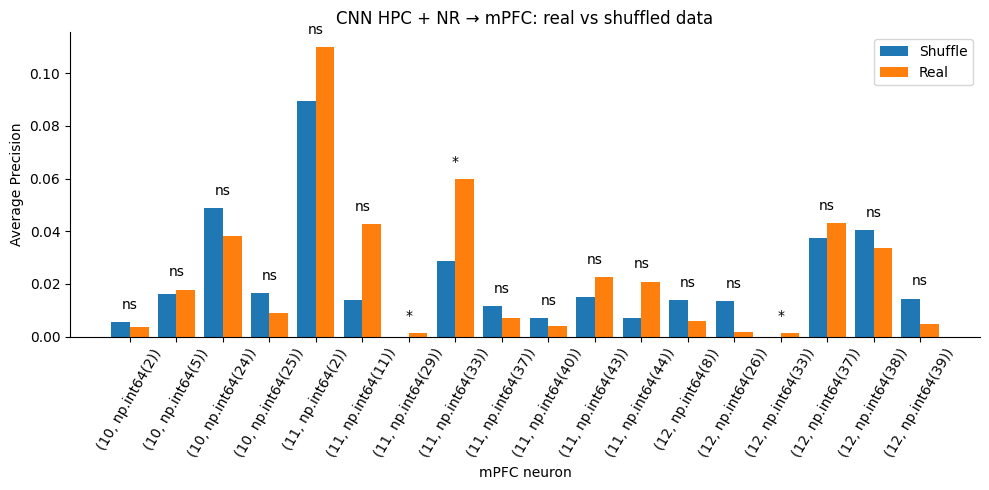

In [123]:
x = np.arange(len(df_shuffle_hpc_nr))

plt.figure(figsize=(10, 5))

plt.bar(
    x - 0.2,
    df_shuffle_hpc_nr["shuffle_AP"],
    width=0.4,
    label="Shuffle"
)

plt.bar(
    x + 0.2,
    df_shuffle_hpc_nr["real_AP"],
    width=0.4,
    label="Real"
)

for i, row in df_shuffle_hpc_nr.iterrows():

    y = max(row["real_AP"], row["shuffle_AP"])

    if row["p_value"] < 0.05:
        label = "*"
    else:
        label = "ns"

    plt.text(
        i,
        y + 0.005,
        label,
        ha="center"
    )

plt.xticks(
    x,
    df_shuffle_hpc_nr["unit_id"],
    rotation=60
)

plt.ylabel("Average Precision")
plt.xlabel("mPFC neuron")
plt.title("CNN HPC + NR → mPFC: real vs shuffled data")

plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [124]:
channels_nr = list(range(0, 64))
channels_hpc = list(range(96, 128))

channels = channels_nr + channels_hpc

print("NR :", len(channels_nr), "canaux")
print("HPC :", len(channels_hpc), "canaux")
print("Total :", len(channels), "canaux")

NR : 64 canaux
HPC : 32 canaux
Total : 96 canaux


In [125]:
selected_units = [
    (11, 2),
    (11, 33),
    (11, 43)
]

for unit in selected_units:

    j = mpfc_units_ids.index(unit)

    y = Y_mpfc[:, j]

    idx_pos = np.where(y == 1)[0]

    print(
        unit,
        "->",
        len(idx_pos),
        "delta-spikes"
    )

(11, 2) -> 270 delta-spikes
(11, 33) -> 75 delta-spikes
(11, 43) -> 18 delta-spikes


In [126]:
rng = np.random.default_rng(42)

datasets = {}

for unit in selected_units:

    j = mpfc_units_ids.index(unit)
    y = Y_mpfc[:, j]

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]

    # même nombre de négatifs que de positifs
    idx_neg_selected = rng.choice(
        idx_neg,
        size=len(idx_pos),
        replace=False
    )

    idx_selected = np.concatenate([
        idx_pos,
        idx_neg_selected
    ])

    # labels correspondants
    y_selected = y[idx_selected]

    # delta peaks correspondants
    peaks_selected = delta_peaks[idx_selected]

    datasets[unit] = {
        "indices": idx_selected,
        "peaks": peaks_selected,
        "y": y_selected
    }

    print(
        unit,
        ":",
        len(idx_pos), "positifs +",
        len(idx_neg_selected), "négatifs =",
        len(idx_selected), "événements"
    )

(11, 2) : 270 positifs + 270 négatifs = 540 événements
(11, 33) : 75 positifs + 75 négatifs = 150 événements
(11, 43) : 18 positifs + 18 négatifs = 36 événements


In [127]:
window = np.array([-0.5, 0.5])

for unit in selected_units:

    peaks = datasets[unit]["peaks"]

    intervals = peaks[:, None] + window

    datasets[unit]["intervals"] = intervals

    print(
        unit,
        "->",
        intervals.shape
    )

(11, 2) -> (540, 2)
(11, 33) -> (150, 2)
(11, 43) -> (36, 2)


In [128]:
xml_file = next(chemin.glob("*.xml"))

In [134]:
import importlib
import fmatoolbox as fmb

importlib.reload(fmb.data)

print("loadWideband disponible :", hasattr(fmb.data, "loadWideband"))

loadWideband disponible : True


In [135]:
wideband_data = {}

for unit in selected_units:

    print("Chargement de", unit)

    data_unit, t_unit = fmb.data.loadWideband(
        xml_file,
        channels=channels,
        intervals=datasets[unit]["intervals"],
        cat=False,
        trim=True
    )

    wideband_data[unit] = {
        "data": data_unit,
        "t": t_unit,
        "y": datasets[unit]["y"]
    }

    print(
        unit,
        "->",
        len(data_unit),
        "fenêtres, shape :",
        data_unit[0].shape
    )

Chargement de (11, 2)
(11, 2) -> 540 fenêtres, shape : (20000, 96)
Chargement de (11, 33)
(11, 33) -> 150 fenêtres, shape : (20000, 96)
Chargement de (11, 43)
(11, 43) -> 36 fenêtres, shape : (20000, 96)


In [136]:
for unit in selected_units:
    X = np.array(wideband_data[unit]["data"])
    y = np.array(wideband_data[unit]["y"])

    print("\n", unit)
    print("X :", X.shape)
    print("y :", y.shape)
    print("positifs :", y.sum())
    print("négatifs :", len(y) - y.sum())
    print("dtype :", X.dtype)


 (11, 2)
X : (540, 20000, 96)
y : (540,)
positifs : 270
négatifs : 270
dtype : int16

 (11, 33)
X : (150, 20000, 96)
y : (150,)
positifs : 75
négatifs : 75
dtype : int16

 (11, 43)
X : (36, 20000, 96)
y : (36,)
positifs : 18
négatifs : 18
dtype : int16


In [137]:
cnn_data = {}

for unit in selected_units:

    X = np.array(
        wideband_data[unit]["data"],
        dtype=np.float32
    )

    y = np.array(
        wideband_data[unit]["y"],
        dtype=np.float32
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Normalisation calculée UNIQUEMENT sur le train
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True)

    X_train = (X_train - mean) / (std + 1e-8)
    X_test = (X_test - mean) / (std + 1e-8)

    cnn_data[unit] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(
        unit,
        "train :", X_train.shape,
        "test :", X_test.shape
    )

(11, 2) train : (432, 20000, 96) test : (108, 20000, 96)
(11, 33) train : (120, 20000, 96) test : (30, 20000, 96)
(11, 43) train : (28, 20000, 96) test : (8, 20000, 96)


In [140]:
for unit in selected_units:
    t = wideband_data[unit]["t"]

    # Temps central de chaque fenêtre
    centres = np.array([
        np.asarray(t_event)[len(t_event) // 2]
        for t_event in t
    ])

    # Tri chronologique
    centres_sorted = np.sort(centres)

    # Écart entre événements successifs
    gaps = np.diff(centres_sorted)

    print("\nUnité", unit)
    print("Écart minimum :", gaps.min(), "s")
    print("Nombre d'écarts < 1 s :", np.sum(gaps < 1))
    print("Nombre d'écarts < 0.5 s :", np.sum(gaps < 0.5))


Unité (11, 2)
Écart minimum : 0.23919999999998254 s
Nombre d'écarts < 1 s : 17
Nombre d'écarts < 0.5 s : 3

Unité (11, 33)
Écart minimum : 0.18080000000009022 s
Nombre d'écarts < 1 s : 3
Nombre d'écarts < 0.5 s : 1

Unité (11, 43)
Écart minimum : 11.952799999999115 s
Nombre d'écarts < 1 s : 0
Nombre d'écarts < 0.5 s : 0


In [142]:
print("build_model" in globals())
print("build_cnn" in globals())

False
True


In [143]:
def build_wideband_cnn():

    model = Sequential([
        tf.keras.Input(shape=(20000, 96)),

        Conv1D(32, kernel_size=21, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=11, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(128, kernel_size=7, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        GlobalAveragePooling1D(),

        Dense(32, activation="relu"),
        Dropout(0.4),

        Dense(1, activation="sigmoid")
    ])

    return model

In [144]:
wideband_model = build_wideband_cnn()
wideband_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 20000, 32)      │        64,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20000, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10000, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10000, 64)      │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10000, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 5000, 128)      │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 2500, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,665 (584.63 KB)

 Trainable params: 149,217 (582.88 KB)

 Non-trainable params: 448 (1.75 KB)

In [145]:
wideband_models = {}
wideband_histories = {}
wideband_results = {}

for unit in selected_units:

    print("\n==============================")
    print("CNN wideband - neurone", unit)
    print("==============================")

    X_train = cnn_data[unit]["X_train"]
    y_train = cnn_data[unit]["y_train"]

    X_test = cnn_data[unit]["X_test"]
    y_test = cnn_data[unit]["y_test"]

    # Nouveau CNN indépendant pour ce neurone
    model = build_wideband_cnn()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                curve="PR",
                name="auc_pr"
            )
        ]
    )

    # Entraînement
    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=8,
        validation_split=0.2,
        verbose=1
    )

    # Prédictions sur le TEST jamais utilisé pour l'entraînement
    y_pred = model.predict(
        X_test,
        batch_size=8
    ).ravel()

    # Average Precision
    ap = average_precision_score(
        y_test,
        y_pred
    )

    wideband_models[unit] = model
    wideband_histories[unit] = history
    wideband_results[unit] = {
        "average_precision": ap,
        "y_test": y_test,
        "y_pred": y_pred
    }

    print(
        "\nAverage Precision TEST",
        unit,
        ":",
        round(ap, 4)
    )


CNN wideband - neurone (11, 2)
Epoch 1/30


I0000 00:00:1789562643.456435 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39949886__.58


44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 333ms/step - auc_pr: 0.4697 - loss: 0.7404 - val_auc_pr: 0.4287 - val_loss: 0.7008
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - auc_pr: 0.5089 - loss: 0.7101 - val_auc_pr: 0.4480 - val_loss: 0.7083
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc_pr: 0.5198 - loss: 0.7078 - val_auc_pr: 0.4762 - val_loss: 0.6998
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - auc_pr: 0.5565 - loss: 0.6908 - val_auc_pr: 0.4935 - val_loss: 0.6972
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - auc_pr: 0.6007 - loss: 0.6919 - val_auc_pr: 0.4943 - val_loss: 0.7137
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - auc_pr: 0.5765 - loss: 0.6843 - val_auc_pr: 0.5087 - val_loss: 0.7016
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc_pr: 0.5970 - loss: 0.6844 - val_auc_pr: 0.4720 - val_loss: 0.7295
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - auc_pr: 0.5888 - loss: 0.6835 - val_auc_pr: 0.5097 - val_loss: 0.7049
Epoch 9/30
44/44 ━━━━━━━━

I0000 00:00:1789562736.239648 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39967615__.53


12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 253ms/step - auc_pr: 0.4528 - loss: 0.7247 - val_auc_pr: 0.7458 - val_loss: 0.6311
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - auc_pr: 0.5752 - loss: 0.6724 - val_auc_pr: 0.8007 - val_loss: 0.6369
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - auc_pr: 0.5932 - loss: 0.6537 - val_auc_pr: 0.7937 - val_loss: 0.6299
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - auc_pr: 0.6086 - loss: 0.6643 - val_auc_pr: 0.7509 - val_loss: 0.6395
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - auc_pr: 0.6355 - loss: 0.6410 - val_auc_pr: 0.8151 - val_loss: 0.6337
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - auc_pr: 0.6165 - loss: 0.6439 - val_auc_pr: 0.8446 - val_loss: 0.6043
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - auc_pr: 0.7057 - loss: 0.6175 - val_auc_pr: 0.7836 - val_loss: 0.6222
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - auc_pr: 0.5675 - loss: 0.6634 - val_auc_pr: 0.7685 - val_loss: 0.6404
Epoch 9/30
12/12 ━━━━━━━━

I0000 00:00:1789562772.633711 1752057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39980630__.58


1/3 ━━━━━━━━━━━━━━━━━━━━ 24s 12s/step - auc_pr: 0.4262 - loss: 0.7111

I0000 00:00:1789562776.770143 1752057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39980630__.58


3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - auc_pr: 0.6271 - loss: 0.6431 - val_auc_pr: 0.9088 - val_loss: 0.6174
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - auc_pr: 0.5582 - loss: 0.6569 - val_auc_pr: 0.8369 - val_loss: 0.7701
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - auc_pr: 0.6918 - loss: 0.5884 - val_auc_pr: 0.8369 - val_loss: 1.0153
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - auc_pr: 0.9284 - loss: 0.4707 - val_auc_pr: 0.8705 - val_loss: 1.0736
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - auc_pr: 0.9123 - loss: 0.4681 - val_auc_pr: 0.8705 - val_loss: 1.5143
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - auc_pr: 0.9489 - loss: 0.4378 - val_auc_pr: 0.7213 - val_loss: 2.0407
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - auc_pr: 0.8396 - loss: 0.4521 - val_auc_pr: 0.6088 - val_loss: 2.2460
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - auc_pr: 0.8495 - loss: 0.4457 - val_auc_pr: 0.6088 - val_loss: 2.3246
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

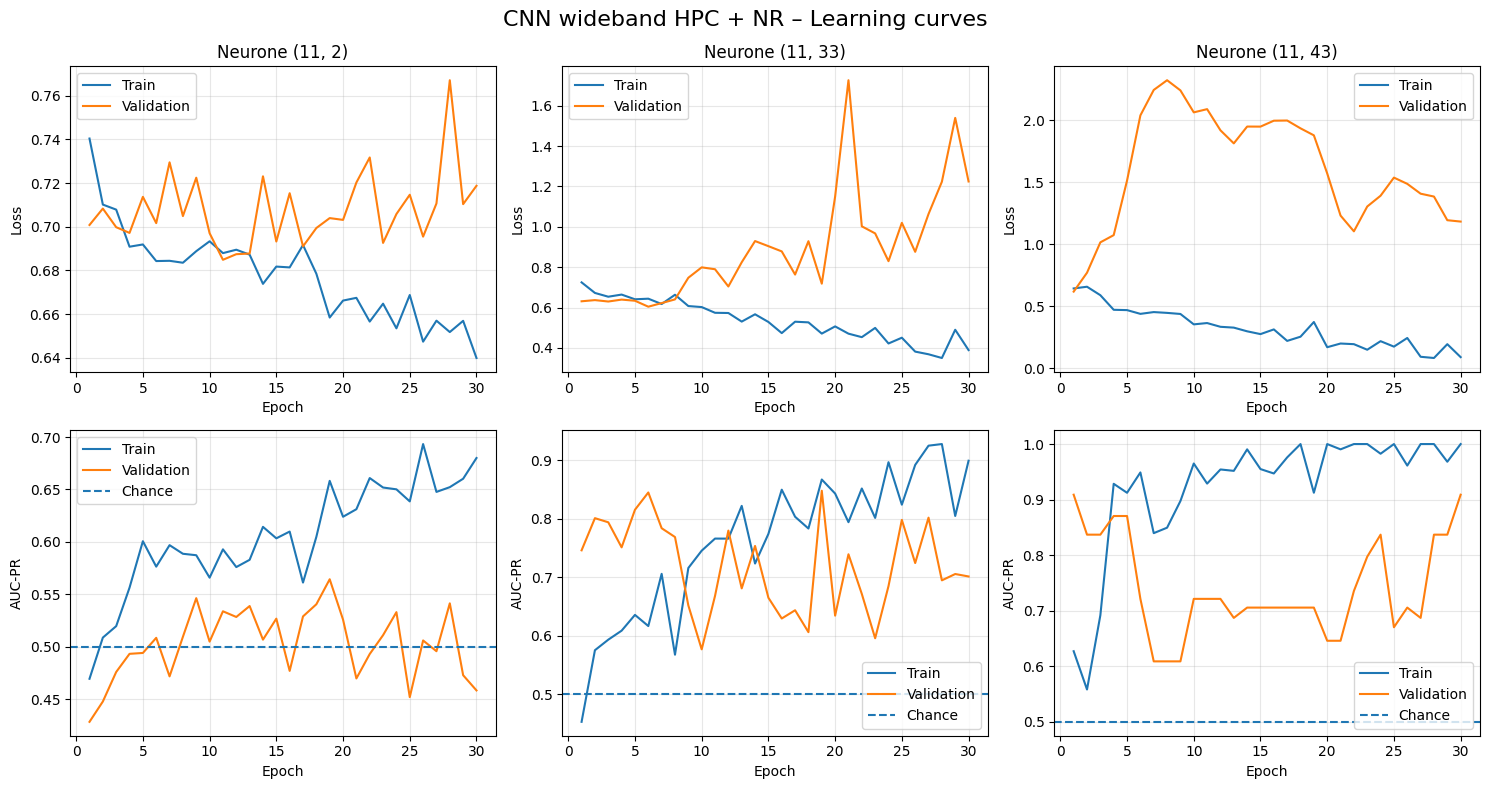

In [148]:
fig, axes = plt.subplots(
    2, len(selected_units),
    figsize=(15, 8),
    sharex=False
)

for i, unit in enumerate(selected_units):

    history = wideband_histories[unit].history
    epochs = range(1, len(history["loss"]) + 1)

    # =========================
    # LOSS
    # =========================
    axes[0, i].plot(
        epochs,
        history["loss"],
        label="Train"
    )

    axes[0, i].plot(
        epochs,
        history["val_loss"],
        label="Validation"
    )

    axes[0, i].set_title(f"Neurone {unit}")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_ylabel("Loss")
    axes[0, i].legend()
    axes[0, i].grid(alpha=0.3)

    # =========================
    # AUC-PR
    # =========================
    axes[1, i].plot(
        epochs,
        history["auc_pr"],
        label="Train"
    )

    axes[1, i].plot(
        epochs,
        history["val_auc_pr"],
        label="Validation"
    )

    axes[1, i].axhline(
        0.5,
        linestyle="--",
        label="Chance"
    )

    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("AUC-PR")
    axes[1, i].legend()
    axes[1, i].grid(alpha=0.3)

fig.suptitle(
    "CNN wideband HPC + NR – Learning curves",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [149]:
for unit in selected_units:
    print(
        unit,
        "AP test =",
        round(wideband_results[unit]["average_precision"], 3)
    )

(11, 2) AP test = 0.541
(11, 33) AP test = 0.608
(11, 43) AP test = 1.0


In [150]:
unit = (11, 43)

y_test = wideband_results[unit]["y_test"]
y_pred = wideband_results[unit]["y_pred"]

for true, pred in zip(y_test, y_pred):
    print(
        "réel =", int(true),
        "| proba =", round(float(pred), 4)
    )

réel = 1 | proba = 0.9875
réel = 1 | proba = 0.9554
réel = 0 | proba = 0.7732
réel = 0 | proba = 0.9427
réel = 0 | proba = 0.8716
réel = 1 | proba = 0.9758
réel = 0 | proba = 0.7516
réel = 1 | proba = 0.9979


In [151]:
print("Nombre test :", len(y_test))
print("Positifs :", int(y_test.sum()))
print("Négatifs :", int(len(y_test) - y_test.sum()))

Nombre test : 8
Positifs : 4
Négatifs : 4


In [157]:
for unit in selected_units:

    y_true = wideband_results[unit]["y_test"]
    y_score = wideband_results[unit]["y_pred"]
    y_class = (y_score >= 0.5).astype(int)

    print("\nNeurone", unit)
    print("n test :", len(y_true))
    print("AP      :", round(average_precision_score(y_true, y_score), 3))
    print("ROC-AUC :", round(roc_auc_score(y_true, y_score), 3))
    print("Accuracy:", round(accuracy_score(y_true, y_class), 3))
    print("Precision:", round(precision_score(y_true, y_class), 3))
    print("Recall  :", round(recall_score(y_true, y_class), 3))


Neurone (11, 2)
n test : 108
AP      : 0.541
ROC-AUC : 0.564
Accuracy: 0.537
Precision: 0.571
Recall  : 0.296

Neurone (11, 33)
n test : 30
AP      : 0.608
ROC-AUC : 0.533
Accuracy: 0.533
Precision: 0.667
Recall  : 0.133

Neurone (11, 43)
n test : 8
AP      : 1.0
ROC-AUC : 1.0
Accuracy: 0.5
Precision: 0.5
Recall  : 1.0


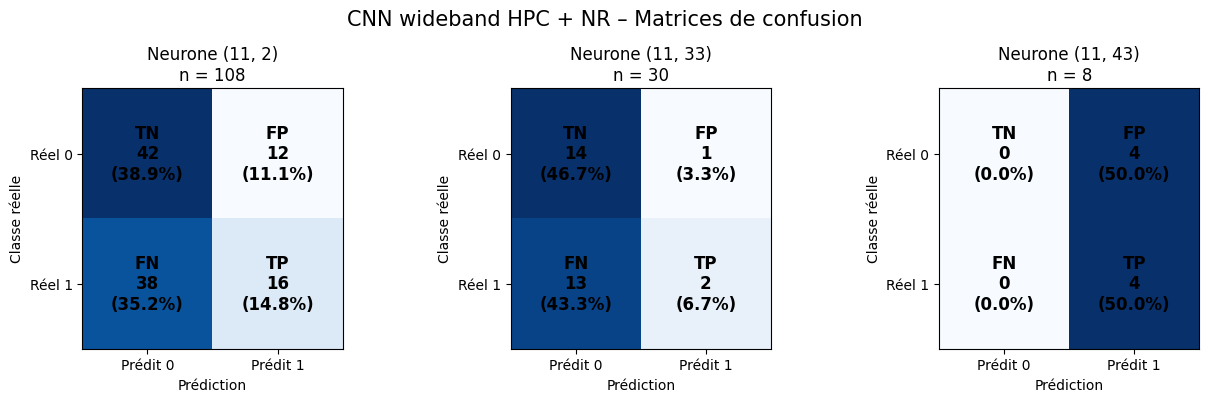

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, unit in zip(axes, selected_units):

    y_true = wideband_results[unit]["y_test"]
    y_score = wideband_results[unit]["y_pred"]
    y_pred = (y_score >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    # Pourcentages sur l'ensemble du test
    cm_pct = cm / cm.sum() * 100

    ax.imshow(cm, cmap="Blues")

    labels = [
        ["TN", "FP"],
        ["FN", "TP"]
    ]

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{labels[i][j]}\n{cm[i,j]}\n({cm_pct[i,j]:.1f}%)",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold"
            )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Prédit 0", "Prédit 1"])

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Réel 0", "Réel 1"])

    ax.set_title(
        f"Neurone {unit}\n"
        f"n = {len(y_true)}"
    )

    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Classe réelle")

plt.suptitle(
    "CNN wideband HPC + NR – Matrices de confusion",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [161]:
def build_wideband_cnn_grid(
    filters=(32, 64, 128),
    dropout=0.4,
    learning_rate=1e-3
):

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(20000, 96)),

        tf.keras.layers.Conv1D(
            filters[0], 21,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            filters[1], 11,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            filters[2], 7,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(dropout),

        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy"
    )

    return model

In [162]:
unit = (11, 2)

X_grid = cnn_data[unit]["X_train"]
y_grid = cnn_data[unit]["y_train"]

cnn = KerasClassifier(
    model=build_wideband_cnn_grid,
    epochs=30,
    batch_size=8,
    verbose=0,
    random_state=42
)

param_grid = {
    "model__filters": [
        (16, 32, 64),
        (32, 64, 128)
    ],
    "model__dropout": [
        0.2,
        0.4,
        0.6
    ],
    "model__learning_rate": [
        1e-3,
        1e-4
    ]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=cnn,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    refit=True,
    verbose=2,
    n_jobs=1
)

grid.fit(X_grid, y_grid)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.001; total time= 1.0min
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.001; total time=  43.8s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.001; total time=  33.4s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.0001; total time=  31.2s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.0001; total time=  31.4s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.0001; total time=  33.5s
[CV] END model__dropout=0.2, model__filters=(32, 64, 128), model__learning_rate=0.001; total time=  35.2s
[CV] END model__dropout=0.2, model__filters=(32, 64, 128), model__learning_rate=0.001; total time=  34.4s
[CV] END model__dropout=0.2, model__filters=(32, 64, 128), model__learning_rate=0.001; total t

,estimator,KerasClassifi..._weight=None )
,param_grid,"{'model__dropout': [0.2, 0.4, ...], 'model__filters': [(16, ...), (32, ...)], 'model__learning_rate': [0.001, 0.0001]}"
,scoring,'average_precision'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,model,<function bui...x720c6003eac0>


In [163]:
print("Meilleurs paramètres :")
print(grid.best_params_)

print("\nMeilleure AP en validation croisée :")
print(round(grid.best_score_, 3))

Meilleurs paramètres :
{'model__dropout': 0.2, 'model__filters': (16, 32, 64), 'model__learning_rate': 0.001}

Meilleure AP en validation croisée :
nan


In [164]:

results = pd.DataFrame(grid.cv_results_)

print(
    results[
        [
            "params",
            "mean_test_score",
            "split0_test_score",
            "split1_test_score",
            "split2_test_score"
        ]
    ]
)

                                               params  mean_test_score  \
0   {'model__dropout': 0.2, 'model__filters': (16,...              NaN   
1   {'model__dropout': 0.2, 'model__filters': (16,...              NaN   
2   {'model__dropout': 0.2, 'model__filters': (32,...              NaN   
3   {'model__dropout': 0.2, 'model__filters': (32,...              NaN   
4   {'model__dropout': 0.4, 'model__filters': (16,...              NaN   
5   {'model__dropout': 0.4, 'model__filters': (16,...              NaN   
6   {'model__dropout': 0.4, 'model__filters': (32,...              NaN   
7   {'model__dropout': 0.4, 'model__filters': (32,...              NaN   
8   {'model__dropout': 0.6, 'model__filters': (16,...              NaN   
9   {'model__dropout': 0.6, 'model__filters': (16,...              NaN   
10  {'model__dropout': 0.6, 'model__filters': (32,...              NaN   
11  {'model__dropout': 0.6, 'model__filters': (32,...              NaN   

    split0_test_score  split1_test_sc

In [168]:
def ap_scorer(estimator, X, y):
    y_proba = estimator.predict_proba(X)[:, 1]
    return average_precision_score(y, y_proba)

grid2 = GridSearchCV(
    estimator=cnn,
    param_grid=param_grid,
    scoring=ap_scorer,
    cv=cv,
    refit=True,
    verbose=2,
    n_jobs=1,
    error_score="raise"
)

grid2.fit(X_grid, y_grid)

print("Meilleurs paramètres :")
print(grid2.best_params_)

print("\nMeilleure AP CV :")
print(grid2.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.001; total time=  34.2s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.001; total time=  32.4s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.001; total time=  33.8s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.0001; total time=  33.3s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.0001; total time=  33.7s
[CV] END model__dropout=0.2, model__filters=(16, 32, 64), model__learning_rate=0.0001; total time=  32.9s
[CV] END model__dropout=0.2, model__filters=(32, 64, 128), model__learning_rate=0.001; total time=  35.6s
[CV] END model__dropout=0.2, model__filters=(32, 64, 128), model__learning_rate=0.001; total time=  35.4s
[CV] END model__dropout=0.2, model__filters=(32, 64, 128), model__learning_rate=0.001; total t

In [169]:
results2 = pd.DataFrame(grid2.cv_results_)

display(
    results2[
        [
            "param_model__filters",
            "param_model__dropout",
            "param_model__learning_rate",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].sort_values("rank_test_score")
)

,param_model__filters,param_model__dropout,param_model__learning_rate,mean_test_score,std_test_score,rank_test_score
3,"(32, 64, 128)",0.2,0.0001,0.608177,0.059357,1
1,"(16, 32, 64)",0.2,0.0001,0.594412,0.019689,2
5,"(16, 32, 64)",0.4,0.0001,0.588178,0.012701,3
7,"(32, 64, 128)",0.4,0.0001,0.582060,0.053063,4
6,"(32, 64, 128)",0.4,0.0010,0.574851,0.028690,5
11,"(32, 64, 128)",0.6,0.0001,0.570979,0.018575,6
9,"(16, 32, 64)",0.6,0.0001,0.569145,0.013422,7
4,"(16, 32, 64)",0.4,0.0010,0.560309,0.048545,8
0,"(16, 32, 64)",0.2,0.0010,0.539959,0.026960,9
8,"(16, 32, 64)",0.6,0.0010,0.539952,0.032416,10


In [170]:
wideband_hpc = {}

for unit in selected_units:

    # Données déjà chargées : (événements, 20000, 96)
    X_full = np.array(
        wideband_data[unit]["data"],
        dtype=np.float32
    )

    # On garde uniquement les 32 canaux HPC
    X_hpc = X_full[:, :, 64:]

    y = np.array(
        wideband_data[unit]["y"],
        dtype=np.float32
    )

    wideband_hpc[unit] = {
        "X": X_hpc,
        "y": y
    }

    print(
        unit,
        "HPC :", X_hpc.shape,
        "y :", y.shape
    )

(11, 2) HPC : (540, 20000, 32) y : (540,)
(11, 33) HPC : (150, 20000, 32) y : (150,)
(11, 43) HPC : (36, 20000, 32) y : (36,)


In [171]:
cnn_data_hpc = {}

for unit in selected_units:

    X_hpc = wideband_hpc[unit]["X"]
    y = wideband_hpc[unit]["y"]

    # Indices des événements
    indices = np.arange(len(y))

    # Même split que pour HPC+NR
    idx_train, idx_test = train_test_split(
        indices,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    X_train = X_hpc[idx_train]
    X_test = X_hpc[idx_test]
    y_train = y[idx_train]
    y_test = y[idx_test]

    # Normalisation calculée UNIQUEMENT sur le train HPC
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True)

    X_train = (X_train - mean) / (std + 1e-8)
    X_test = (X_test - mean) / (std + 1e-8)

    cnn_data_hpc[unit] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "mean": mean,
        "std": std,
        "idx_train": idx_train,
        "idx_test": idx_test
    }

    print(
        unit,
        "train :", X_train.shape,
        "test :", X_test.shape
    )

(11, 2) train : (432, 20000, 32) test : (108, 20000, 32)
(11, 33) train : (120, 20000, 32) test : (30, 20000, 32)
(11, 43) train : (28, 20000, 32) test : (8, 20000, 32)


In [172]:
def build_hpc_cnn():

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(20000, 32)),

        tf.keras.layers.Conv1D(
            32, kernel_size=21,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            64, kernel_size=11,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            128, kernel_size=7,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                curve="PR",
                name="auc_pr"
            )
        ]
    )

    return model

In [173]:
hpc_models = {}
hpc_histories = {}
hpc_results = {}

for unit in selected_units:

    print("\n==============================")
    print("Neurone :", unit)
    print("==============================")

    X_train = cnn_data_hpc[unit]["X_train"]
    X_test  = cnn_data_hpc[unit]["X_test"]
    y_train = cnn_data_hpc[unit]["y_train"]
    y_test  = cnn_data_hpc[unit]["y_test"]

    # Nouveau CNN HPC
    model = build_hpc_cnn()

    # Entraînement
    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=8,
        validation_split=0.2,
        verbose=1
    )

    # Prédiction sur le test
    y_pred = model.predict(
        X_test,
        batch_size=8
    ).ravel()

    # Average Precision
    ap = average_precision_score(
        y_test,
        y_pred
    )

    hpc_models[unit] = model
    hpc_histories[unit] = history

    hpc_results[unit] = {
        "average_precision": ap,
        "y_test": y_test,
        "y_pred": y_pred
    }

    print(
        "\nAverage Precision HPC",
        unit,
        ":",
        round(ap, 3)
    )


Neurone : (11, 2)
Epoch 1/30


I0000 00:00:1789568426.558022 1752060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40515864__.58


44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - auc_pr: 0.5100 - loss: 0.7113 - val_auc_pr: 0.5170 - val_loss: 0.6944
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - auc_pr: 0.5617 - loss: 0.6845 - val_auc_pr: 0.5464 - val_loss: 0.6941
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - auc_pr: 0.5891 - loss: 0.6809 - val_auc_pr: 0.5191 - val_loss: 0.6907
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - auc_pr: 0.6228 - loss: 0.6737 - val_auc_pr: 0.4673 - val_loss: 0.6914
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - auc_pr: 0.6375 - loss: 0.6627 - val_auc_pr: 0.5148 - val_loss: 0.6883
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - auc_pr: 0.6231 - loss: 0.6681 - val_auc_pr: 0.5177 - val_loss: 0.6899
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - auc_pr: 0.7025 - loss: 0.6494 - val_auc_pr: 0.5737 - val_loss: 0.6945
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - auc_pr: 0.6495 - loss: 0.6609 - val_auc_pr: 0.5676 - val_loss: 0.6856
Epoch 9/30
44/44 ━━━━━━━━

I0000 00:00:1789568481.230952 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40533593__.53


12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - auc_pr: 0.6093 - loss: 0.6778 - val_auc_pr: 0.7175 - val_loss: 0.6776
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - auc_pr: 0.6913 - loss: 0.6410 - val_auc_pr: 0.6420 - val_loss: 0.6881
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - auc_pr: 0.7477 - loss: 0.6145 - val_auc_pr: 0.7255 - val_loss: 0.6896
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - auc_pr: 0.7914 - loss: 0.6028 - val_auc_pr: 0.7590 - val_loss: 0.6886
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - auc_pr: 0.7934 - loss: 0.5762 - val_auc_pr: 0.7088 - val_loss: 0.6934
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - auc_pr: 0.7961 - loss: 0.5615 - val_auc_pr: 0.7837 - val_loss: 0.6828
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - auc_pr: 0.8659 - loss: 0.5340 - val_auc_pr: 0.7691 - val_loss: 0.6752
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - auc_pr: 0.8077 - loss: 0.5385 - val_auc_pr: 0.7301 - val_loss: 0.6847
Epoch 9/30
12/12 ━━━━━━━━

I0000 00:00:1789568509.072894 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40546608__.58


1/3 ━━━━━━━━━━━━━━━━━━━━ 17s 9s/step - auc_pr: 0.6029 - loss: 0.7399

I0000 00:00:1789568512.909046 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40546608__.58


3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - auc_pr: 0.3772 - loss: 0.7295 - val_auc_pr: 0.5180 - val_loss: 0.7702
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - auc_pr: 0.5632 - loss: 0.6761 - val_auc_pr: 0.5623 - val_loss: 0.7576
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - auc_pr: 0.8106 - loss: 0.6391 - val_auc_pr: 0.5411 - val_loss: 0.7401
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - auc_pr: 0.9257 - loss: 0.5827 - val_auc_pr: 0.5284 - val_loss: 0.7219
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - auc_pr: 0.9437 - loss: 0.5291 - val_auc_pr: 0.4868 - val_loss: 0.7053
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - auc_pr: 0.8896 - loss: 0.5488 - val_auc_pr: 0.7594 - val_loss: 0.6940
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - auc_pr: 0.8816 - loss: 0.5445 - val_auc_pr: 0.6491 - val_loss: 0.6842
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - auc_pr: 0.9126 - loss: 0.5243 - val_auc_pr: 0.8360 - val_loss: 0.6753
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms

In [174]:
def build_hpc_nr_cnn_optimized():

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(20000, 96)),

        tf.keras.layers.Conv1D(
            32, kernel_size=21,
            activation="relu", padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            64, kernel_size=11,
            activation="relu", padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            128, kernel_size=7,
            activation="relu", padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                curve="PR",
                name="auc_pr"
            )
        ]
    )

    return model

In [175]:
hpc_nr_opt_models = {}
hpc_nr_opt_histories = {}
hpc_nr_opt_results = {}

for unit in selected_units:

    print("\n==============================")
    print("Neurone :", unit)
    print("==============================")

    X_train = cnn_data[unit]["X_train"]
    X_test  = cnn_data[unit]["X_test"]
    y_train = cnn_data[unit]["y_train"]
    y_test  = cnn_data[unit]["y_test"]

    model = build_hpc_nr_cnn_optimized()

    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=8,
        validation_split=0.2,
        verbose=1
    )

    y_pred = model.predict(
        X_test,
        batch_size=8
    ).ravel()

    ap = average_precision_score(
        y_test,
        y_pred
    )

    hpc_nr_opt_models[unit] = model
    hpc_nr_opt_histories[unit] = history

    hpc_nr_opt_results[unit] = {
        "average_precision": ap,
        "y_test": y_test,
        "y_pred": y_pred
    }

    print(
        "\nAverage Precision HPC+NR",
        unit,
        ":",
        round(ap, 3)
    )


Neurone : (11, 2)
Epoch 1/30


I0000 00:00:1789568740.329358 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40558095__.58


44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 175ms/step - auc_pr: 0.4714 - loss: 0.7244 - val_auc_pr: 0.4713 - val_loss: 0.7272
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc_pr: 0.5459 - loss: 0.6913 - val_auc_pr: 0.4827 - val_loss: 0.7113
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc_pr: 0.6144 - loss: 0.6766 - val_auc_pr: 0.4808 - val_loss: 0.7003
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc_pr: 0.5884 - loss: 0.6757 - val_auc_pr: 0.4994 - val_loss: 0.7117
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc_pr: 0.6042 - loss: 0.6742 - val_auc_pr: 0.5172 - val_loss: 0.6896
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc_pr: 0.6349 - loss: 0.6695 - val_auc_pr: 0.4828 - val_loss: 0.7057
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - auc_pr: 0.6290 - loss: 0.6680 - val_auc_pr: 0.5748 - val_loss: 0.6803
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc_pr: 0.6652 - loss: 0.6604 - val_auc_pr: 0.6051 - val_loss: 0.6721
Epoch 9/30
44/44 ━━━━━━━━

I0000 00:00:1789568804.625407 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40575824__.53


12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - auc_pr: 0.4736 - loss: 0.7018 - val_auc_pr: 0.6736 - val_loss: 0.6832
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - auc_pr: 0.6453 - loss: 0.6568 - val_auc_pr: 0.6968 - val_loss: 0.6797
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - auc_pr: 0.6751 - loss: 0.6491 - val_auc_pr: 0.7108 - val_loss: 0.6812
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - auc_pr: 0.6829 - loss: 0.6262 - val_auc_pr: 0.7623 - val_loss: 0.6734
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - auc_pr: 0.7310 - loss: 0.6041 - val_auc_pr: 0.7496 - val_loss: 0.6783
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - auc_pr: 0.7587 - loss: 0.6044 - val_auc_pr: 0.7145 - val_loss: 0.6877
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - auc_pr: 0.8144 - loss: 0.5694 - val_auc_pr: 0.7015 - val_loss: 0.7116
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - auc_pr: 0.8306 - loss: 0.5519 - val_auc_pr: 0.7123 - val_loss: 0.7159
Epoch 9/30
12/12 ━━━━━━━━

I0000 00:00:1789568836.145513 1752056 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40588839__.58


1/3 ━━━━━━━━━━━━━━━━━━━━ 18s 9s/step - auc_pr: 0.6286 - loss: 0.6989

I0000 00:00:1789568840.337575 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40588839__.58


3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - auc_pr: 0.3676 - loss: 0.7268 - val_auc_pr: 0.6459 - val_loss: 0.6509
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - auc_pr: 0.6001 - loss: 0.6815 - val_auc_pr: 0.6459 - val_loss: 0.6467
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - auc_pr: 0.8749 - loss: 0.6060 - val_auc_pr: 0.6459 - val_loss: 0.6441
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - auc_pr: 0.8760 - loss: 0.6025 - val_auc_pr: 0.5976 - val_loss: 0.6434
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - auc_pr: 0.9252 - loss: 0.5611 - val_auc_pr: 0.5976 - val_loss: 0.6417
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - auc_pr: 0.8855 - loss: 0.5532 - val_auc_pr: 0.5976 - val_loss: 0.6404
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - auc_pr: 0.7900 - loss: 0.5754 - val_auc_pr: 0.5976 - val_loss: 0.6388
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - auc_pr: 0.9211 - loss: 0.5324 - val_auc_pr: 0.6459 - val_loss: 0.6374
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

In [176]:
comparison = []

for unit in selected_units:

    ap_hpc = hpc_results[unit]["average_precision"]
    ap_hpc_nr = hpc_nr_opt_results[unit]["average_precision"]

    comparison.append({
        "Neurone": str(unit),
        "AP HPC": ap_hpc,
        "AP HPC+NR": ap_hpc_nr,
        "Δ AP (NR - HPC)": ap_hpc_nr - ap_hpc
    })

comparison_df = pd.DataFrame(comparison)

display(
    comparison_df.style.format({
        "AP HPC": "{:.3f}",
        "AP HPC+NR": "{:.3f}",
        "Δ AP (NR - HPC)": "{:+.3f}"
    })
)

,Neurone,AP HPC,AP HPC+NR,Δ AP (NR - HPC)
0,"(11, 2)",0.699,0.548,-0.151
1,"(11, 33)",0.786,0.605,-0.181
2,"(11, 43)",0.917,0.643,-0.274


In [177]:
rng = np.random.default_rng(42)

summary = []
bootstrap_results = {}

n_bootstrap = 1000

for unit in selected_units:

    # -----------------------------------
    # Données du même ensemble de test
    # -----------------------------------
    y_true = np.asarray(hpc_results[unit]["y_test"])

    pred_hpc = np.asarray(
        hpc_results[unit]["y_pred"]
    )

    pred_hpc_nr = np.asarray(
        hpc_nr_opt_results[unit]["y_pred"]
    )

    # Vérification : mêmes labels de test
    assert np.array_equal(
        y_true,
        hpc_nr_opt_results[unit]["y_test"]
    )

    # -----------------------------------
    # Métriques HPC
    # -----------------------------------
    ap_hpc = average_precision_score(
        y_true, pred_hpc
    )

    auc_hpc = roc_auc_score(
        y_true, pred_hpc
    )

    class_hpc = (pred_hpc >= 0.5).astype(int)

    precision_hpc = precision_score(
        y_true,
        class_hpc,
        zero_division=0
    )

    recall_hpc = recall_score(
        y_true,
        class_hpc,
        zero_division=0
    )

    # -----------------------------------
    # Métriques HPC + NR
    # -----------------------------------
    ap_hpc_nr = average_precision_score(
        y_true, pred_hpc_nr
    )

    auc_hpc_nr = roc_auc_score(
        y_true, pred_hpc_nr
    )

    class_hpc_nr = (
        pred_hpc_nr >= 0.5
    ).astype(int)

    precision_hpc_nr = precision_score(
        y_true,
        class_hpc_nr,
        zero_division=0
    )

    recall_hpc_nr = recall_score(
        y_true,
        class_hpc_nr,
        zero_division=0
    )

    # -----------------------------------
    # Bootstrap APPARIÉ de ΔAP
    # -----------------------------------
    delta_boot = []

    n = len(y_true)

    for _ in range(n_bootstrap):

        idx = rng.choice(
            n,
            size=n,
            replace=True
        )

        y_b = y_true[idx]

        # Certains petits bootstrap peuvent
        # ne contenir qu'une seule classe
        if len(np.unique(y_b)) < 2:
            continue

        ap_hpc_b = average_precision_score(
            y_b,
            pred_hpc[idx]
        )

        ap_hpc_nr_b = average_precision_score(
            y_b,
            pred_hpc_nr[idx]
        )

        delta_boot.append(
            ap_hpc_nr_b - ap_hpc_b
        )

    delta_boot = np.asarray(delta_boot)

    # Différence observée
    delta_ap = ap_hpc_nr - ap_hpc

    # IC bootstrap à 95 %
    ci_low, ci_high = np.percentile(
        delta_boot,
        [2.5, 97.5]
    )

    # Proportion des bootstrap où NR > HPC
    p_nr_better = np.mean(delta_boot > 0)

    bootstrap_results[unit] = delta_boot

    # -----------------------------------
    # Résumé
    # -----------------------------------
    summary.append({
        "Neurone": str(unit),

        "AP HPC": ap_hpc,
        "AP HPC+NR": ap_hpc_nr,
        "ΔAP": delta_ap,

        "ROC-AUC HPC": auc_hpc,
        "ROC-AUC HPC+NR": auc_hpc_nr,

        "Precision HPC": precision_hpc,
        "Precision HPC+NR": precision_hpc_nr,

        "Recall HPC": recall_hpc,
        "Recall HPC+NR": recall_hpc_nr,

        "IC95% ΔAP bas": ci_low,
        "IC95% ΔAP haut": ci_high,

        "Bootstrap NR > HPC": p_nr_better
    })


summary_df = pd.DataFrame(summary)

display(
    summary_df.style.format({
        "AP HPC": "{:.3f}",
        "AP HPC+NR": "{:.3f}",
        "ΔAP": "{:+.3f}",

        "ROC-AUC HPC": "{:.3f}",
        "ROC-AUC HPC+NR": "{:.3f}",

        "Precision HPC": "{:.3f}",
        "Precision HPC+NR": "{:.3f}",

        "Recall HPC": "{:.3f}",
        "Recall HPC+NR": "{:.3f}",

        "IC95% ΔAP bas": "{:+.3f}",
        "IC95% ΔAP haut": "{:+.3f}",

        "Bootstrap NR > HPC": "{:.3f}"
    })
)

,Neurone,AP HPC,AP HPC+NR,ΔAP,ROC-AUC HPC,ROC-AUC HPC+NR,Precision HPC,Precision HPC+NR,Recall HPC,Recall HPC+NR,IC95% ΔAP bas,IC95% ΔAP haut,Bootstrap NR > HPC
0,"(11, 2)",0.699,0.548,-0.151,0.651,0.598,0.512,0.540,0.778,0.870,-0.258,-0.000,0.025
1,"(11, 33)",0.786,0.605,-0.181,0.782,0.573,0.636,0.526,0.933,0.667,-0.343,-0.025,0.005
2,"(11, 43)",0.917,0.643,-0.274,0.875,0.500,1.000,0.500,0.250,0.500,-0.750,+0.083,0.078


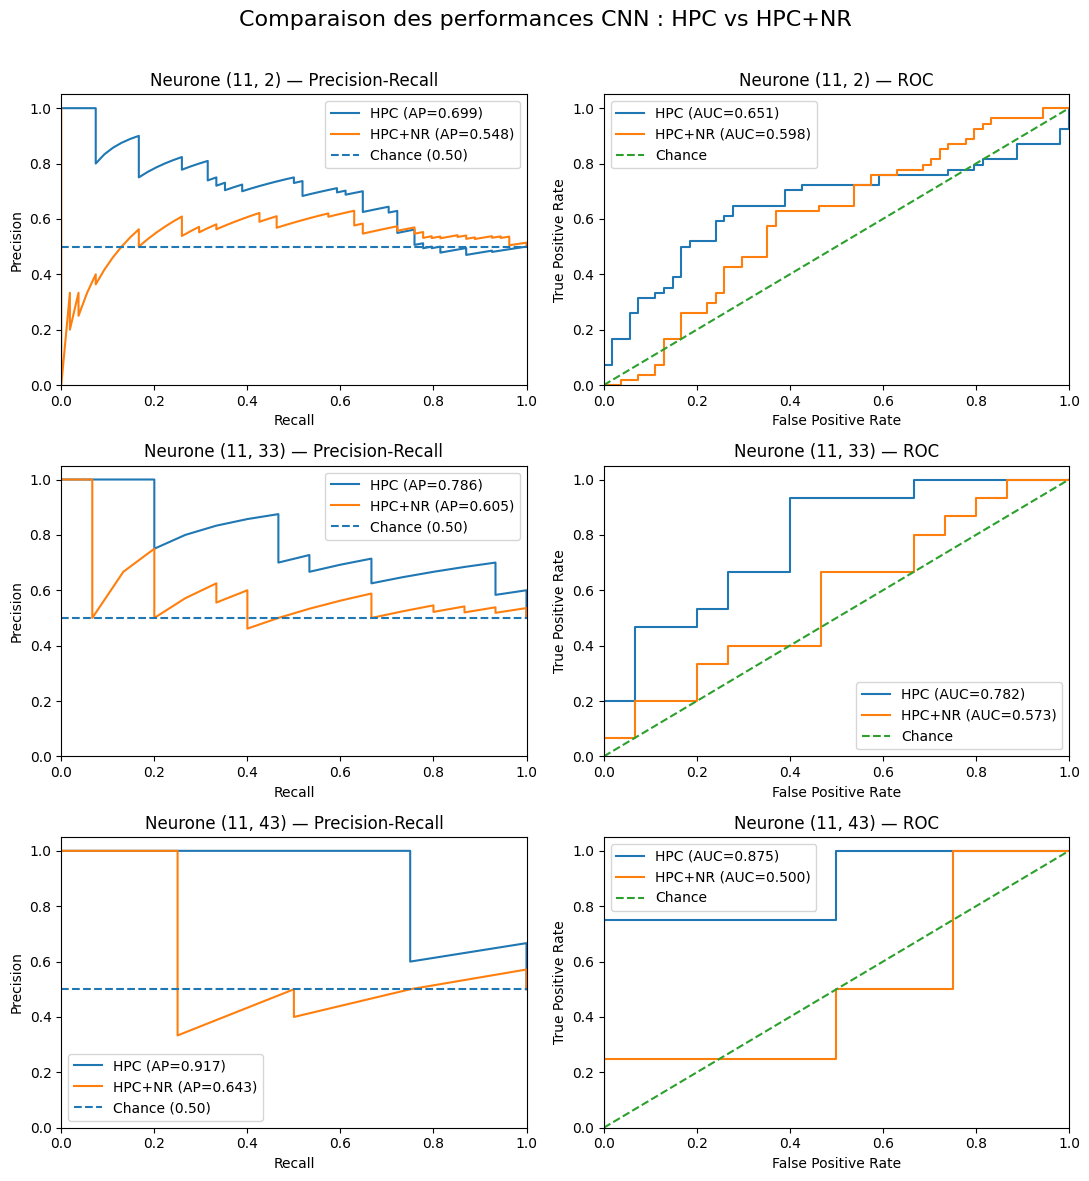

In [182]:
fig, axes = plt.subplots(
    len(selected_units),
    2,
    figsize=(11, 4 * len(selected_units))
)

for i, unit in enumerate(selected_units):

    y_true = np.asarray(hpc_results[unit]["y_test"])
    pred_hpc = np.asarray(hpc_results[unit]["y_pred"])
    pred_nr = np.asarray(hpc_nr_opt_results[unit]["y_pred"])

    # =========================================================
    # PRECISION-RECALL
    # =========================================================

    precision_hpc, recall_hpc, _ = precision_recall_curve(
        y_true, pred_hpc
    )

    precision_nr, recall_nr, _ = precision_recall_curve(
        y_true, pred_nr
    )

    ap_hpc = average_precision_score(y_true, pred_hpc)
    ap_nr = average_precision_score(y_true, pred_nr)

    ax = axes[i, 0]

    ax.plot(
        recall_hpc,
        precision_hpc,
        label=f"HPC (AP={ap_hpc:.3f})"
    )

    ax.plot(
        recall_nr,
        precision_nr,
        label=f"HPC+NR (AP={ap_nr:.3f})"
    )

    # Niveau de chance = proportion de positifs
    ax.axhline(
        y_true.mean(),
        linestyle="--",
        label=f"Chance ({y_true.mean():.2f})"
    )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Neurone {unit} — Precision-Recall")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend()


    # =========================================================
    # ROC
    # =========================================================

    fpr_hpc, tpr_hpc, _ = roc_curve(
        y_true, pred_hpc
    )

    fpr_nr, tpr_nr, _ = roc_curve(
        y_true, pred_nr
    )

    auc_hpc = roc_auc_score(y_true, pred_hpc)
    auc_nr = roc_auc_score(y_true, pred_nr)

    ax = axes[i, 1]

    ax.plot(
        fpr_hpc,
        tpr_hpc,
        label=f"HPC (AUC={auc_hpc:.3f})"
    )

    ax.plot(
        fpr_nr,
        tpr_nr,
        label=f"HPC+NR (AUC={auc_nr:.3f})"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance"
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Neurone {unit} — ROC")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend()


# Titre général
fig.suptitle(
    "Comparaison des performances CNN : HPC vs HPC+NR",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [181]:
rng = np.random.default_rng(42)

n_perm = 5000
permutation_results = []

for unit in selected_units:

    y_true = np.asarray(hpc_results[unit]["y_test"])
    pred_hpc = np.asarray(hpc_results[unit]["y_pred"])
    pred_nr = np.asarray(hpc_nr_opt_results[unit]["y_pred"])

    # Différence réellement observée
    ap_hpc = average_precision_score(y_true, pred_hpc)
    ap_nr = average_precision_score(y_true, pred_nr)

    delta_obs = ap_nr - ap_hpc

    deltas_perm = []

    for _ in range(n_perm):

        # Pour chaque événement :
        # échange ou non les prédictions des deux CNN
        swap = rng.random(len(y_true)) < 0.5

        perm_hpc = pred_hpc.copy()
        perm_nr = pred_nr.copy()

        temp = perm_hpc[swap].copy()
        perm_hpc[swap] = perm_nr[swap]
        perm_nr[swap] = temp

        delta_perm = (
            average_precision_score(y_true, perm_nr)
            -
            average_precision_score(y_true, perm_hpc)
        )

        deltas_perm.append(delta_perm)

    deltas_perm = np.asarray(deltas_perm)

    # Test bilatéral
    p_value = (
        np.sum(np.abs(deltas_perm) >= np.abs(delta_obs)) + 1
    ) / (n_perm + 1)

    permutation_results.append({
        "Neurone": str(unit),
        "ΔAP observé": delta_obs,
        "p permutation": p_value
    })


permutation_df = pd.DataFrame(permutation_results)

display(
    permutation_df.style.format({
        "ΔAP observé": "{:+.3f}",
        "p permutation": "{:.4f}"
    })
)

,Neurone,ΔAP observé,p permutation
0,"(11, 2)",-0.151,0.0724
1,"(11, 33)",-0.181,0.1146
2,"(11, 43)",-0.274,0.2216


In [183]:
control_unit = (11, 37)

j = mpfc_units_ids.index(control_unit)
y = Y_mpfc[:, j]

idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]

print("Neurone contrôle :", control_unit)
print("Delta-spikes :", len(idx_pos))

# Même méthode que pour les 3 autres neurones
rng_control = np.random.default_rng(42)

idx_neg_selected = rng_control.choice(
    idx_neg,
    size=len(idx_pos),
    replace=False
)

idx_selected = np.concatenate([
    idx_pos,
    idx_neg_selected
])

y_control = y[idx_selected]
peaks_control = delta_peaks[idx_selected]

intervals_control = (
    peaks_control[:, None]
    + np.array([-0.5, 0.5])
)

print("Positifs :", int(y_control.sum()))
print("Négatifs :", len(y_control) - int(y_control.sum()))
print("Total :", len(y_control))
print("Intervals :", intervals_control.shape)

Neurone contrôle : (11, 37)
Delta-spikes : 14
Positifs : 14
Négatifs : 14
Total : 28
Intervals : (28, 2)


In [184]:
control_unit = (11, 37)

data_control, t_control = fmb.data.loadWideband(
    xml_file,
    channels=channels,          # 64 NR + 32 HPC = 96 canaux
    intervals=intervals_control,
    cat=False,
    trim=True
)

X_control_raw = np.array(
    data_control,
    dtype=np.float32
)

y_control = np.array(
    y_control,
    dtype=np.float32
)

print("Neurone contrôle :", control_unit)
print("X :", X_control_raw.shape)
print("y :", y_control.shape)
print("Positifs :", int(y_control.sum()))
print("Négatifs :", int(len(y_control) - y_control.sum()))

Neurone contrôle : (11, 37)
X : (28, 20000, 96)
y : (28,)
Positifs : 14
Négatifs : 14


In [185]:
X_control_hpc_raw = X_control_raw[:, :, 64:]

print(X_control_hpc_raw.shape)

(28, 20000, 32)


In [186]:
X_train_common_raw = []
y_train_common = []

for unit in selected_units:

    # Wideband brut NR + HPC
    X_unit = np.array(
        wideband_data[unit]["data"],
        dtype=np.float32
    )

    y_unit = np.array(
        wideband_data[unit]["y"],
        dtype=np.float32
    )

    X_train_common_raw.append(X_unit)
    y_train_common.append(y_unit)

# On rassemble les 3 neurones
X_train_common_raw = np.concatenate(
    X_train_common_raw,
    axis=0
)

y_train_common = np.concatenate(
    y_train_common,
    axis=0
)

print("=== DATASET COMMUN ===")
print("X HPC+NR :", X_train_common_raw.shape)
print("y :", y_train_common.shape)
print("Positifs :", int(y_train_common.sum()))
print(
    "Négatifs :",
    int(len(y_train_common) - y_train_common.sum())
)

# Version HPC seul : les 32 derniers canaux
X_train_common_hpc_raw = X_train_common_raw[:, :, 64:]

print("\nX HPC seul :", X_train_common_hpc_raw.shape)

=== DATASET COMMUN ===
X HPC+NR : (726, 20000, 96)
y : (726,)
Positifs : 363
Négatifs : 363

X HPC seul : (726, 20000, 32)


In [187]:
mean_common_nr = X_train_common_raw.mean(
    axis=(0, 1),
    keepdims=True
)

std_common_nr = X_train_common_raw.std(
    axis=(0, 1),
    keepdims=True
)

X_train_common_nr = (
    X_train_common_raw - mean_common_nr
) / (std_common_nr + 1e-8)

# On applique EXACTEMENT la même normalisation au neurone contrôle
X_control_nr = (
    X_control_raw - mean_common_nr
) / (std_common_nr + 1e-8)


mean_common_hpc = X_train_common_hpc_raw.mean(
    axis=(0, 1),
    keepdims=True
)

std_common_hpc = X_train_common_hpc_raw.std(
    axis=(0, 1),
    keepdims=True
)

X_train_common_hpc = (
    X_train_common_hpc_raw - mean_common_hpc
) / (std_common_hpc + 1e-8)

X_control_hpc = (
    X_control_hpc_raw - mean_common_hpc
) / (std_common_hpc + 1e-8)


print("=== HPC + NR ===")
print("Train   :", X_train_common_nr.shape)
print("Control :", X_control_nr.shape)

print("\n=== HPC ===")
print("Train   :", X_train_common_hpc.shape)
print("Control :", X_control_hpc.shape)

print("\nLabels train :", y_train_common.shape)
print("Labels control :", y_control.shape)

=== HPC + NR ===
Train   : (726, 20000, 96)
Control : (28, 20000, 96)

=== HPC ===
Train   : (726, 20000, 32)
Control : (28, 20000, 32)

Labels train : (726,)
Labels control : (28,)


In [188]:
# ============================================================
# CNN COMMUN : HPC vs HPC + NR
# ============================================================

# Pour reproductibilité
tf.keras.utils.set_random_seed(42)


# ------------------------------------------------------------
# Fonction CNN commune
# ------------------------------------------------------------

def build_common_cnn(n_channels):

    model = tf.keras.Sequential([

        tf.keras.Input(shape=(20000, n_channels)),

        tf.keras.layers.Conv1D(
            32, 21,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            64, 11,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(
            128, 7,
            activation="relu",
            padding="same"
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                curve="PR",
                name="auc_pr"
            )
        ]
    )

    return model


# ============================================================
# 1. CNN COMMUN HPC
# ============================================================

print("===== CNN COMMUN HPC =====")

common_hpc_model = build_common_cnn(32)

history_common_hpc = common_hpc_model.fit(
    X_train_common_hpc,
    y_train_common,
    validation_split=0.2,
    epochs=30,
    batch_size=8,
    shuffle=True,
    verbose=1
)


# ============================================================
# 2. CNN COMMUN HPC + NR
# ============================================================

print("\n===== CNN COMMUN HPC + NR =====")

# On remet la même seed avant le deuxième entraînement
tf.keras.utils.set_random_seed(42)

common_nr_model = build_common_cnn(96)

history_common_nr = common_nr_model.fit(
    X_train_common_nr,
    y_train_common,
    validation_split=0.2,
    epochs=30,
    batch_size=8,
    shuffle=True,
    verbose=1
)

print("\n===== ENTRAÎNEMENTS TERMINÉS =====")

===== CNN COMMUN HPC =====
Epoch 1/30


I0000 00:00:1789571450.783584 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40600326__.58


70/73 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc_pr: 0.5376 - loss: 0.7029

I0000 00:00:1789571456.825322 1752061 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40600326__.58


73/73 ━━━━━━━━━━━━━━━━━━━━ 24s 204ms/step - auc_pr: 0.5064 - loss: 0.7131 - val_auc_pr: 0.4484 - val_loss: 0.7404
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - auc_pr: 0.5895 - loss: 0.6872 - val_auc_pr: 0.4808 - val_loss: 0.7537
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - auc_pr: 0.6378 - loss: 0.6746 - val_auc_pr: 0.4100 - val_loss: 0.7234
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - auc_pr: 0.6208 - loss: 0.6764 - val_auc_pr: 0.3612 - val_loss: 0.7680
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - auc_pr: 0.6171 - loss: 0.6747 - val_auc_pr: 0.3919 - val_loss: 0.7539
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - auc_pr: 0.6415 - loss: 0.6670 - val_auc_pr: 0.4077 - val_loss: 0.7086
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - auc_pr: 0.6891 - loss: 0.6526 - val_auc_pr: 0.4151 - val_loss: 0.7235
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - auc_pr: 0.6873 - loss: 0.6486 - val_auc_pr: 0.4419 - val_loss: 0.7789
Epoch 9/30
73/73 ━━━━━━━━

I0000 00:00:1789571534.324959 1752057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40622151__.58


71/73 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - auc_pr: 0.5098 - loss: 0.7126

I0000 00:00:1789571540.486241 1752054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40622151__.58


73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - auc_pr: 0.4992 - loss: 0.7198 - val_auc_pr: 0.4684 - val_loss: 0.7519
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - auc_pr: 0.5692 - loss: 0.6933 - val_auc_pr: 0.4290 - val_loss: 0.7198
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - auc_pr: 0.6188 - loss: 0.6779 - val_auc_pr: 0.4723 - val_loss: 0.7590
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - auc_pr: 0.6419 - loss: 0.6727 - val_auc_pr: 0.4351 - val_loss: 0.7415
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - auc_pr: 0.6683 - loss: 0.6594 - val_auc_pr: 0.3870 - val_loss: 0.7568
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - auc_pr: 0.7033 - loss: 0.6518 - val_auc_pr: 0.3958 - val_loss: 0.9521
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - auc_pr: 0.7202 - loss: 0.6423 - val_auc_pr: 0.3893 - val_loss: 0.7693
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - auc_pr: 0.7418 - loss: 0.6287 - val_auc_pr: 0.3741 - val_loss: 0.7633
Epoch 9/30
73/73 ━━━━━━━━

In [189]:
# Prédictions CNN commun HPC
pred_common_hpc = common_hpc_model.predict(
    X_control_hpc,
    verbose=0
).ravel()

# Prédictions CNN commun HPC + NR
pred_common_nr = common_nr_model.predict(
    X_control_nr,
    verbose=0
).ravel()


# ------------------------------------------------------------
# Métriques
# ------------------------------------------------------------

ap_common_hpc = average_precision_score(
    y_control,
    pred_common_hpc
)

ap_common_nr = average_precision_score(
    y_control,
    pred_common_nr
)

auc_common_hpc = roc_auc_score(
    y_control,
    pred_common_hpc
)

auc_common_nr = roc_auc_score(
    y_control,
    pred_common_nr
)


# ------------------------------------------------------------
# Résultats
# ------------------------------------------------------------

print("===== NEURONE CONTRÔLE (11,37) =====")
print("n =", len(y_control))

print("\nHPC seul")
print(f"AP      : {ap_common_hpc:.3f}")
print(f"ROC-AUC : {auc_common_hpc:.3f}")

print("\nHPC + NR")
print(f"AP      : {ap_common_nr:.3f}")
print(f"ROC-AUC : {auc_common_nr:.3f}")

print("\nDifférence HPC+NR - HPC")
print(f"Δ AP      : {ap_common_nr - ap_common_hpc:+.3f}")
print(f"Δ ROC-AUC : {auc_common_nr - auc_common_hpc:+.3f}")

I0000 00:00:1789572115.298555 1752056 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


===== NEURONE CONTRÔLE (11,37) =====
n = 28

HPC seul
AP      : 0.593
ROC-AUC : 0.577

HPC + NR
AP      : 0.547
ROC-AUC : 0.592

Différence HPC+NR - HPC
Δ AP      : -0.046
Δ ROC-AUC : +0.015


In [190]:
rng = np.random.default_rng(42)

# ============================================================
# BOOTSTRAP APPARIÉ
# ============================================================

n_boot = 5000
delta_boot = []

for _ in range(n_boot):

    idx = rng.choice(
        len(y_control),
        size=len(y_control),
        replace=True
    )

    y_b = y_control[idx]

    # Il faut les deux classes pour calculer l'AP correctement
    if len(np.unique(y_b)) < 2:
        continue

    ap_hpc = average_precision_score(
        y_b,
        pred_common_hpc[idx]
    )

    ap_nr = average_precision_score(
        y_b,
        pred_common_nr[idx]
    )

    delta_boot.append(ap_nr - ap_hpc)

delta_boot = np.array(delta_boot)

ci_low, ci_high = np.percentile(
    delta_boot,
    [2.5, 97.5]
)

print("===== BOOTSTRAP (11,37) =====")
print(f"Δ AP observé : {ap_common_nr - ap_common_hpc:+.3f}")
print(f"IC95%        : [{ci_low:+.3f}, {ci_high:+.3f}]")


# ============================================================
# PERMUTATION APPARIÉE
# ============================================================

rng = np.random.default_rng(42)

observed_delta = ap_common_nr - ap_common_hpc

n_perm = 5000
delta_perm = []

for _ in range(n_perm):

    swap = rng.random(len(y_control)) < 0.5

    pred_hpc_perm = pred_common_hpc.copy()
    pred_nr_perm = pred_common_nr.copy()

    temp = pred_hpc_perm[swap].copy()

    pred_hpc_perm[swap] = pred_nr_perm[swap]
    pred_nr_perm[swap] = temp

    ap_hpc_perm = average_precision_score(
        y_control,
        pred_hpc_perm
    )

    ap_nr_perm = average_precision_score(
        y_control,
        pred_nr_perm
    )

    delta_perm.append(
        ap_nr_perm - ap_hpc_perm
    )

delta_perm = np.array(delta_perm)

p_value = (
    np.sum(np.abs(delta_perm) >= abs(observed_delta)) + 1
) / (n_perm + 1)

print("\n===== PERMUTATION (11,37) =====")
print(f"Δ AP observé : {observed_delta:+.3f}")
print(f"p-value      : {p_value:.4f}")

===== BOOTSTRAP (11,37) =====
Δ AP observé : -0.046
IC95%        : [-0.271, +0.215]

===== PERMUTATION (11,37) =====
Δ AP observé : -0.046
p-value      : 0.7431


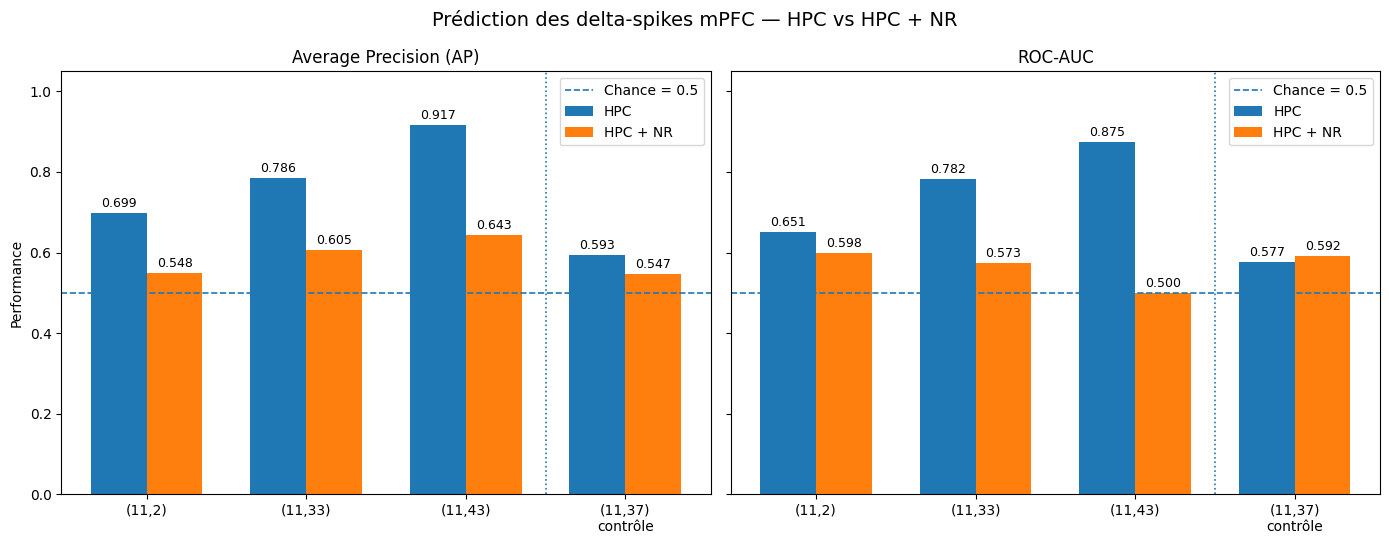

In [193]:
neurons = ["(11,2)", "(11,33)", "(11,43)", "(11,37)\ncontrôle"]

# AP
ap_hpc = np.array([0.699, 0.786, 0.917, 0.593])
ap_nr  = np.array([0.548, 0.605, 0.643, 0.547])

# ROC-AUC
auc_hpc = np.array([0.651, 0.782, 0.875, 0.577])
auc_nr  = np.array([0.598, 0.573, 0.500, 0.592])

x = np.arange(len(neurons))
width = 0.35


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5.5),
    sharey=True
)

ax = axes[0]

bars_hpc = ax.bar(
    x - width/2,
    ap_hpc,
    width,
    label="HPC"
)

bars_nr = ax.bar(
    x + width/2,
    ap_nr,
    width,
    label="HPC + NR"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    label="Chance = 0.5"
)

ax.axvline(2.5, linestyle=":", linewidth=1.2)

ax.set_title("Average Precision (AP)")
ax.set_ylabel("Performance")
ax.set_xticks(x)
ax.set_xticklabels(neurons)
ax.set_ylim(0, 1.05)

for bars in [bars_hpc, bars_nr]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.015,
            f"{h:.3f}",
            ha="center",
            fontsize=9
        )

ax.legend()

ax = axes[1]

bars_hpc = ax.bar(
    x - width/2,
    auc_hpc,
    width,
    label="HPC"
)

bars_nr = ax.bar(
    x + width/2,
    auc_nr,
    width,
    label="HPC + NR"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    label="Chance = 0.5"
)

ax.axvline(2.5, linestyle=":", linewidth=1.2)

ax.set_title("ROC-AUC")
ax.set_xticks(x)
ax.set_xticklabels(neurons)

for bars in [bars_hpc, bars_nr]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.015,
            f"{h:.3f}",
            ha="center",
            fontsize=9
        )

ax.legend()

fig.suptitle(
    "Prédiction des delta-spikes mPFC — HPC vs HPC + NR",
    fontsize=14
)

plt.tight_layout()
plt.show()

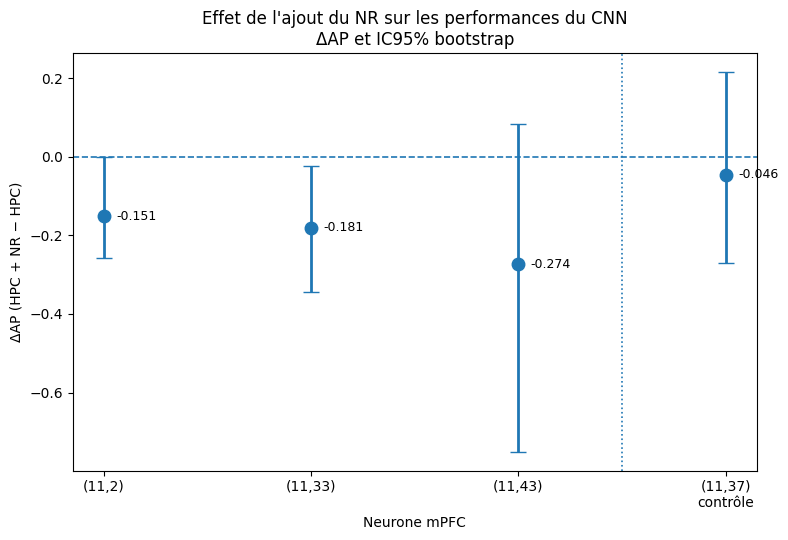

In [194]:

neurons = ["(11,2)", "(11,33)", "(11,43)", "(11,37)\ncontrôle"]

# ΔAP observés
delta_ap = np.array([
    -0.151,
    -0.181,
    -0.274,
    -0.046
])

# IC95% bootstrap obtenus précédemment
ci_low = np.array([
    -0.258,
    -0.343,
    -0.750,
    -0.271
])

ci_high = np.array([
    -0.000,
    -0.025,
     0.083,
     0.215
])

# Transformation en distances pour errorbar
yerr = np.vstack([
    delta_ap - ci_low,
    ci_high - delta_ap
])

x = np.arange(len(neurons))

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.errorbar(
    x,
    delta_ap,
    yerr=yerr,
    fmt="o",
    markersize=9,
    capsize=6,
    linewidth=2
)

# Aucune différence entre les modèles
ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2
)

# Séparation du neurone contrôle
ax.axvline(
    2.5,
    linestyle=":",
    linewidth=1.2
)

ax.set_xticks(x)
ax.set_xticklabels(neurons)

ax.set_ylabel("ΔAP (HPC + NR − HPC)")
ax.set_xlabel("Neurone mPFC")

ax.set_title(
    "Effet de l'ajout du NR sur les performances du CNN\n"
    "ΔAP et IC95% bootstrap"
)

# Valeur observée à côté de chaque point
for i, value in enumerate(delta_ap):
    ax.text(
        i + 0.06,
        value,
        f"{value:+.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

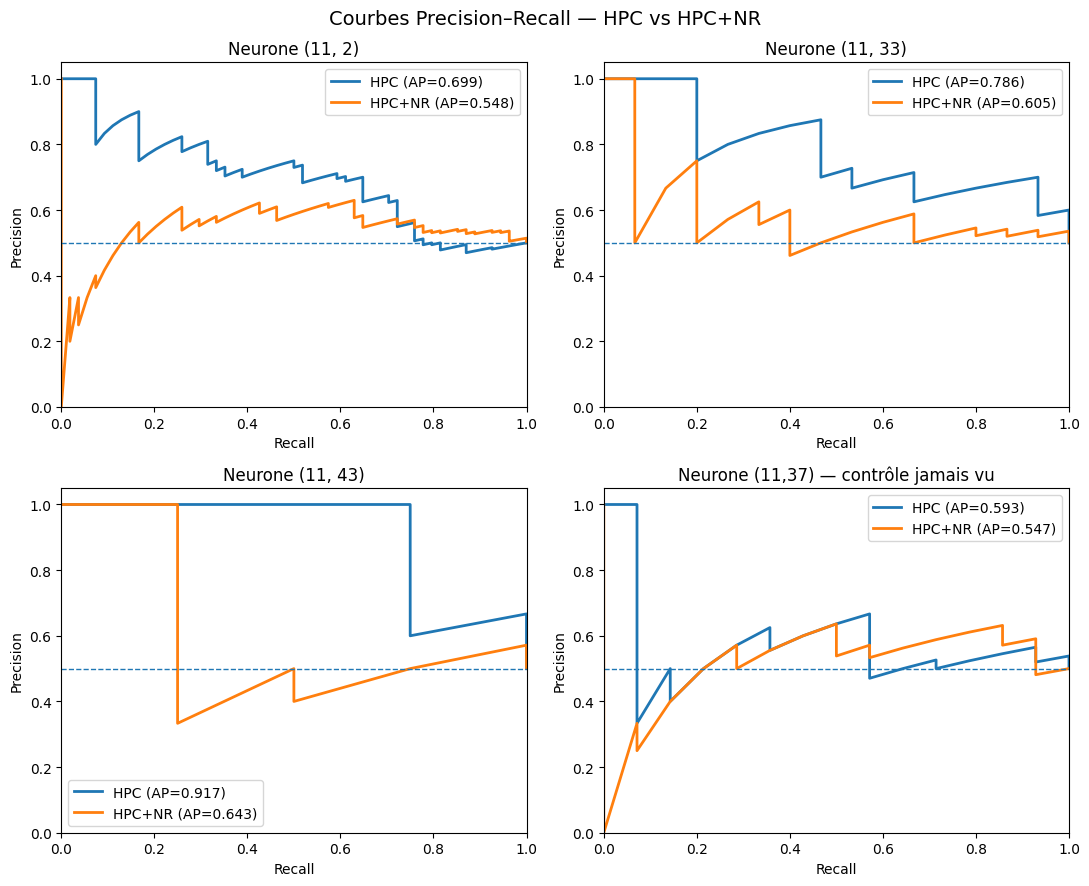

In [196]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 9)
)

axes = axes.ravel()

# ============================================================
# 3 neurones individuels
# ============================================================

for i, unit in enumerate(selected_units):

    ax = axes[i]

    y_true = hpc_results[unit]["y_test"]

    pred_hpc = hpc_results[unit]["y_pred"]
    pred_nr  = hpc_nr_opt_results[unit]["y_pred"]

    precision_hpc, recall_hpc, _ = precision_recall_curve(
        y_true, pred_hpc
    )

    precision_nr, recall_nr, _ = precision_recall_curve(
        y_true, pred_nr
    )

    ap_hpc = average_precision_score(y_true, pred_hpc)
    ap_nr  = average_precision_score(y_true, pred_nr)

    ax.plot(
        recall_hpc,
        precision_hpc,
        linewidth=2,
        label=f"HPC (AP={ap_hpc:.3f})"
    )

    ax.plot(
        recall_nr,
        precision_nr,
        linewidth=2,
        label=f"HPC+NR (AP={ap_nr:.3f})"
    )

    # Chance = proportion de positifs
    chance = y_true.mean()

    ax.axhline(
        chance,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(f"Neurone {unit}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend()


# ============================================================
# Neurone contrôle (11,37) — CNN commun
# ============================================================

ax = axes[3]

precision_hpc, recall_hpc, _ = precision_recall_curve(
    y_control,
    pred_common_hpc
)

precision_nr, recall_nr, _ = precision_recall_curve(
    y_control,
    pred_common_nr
)

ax.plot(
    recall_hpc,
    precision_hpc,
    linewidth=2,
    label=f"HPC (AP={ap_common_hpc:.3f})"
)

ax.plot(
    recall_nr,
    precision_nr,
    linewidth=2,
    label=f"HPC+NR (AP={ap_common_nr:.3f})"
)

ax.axhline(
    y_control.mean(),
    linestyle="--",
    linewidth=1
)

ax.set_title("Neurone (11,37) — contrôle jamais vu")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()

fig.suptitle(
    "Courbes Precision–Recall — HPC vs HPC+NR",
    fontsize=14
)

plt.tight_layout()
plt.show()

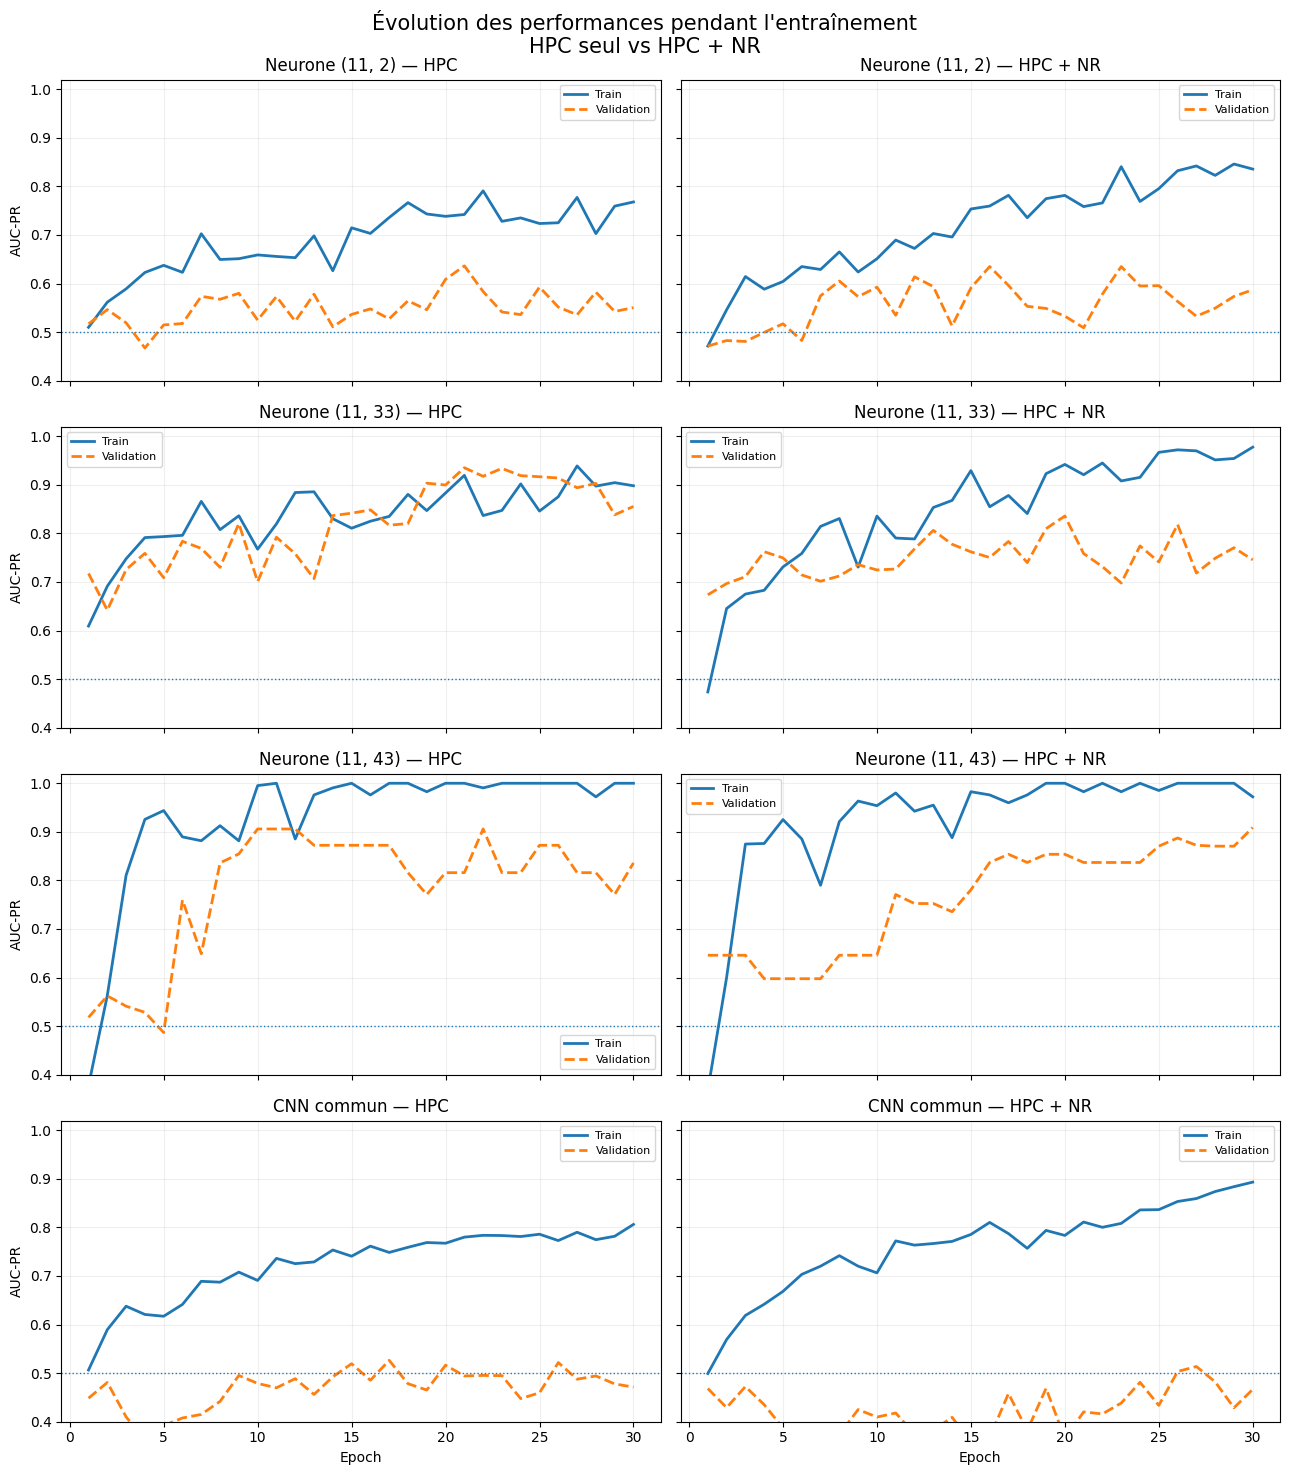

In [197]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(13, 15),
    sharex=True,
    sharey=True
)

# ------------------------------------------------------------
# 3 CNN individuels
# ------------------------------------------------------------

for row, unit in enumerate(selected_units):

    # HPC
    hist_hpc = hpc_histories[unit].history
    epochs_hpc = np.arange(1, len(hist_hpc["auc_pr"]) + 1)

    axes[row, 0].plot(
        epochs_hpc,
        hist_hpc["auc_pr"],
        linewidth=2,
        label="Train"
    )

    axes[row, 0].plot(
        epochs_hpc,
        hist_hpc["val_auc_pr"],
        linewidth=2,
        linestyle="--",
        label="Validation"
    )

    axes[row, 0].set_title(
        f"Neurone {unit} — HPC"
    )


    # HPC + NR
    hist_nr = hpc_nr_opt_histories[unit].history
    epochs_nr = np.arange(1, len(hist_nr["auc_pr"]) + 1)

    axes[row, 1].plot(
        epochs_nr,
        hist_nr["auc_pr"],
        linewidth=2,
        label="Train"
    )

    axes[row, 1].plot(
        epochs_nr,
        hist_nr["val_auc_pr"],
        linewidth=2,
        linestyle="--",
        label="Validation"
    )

    axes[row, 1].set_title(
        f"Neurone {unit} — HPC + NR"
    )


# ------------------------------------------------------------
# CNN COMMUN
# ------------------------------------------------------------

# HPC
hist = history_common_hpc.history
epochs = np.arange(1, len(hist["auc_pr"]) + 1)

axes[3, 0].plot(
    epochs,
    hist["auc_pr"],
    linewidth=2,
    label="Train"
)

axes[3, 0].plot(
    epochs,
    hist["val_auc_pr"],
    linewidth=2,
    linestyle="--",
    label="Validation"
)

axes[3, 0].set_title(
    "CNN commun — HPC"
)


# HPC + NR
hist = history_common_nr.history
epochs = np.arange(1, len(hist["auc_pr"]) + 1)

axes[3, 1].plot(
    epochs,
    hist["auc_pr"],
    linewidth=2,
    label="Train"
)

axes[3, 1].plot(
    epochs,
    hist["val_auc_pr"],
    linewidth=2,
    linestyle="--",
    label="Validation"
)

axes[3, 1].set_title(
    "CNN commun — HPC + NR"
)


# ------------------------------------------------------------
# Mise en forme commune
# ------------------------------------------------------------

for ax in axes.ravel():

    ax.axhline(
        0.5,
        linestyle=":",
        linewidth=1
    )

    ax.set_ylim(0.4, 1.02)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

for ax in axes[:, 0]:
    ax.set_ylabel("AUC-PR")

for ax in axes[-1, :]:
    ax.set_xlabel("Epoch")

fig.suptitle(
    "Évolution des performances pendant l'entraînement\n"
    "HPC seul vs HPC + NR",
    fontsize=15
)

plt.tight_layout()
plt.show()